# 🧬 Protein Variant Prioritization Pipeline (Level-B)
## E. coli DHFR Case Study

### Research Goal

**Prioritize single-site enzyme variants** that may improve active site properties (pocket shape, ligand interactions, stability) while maintaining structural confidence. This pipeline aims to identify plausible candidates for experimental testing and validation.

### Why DHFR?

**E. coli Dihydrofolate Reductase** (UniProt: `P0ABQ4`) is an ideal teaching target:
- **Small**: 159 amino acids → fast Colab runs
- **High confidence**: AlphaFold predicts it with avg pLDDT ≈ 96
- **Well-studied**: Rich structural data (folate/methotrexate complexes)
- **Clear active site**: Asp27 and surrounding pocket are well-characterized

### Workflow

The pipeline is structured as a multi-stage process, progressively filtering a large set of starting mutations into a prioritized list for experimental consideration.

**Stage 1 - Docking and residue scoring**
* The process starts with a wild-type (WT) protein structure. A known ligand (MTX) is docked into the structure leveraging tools like AutoDock Vina to identify the geometry and constituent residues of the active site.

**Stage 2 - Mutation variation generation**
* A panel of potential single-point mutations is generated in silico for the residues within the defined active site. The large set of variants is then scored using the ESM-1v model. Variants with scores predicting a high likelihood of being detrimental are filtered out, resulting a smaller more promising cohort.

**Stage 3 - Modeling**
* The 3D structures for the top-scoring variants are predicted using ColabFold (AlphaFold2). These predicted models are then analyzed for structural integrity via metrics such as pLDDT and for geometric changes within the active site compared to the WT.

**Stage 4 - Composite Scoring**
* All collected data points, the initial ESM-1v score, structural confidence metrics, and geometric analysis are integrated into a single, weighted composite score. The final score i used to rank the variants, producing a prioritized list of candidates with highest potential for improved function.


*Footnote* — ColabFold runs best on a GPU (e.g., T4/L4/A100). CPU is functional but much slower, and TPU support can be hit-or-miss. **In Colab, go to Runtime → Change runtime type → Hardware accelerator = GPU**

In [ ]:
#@title 01 - 🔗 Mount Drive
import os, shutil, importlib.util, time
from pathlib import Path
from datetime import datetime

# ==== Config ====
PROJECT_FOLDER = "AlphaFold2_Research"   # under MyDrive
RUN_FOLDER     = "run_LB"                # canonical name on Drive
MIGRATE_EXISTING_CONTENT = True          # move any /content/run_LB data into Drive first
VERBOSE = True

# ==== Detect Colab & mount ====
in_colab = importlib.util.find_spec("google.colab") is not None
if in_colab:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    print("ℹ️ Not in Colab; using local filesystem.")
    DRIVE_ROOT = Path.home() / "MyDrive"

# ==== Persistent paths on Drive ====
PROJ_ROOT  = DRIVE_ROOT / PROJECT_FOLDER
OUTDIR_PERSIST = PROJ_ROOT / RUN_FOLDER
OUTDIR_PERSIST.mkdir(parents=True, exist_ok=True)

# ==== ⏱️ Record Start Time (for duration calculation) ====
start_marker = OUTDIR_PERSIST / "pipeline_start.txt"
try:
    # Always overwrite to mark the beginning of *this* session/run
    with open(start_marker, "w") as f:
        f.write(str(time.time()))
    if VERBOSE:
        print(f"⏱️ Pipeline timer started: {datetime.fromtimestamp(time.time()).strftime('%Y-%m-%d %H:%M:%S')}")
except Exception as e:
    print(f"⚠️ Could not write start time: {e}")

# ==== Local alias paths we guarantee ====
aliases = [Path("/content/run_LB")] if Path("/content").exists() else [OUTDIR_PERSIST]

def _symlink_or_fix(link_path: Path, target: Path):
    """Create/repair a symlink at link_path -> target (directory)."""
    try:
        if link_path.exists() or link_path.is_symlink():
            # If it's already the correct symlink, leave it
            if link_path.is_symlink() and link_path.resolve() == target.resolve():
                if VERBOSE:
                    print(f"✓ {link_path} already links to {target}")
                return
            # If it's a real dir and we want to migrate, do that first
            if link_path.exists() and not link_path.is_symlink():
                if link_path.is_dir():
                    if MIGRATE_EXISTING_CONTENT and target.resolve() != link_path.resolve():
                        if VERBOSE: print(f"↪️  Migrating existing {link_path} → {target}")
                        for root, dirs, files in os.walk(link_path):
                            rel = Path(root).relative_to(link_path)
                            (target / rel).mkdir(parents=True, exist_ok=True)
                            for name in files:
                                s = Path(root) / name
                                d = (target / rel) / name
                                if s.is_file():
                                    try:
                                        shutil.copy2(s, d)
                                    except Exception as e:
                                        print(f"  ! Skip {s}: {e}")
                        # remove the old local dir so we can place a symlink
                        shutil.rmtree(link_path)
                    else:
                        print(f"⚠️ {link_path} exists and migration is disabled; leaving as-is.")
                        return
                else:
                    # Not a dir → remove it
                    link_path.unlink()
            else:
                # it's an incorrect symlink → remove and recreate
                link_path.unlink()
        # Make the new symlink
        link_path.symlink_to(target, target_is_directory=True)
        if VERBOSE:
            print(f"🔗 {link_path} -> {target}")
    except Exception as e:
        print(f"❌ Could not create symlink {link_path} → {target}: {e}")

# Ensure project folder exists
PROJ_ROOT.mkdir(parents=True, exist_ok=True)

# Create/repair both alias links
for alias in aliases:
    if alias.parent.exists():
        _symlink_or_fix(alias, OUTDIR_PERSIST)

# ==== Patch CFG and environment ====
try:
    CFG
except NameError:
    CFG = {}
CFG["OUTDIR"] = str(OUTDIR_PERSIST)
os.environ["OUTDIR"] = str(OUTDIR_PERSIST)

# ==== Quick visibility check ====
def _ls(p: Path, n=6):
    try:
        items = sorted(p.iterdir())
        names = [("📁 " if x.is_dir() else "📄 ") + x.name for x in items[:n]]
        more  = "" if len(items) <= n else f" … (+{len(items)-n} more)"
        return ", ".join(names) + more
    except Exception:
        return "(unreadable)"

print(f"\n📁 Persistent OUTDIR: {OUTDIR_PERSIST}")
print(f"   Contains: {_ls(OUTDIR_PERSIST)}")
for alias in aliases:
    if alias.exists() or alias.is_symlink():
        tgt = alias.resolve() if alias.is_symlink() else "(dir)"
        print(f"✓ Alias ready: {alias} -> {tgt}")
    else:
        print(f"✗ Alias missing: {alias} (check permissions and rerun)")

print("✅ Drive + links ready.")

Mounted at /content/drive
⏱️ Pipeline timer started: 2026-01-28 22:06:59
🔗 /content/run_LB -> /content/drive/MyDrive/AlphaFold2_Research/run_LB

📁 Persistent OUTDIR: /content/drive/MyDrive/AlphaFold2_Research/run_LB
   Contains: 📄 AF-P0ABQ4-F1-model_v6.pdb, 📁 AF-P0ABQ4-F1-model_v6_out, 📄 AMBER_READY, 📄 COLABFOLD_READY, 📄 CONDA_READY, 📄 PL.types … (+45 more)
✓ Alias ready: /content/run_LB -> /content/drive/MyDrive/AlphaFold2_Research/run_LB
✅ Drive + links ready.


In [ ]:
#@title 02 - ⚙️ Configuration
from sys import version_info
import os

python_version = f"{version_info.major}.{version_info.minor}"

CFG = dict(
    UNIPROT_ID="P0ABQ4",
    LIGAND_SOURCE=dict(kind="pubchem_cid", id="126941"),
    JOB_NAME="DHFR",
    OUTDIR="/content/run_LB",
    AFDB_VERSION="v6",
    MODEL_TYPE="alphafold2_ptm",
    NUM_SEEDS=5,
    NUM_RECYCLES=3,
    NUM_MODELS=1,
    NUM_RELAX=1,
    POCKET_CONF=70.0,
    BOX_PADDING=9.0,
    BOOTSTRAP_N=500
)

CFG.update({
    "WT_FASTA": os.path.join(CFG["OUTDIR"], "enzyme_wt.fasta"),
    "REFERENCE_STRUCTURE": os.path.join(CFG["OUTDIR"], f"AF-{CFG['UNIPROT_ID']}-F1-model_{CFG['AFDB_VERSION']}.pdb"),
    "LIGAND_SDF": os.path.join(CFG["OUTDIR"], "ligand.sdf"),
    "LIGAND_PDB": os.path.join(CFG["OUTDIR"], "ligand.pdb"),
    "RECEPTOR_PDBQT": os.path.join(CFG["OUTDIR"], "receptor.pdbqt"),
    "LIGAND_PDBQT": os.path.join(CFG["OUTDIR"], "ligand.pdbqt"),
    "DOCKED_SDF": os.path.join(CFG["OUTDIR"], "docked_top.sdf"),
    "POCKET_FILE": os.path.join(CFG["OUTDIR"], "pocket_residues.txt"),
    "VARIANTS_TSV": os.path.join(CFG["OUTDIR"], "variants_step4.tsv"),
    "COLABFOLD_FASTA": os.path.join(CFG["OUTDIR"], "variants_step5.fasta"),
    "MODELS_DIR": os.path.join(CFG["OUTDIR"], "models_step5"),
})

use_amber = CFG["NUM_RELAX"] > 0
use_templates = False

print("✅ Configuration loaded")

✅ Configuration loaded


 You can restore files from a previous session that were backed up in your Google Drive.

In [ ]:
#@title 03 - ♻️ Restore Session
# @markdown Select a session from **MyDrive/ColabFold Backups** and restore it into **/content/run_LB**.
import os, sys, json, time, shutil, zipfile, importlib.util
from pathlib import Path
from datetime import datetime

# --- Ensure ipywidgets is available (Colab usually has it) ---
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

# --- Resolve Drive root (mount if in Colab) ---
in_colab = importlib.util.find_spec("google.colab") is not None
if in_colab:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    DRIVE_ROOT = Path.home() / "MyDrive"

backup_root = DRIVE_ROOT / "ColabFold Backups"
backup_root.mkdir(parents=True, exist_ok=True)

# --- Discover available sessions (both folders and zips) ---
def list_sessions():
    items = []
    if backup_root.exists():
        for p in backup_root.iterdir():
            if p.is_dir() and p.name.startswith("session-"):
                items.append((p.name + " /folder", p))
            elif p.is_file() and p.suffix == ".zip" and p.stem.startswith("session-"):
                items.append((p.stem + " /zip", p))
    # Newest first by mtime
    items.sort(key=lambda kv: kv[1].stat().st_mtime, reverse=True)
    return items

sessions = list_sessions()
if not sessions:
    display(HTML("<b>No sessions found</b> in <code>MyDrive/ColabFold Backups</code>. "
                 "Run the backup cell first."))
else:
    # --- Widgets ---
    dd = widgets.Dropdown(
        options=[(label, path) for label, path in sessions],
        description="Session",
        layout=widgets.Layout(width="70%"),
    )
    clean_toggle = widgets.Checkbox(value=False, description="Clean /content/run_LB before restore")
    restore_btn = widgets.Button(description="Restore", button_style="primary")
    preview_btn = widgets.Button(description="Preview")
    out = widgets.Output(layout={"border": "1px solid #ddd", "padding": "8px"})

    # --- Helpers ---
    def target_dir() -> Path:
        """Return the path we restore *into* (handles symlink or real dir)."""
        t = Path("/content/run_LB")
        if not t.exists():
            t.mkdir(parents=True, exist_ok=True)
        return t  # if it's a symlink, copying into it writes to its target

    def count_in_folder(folder: Path) -> int:
        cnt = 0
        for _, _, files in os.walk(folder):
            cnt += len(files)
        return cnt

    def count_in_zip(zippath: Path) -> int:
        with zipfile.ZipFile(zippath) as zf:
            # count files (skip directory entries)
            return sum(1 for zi in zf.infolist() if not zi.is_dir())

    def preview_session(p: Path):
        with out:
            clear_output()
            if p.is_dir():
                n = count_in_folder(p)
                print(f"Session: {p.name} (folder) — files: {n}")
                # Show a few top-level entries
                tops = sorted(p.iterdir())
                print("Top-level contents:")
                for item in tops[:12]:
                    print("  📁" if item.is_dir() else "  📄", item.name)
                if len(tops) > 12:
                    print(f"  … (+{len(tops)-12} more)")
            else:
                n = count_in_zip(p)
                print(f"Session: {p.stem} (zip) — files: {n}")
                with zipfile.ZipFile(p) as zf:
                    names = [zi.filename for zi in zf.infolist() if not zi.is_dir()][:12]
                    print("Archive sample:")
                    for nm in names:
                        print("  📄", nm)
                    if n > 12:
                        print(f"  … (+{n-12} more)")

    def clean_target(tgt: Path):
        # Remove contents *inside* /content/run_LB but keep the folder/symlink itself
        for child in tgt.iterdir():
            try:
                if child.is_symlink() or child.is_file():
                    child.unlink()
                elif child.is_dir():
                    shutil.rmtree(child)
            except Exception as e:
                print(f"  ! Could not remove {child}: {e}")

    def copy_tree(src: Path, dst: Path, report_every=300):
        """Recursive copy: create dirs, copy files with metadata."""
        # os.walk traverses the directory tree recursively. :contentReference[oaicite:2]{index=2}
        # copy2 preserves basic metadata (mtime/atime). :contentReference[oaicite:3]{index=3}
        count = 0
        for root, dirs, files in os.walk(src):
            rel = Path(root).relative_to(src)
            target_dir = dst / rel
            target_dir.mkdir(parents=True, exist_ok=True)
            for name in files:
                s = Path(root) / name
                d = target_dir / name
                try:
                    shutil.copy2(s, d)
                    count += 1
                    if count % report_every == 0:
                        print(f"  • Copied {count} files…")
                except Exception as e:
                    print(f"  ! Skip: {s} ({e})")
        return count

    def restore_clicked(_):
        p = dd.value
        with out:
            clear_output()
            tgt = target_dir()
            print(f"Target: {tgt}  (exists: {tgt.exists()}, symlink: {tgt.is_symlink()})")
            if clean_toggle.value:
                print("🧹 Cleaning target…")
                clean_target(tgt)

            start = time.time()
            file_count = 0

            if p.is_dir():
                print(f"🔁 Restoring from folder: {p}")
                file_count = copy_tree(p, tgt)
            else:
                # Use zipfile to extract to a temp dir, then copy. :contentReference[oaicite:4]{index=4}
                tmp = Path("/content/_restore_tmp")
                if tmp.exists():
                    shutil.rmtree(tmp)
                tmp.mkdir(parents=True, exist_ok=True)
                print(f"📦 Extracting ZIP: {p.name}")
                with zipfile.ZipFile(p) as zf:
                    zf.extractall(tmp)
                # The zip root will be a folder named like the session; find the single top-level dir
                roots = [q for q in tmp.iterdir() if q.is_dir()]
                src_root = roots[0] if len(roots) == 1 else tmp
                print("🔁 Copying extracted files…")
                file_count = copy_tree(src_root, tgt)
                shutil.rmtree(tmp)

            elapsed = time.time() - start
            print(f"✅ Restore complete. Files restored: {file_count} in {elapsed:.1f}s")
            manifest = (backup_root / (p.stem if p.suffix == ".zip" else p.name) / "backup_manifest.json")
            if manifest.exists():
                try:
                    data = json.loads(manifest.read_text())
                    print("📝 Manifest:", json.dumps(data, indent=2)[:800], "…")
                except Exception:
                    pass

    def preview_clicked(_):
        preview_session(dd.value)

    # --- Wire up UI ---
    restore_btn.on_click(restore_clicked)
    preview_btn.on_click(preview_clicked)

    header = HTML("<b>Restore a backup session</b> from <code>MyDrive/ColabFold Backups</code>")
    controls = widgets.HBox([dd])
    actions = widgets.HBox([preview_btn, clean_toggle, restore_btn])

    display(header, controls, actions, out)

    # Auto-preview newest on load
    preview_session(dd.value)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Output(layout=Layout(border='1px solid #ddd', padding='8px'))

Dependency installation includes key packages for AF2, autodock, and additional tools that will support this pipeline. This single-cell installation step will take several minutes.

In [ ]:
#@title 04 - 🔧 Ensure Vina Available
# This cell ensures vina is installed in the Jupyter kernel's Python environment
# Background: Cell 3 installs vina via conda, but the Jupyter kernel may use a different Python

import sys
import subprocess

try:
    import vina
    print(f"✅ vina already available (version {vina.__version__})")
    print(f"   Location: {vina.__file__}")
except ImportError:
    print(f"📦 Installing vina into Jupyter kernel's Python ({sys.executable})...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "vina"])
    import vina
    print(f"✅ vina installed successfully (version {vina.__version__})")
    print(f"   Location: {vina.__file__}")


📦 Installing vina into Jupyter kernel's Python (/usr/bin/python3)...
✅ vina installed successfully (version 1.2.7)
   Location: /usr/local/lib/python3.12/dist-packages/vina/__init__.py


In [ ]:
#@title 05 - 📦 Install Dependencies (Official ColabFold + GPU Fix)
import os
import sys
from datetime import datetime

print("=" * 60)
print(f"🔍 Cell 05 Starting - {datetime.now().strftime('%H:%M:%S')}")
print("=" * 60)

# Clean old flags
os.system("rm -f /content/run_LB/*_READY 2>/dev/null")
print("✅ Cleaned old flags\n")

# Configuration
USE_AMBER = True
USE_TEMPLATES = False
PYTHON_VERSION = f"{sys.version_info.major}.{sys.version_info.minor}"

# ===== SECTION 1: ColabFold (Official Method) =====
print("=" * 60)
print("SECTION 1: ColabFold Core (Official)")
print("=" * 60)
if not os.path.isfile("/content/run_LB/COLABFOLD_READY"):
  print("📦 Installing ColabFold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")

  # TPU-specific JAX installation (official logic - only for TPU!)
  # For GPU: ColabFold's dependencies bring the correct JAX version automatically
  if os.environ.get('TPU_NAME', False):
    print("  → TPU detected - installing JAX 0.3.25")
    os.system("pip uninstall -q -y jax jaxlib")
    os.system("pip install -q --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  else:
    print("  → GPU/CPU detected - using ColabFold's default JAX")

  # TensorFlow (needed for ColabFold TPU detection, even on GPU)
  print("  → Installing TensorFlow")
  os.system("pip install -q --no-warn-conflicts tensorflow")

  # Symlinks (official method)
  os.system("ln -sf /usr/local/lib/python3.*/dist-packages/colabfold colabfold 2>/dev/null")
  os.system("ln -sf /usr/local/lib/python3.*/dist-packages/alphafold alphafold 2>/dev/null")
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so 2>/dev/null")

  os.system("touch /content/run_LB/COLABFOLD_READY")
  print("✅ ColabFold installed")
else:
  print("✅ ColabFold already installed\n")

# ===== SECTION 2: Conda (Official Method) =====
print("\n" + "=" * 60)
print("SECTION 2: Miniforge/Conda + Mamba (Official)")
print("=" * 60)
if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("/content/run_LB/CONDA_READY"):
    print("📦 Installing Miniforge...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local >/dev/null 2>&1")
    os.system("conda config --set auto_update_conda false")

    print("📦 Installing mamba...")
    os.system("conda install -y -q -c conda-forge mamba")

    os.system("touch /content/run_LB/CONDA_READY")
    print("✅ Conda + mamba installed")
  else:
    print("✅ Conda already installed")
else:
  print("⏭️  Skipping conda (not needed)")

# ===== SECTION 3: Amber (Official Method) =====
print("\n" + "=" * 60)
print("SECTION 3: Amber/OpenMM (Official)")
print("=" * 60)
if USE_AMBER and not os.path.isfile("/content/run_LB/AMBER_READY"):
  print("📦 Installing Amber/OpenMM...")
  os.system(f"mamba install -y -q -c conda-forge openmm=8.2.0 pdbfixer python='{PYTHON_VERSION}'")
  os.system("touch /content/run_LB/AMBER_READY")
  print("✅ Amber installed")
elif USE_AMBER:
  print("✅ Amber already installed")
else:
  print("⏭️  Skipping Amber")

# ===== SECTION 4: Templates (Official Method) =====
print("\n" + "=" * 60)
print("SECTION 4: Template Tools (Official)")
print("=" * 60)
if USE_TEMPLATES and not os.path.isfile("/content/run_LB/HH_READY"):
  print("📦 Installing HHsuite + Kalign2...")
  os.system(f"mamba install -y -q -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
  os.system("touch /content/run_LB/HH_READY")
  print("✅ Template tools installed")
elif USE_TEMPLATES:
  print("✅ Template tools already installed")
else:
  print("⏭️  Skipping template tools")

# ===== SECTION 5: Extra Tools (Custom - for variant analysis) =====
print("\n" + "=" * 60)
print("SECTION 5: Extra Tools (Custom)")
print("=" * 60)
if not os.path.isfile("/content/run_LB/TOOLS_READY"):
  print("📦 Installing conda tools (openbabel, fpocket)...")
  os.system(f"mamba install -y -q -c conda-forge -c bioconda openbabel fpocket python='{PYTHON_VERSION}'")

  print("📦 Installing pip packages (py3Dmol, rdkit, freesasa, openbabel-wheel)...")
  print("   → Installing in Jupyter kernel for accessibility")
  os.system("pip install -q --no-warn-conflicts py3Dmol rdkit freesasa openbabel-wheel")

  os.system("touch /content/run_LB/TOOLS_READY")
  print("✅ Tools installed")
else:
  print("✅ Tools already installed")

# ===== SECTION 6: appdirs =====
print("\n" + "=" * 60)
print("SECTION 6: appdirs")
print("=" * 60)
print("📦 Installing appdirs...")
os.system("pip install -q --no-warn-conflicts appdirs==1.4.4")
print("✅ appdirs ready")

# ===== SECTION 7: AlphaFold Parameters =====
print("\n" + "=" * 60)
print("SECTION 7: AlphaFold Parameters")
print("=" * 60)
print("📥 Downloading AlphaFold parameters...")
os.system("python -m colabfold.download 2>/dev/null || echo '⚠️  Download attempted'")

# ===== FINAL VERIFICATION =====
print("\n" + "=" * 60)
print(f"✅✅✅ INSTALLATION COMPLETE - {datetime.now().strftime('%H:%M:%S')}")
print("=" * 60)
print("\nVerifying installed packages:")

import importlib
modules = ["numpy", "jax", "tensorflow", "colabfold", "rdkit", "py3Dmol", "freesasa", "appdirs", "vina"]
for mod_name in modules:
  try:
    mod = importlib.import_module(mod_name)
    if hasattr(mod, '__version__'):
      version = mod.__version__
    elif hasattr(mod, 'version'):
      version = mod.version
    else:
      version = '✓ installed'
    print(f"  ✓ {mod_name:12s} {version}")
  except Exception as e:
    print(f"  ✗ {mod_name:12s} FAILED: {e}")

print("=" * 60)
print("🎉 Ready to proceed!")
print("=" * 60)


🔍 Cell 05 Starting - 22:07:04
✅ Cleaned old flags

SECTION 1: ColabFold Core (Official)
📦 Installing ColabFold...
  → GPU/CPU detected - using ColabFold's default JAX
  → Installing TensorFlow
✅ ColabFold installed

SECTION 2: Miniforge/Conda + Mamba (Official)
📦 Installing Miniforge...
📦 Installing mamba...
✅ Conda + mamba installed

SECTION 3: Amber/OpenMM (Official)
📦 Installing Amber/OpenMM...
✅ Amber installed

SECTION 4: Template Tools (Official)
⏭️  Skipping template tools

SECTION 5: Extra Tools (Custom)
📦 Installing conda tools (openbabel, fpocket)...
📦 Installing pip packages (py3Dmol, rdkit, freesasa, openbabel-wheel)...
   → Installing in Jupyter kernel for accessibility
✅ Tools installed

SECTION 6: appdirs
📦 Installing appdirs...
✅ appdirs ready

SECTION 7: AlphaFold Parameters
📥 Downloading AlphaFold parameters...

✅✅✅ INSTALLATION COMPLETE - 22:14:28

Verifying installed packages:
  ✓ numpy        2.0.2
  ✓ jax          0.7.2
  ✓ tensorflow   2.20.0
  ✓ colabfold    ✓ i

In [ ]:
#@title Quick Fix - Install rdkit and freesasa
import subprocess
import sys

print("Installing rdkit and freesasa (showing any errors)...")
print("=" * 60)

result = subprocess.run([
    sys.executable, "-m", "pip", "install", "rdkit", "freesasa"
], capture_output=False)

print(f"\nReturn code: {result.returncode}")

if result.returncode == 0:
    print("\n✅ Installation successful")
else:
    print("\n❌ Installation had errors (see above)")

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

import importlib
for pkg in ["rdkit", "freesasa"]:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'OK')
        print(f"✅ {pkg:12s} {ver}")
    except Exception as e:
        print(f"❌ {pkg:12s} {e}")

print("=" * 60)


Installing rdkit and freesasa (showing any errors)...

Return code: 0

✅ Installation successful

VERIFICATION
✅ rdkit        2025.09.3
✅ freesasa     OK


Auto-fetch process for the WT sequence & AFDB model. DHFR WT FASTA and an AFDB apo model gives us a standard reference:

*   FASTA by UniProt ID: https://rest.uniprot.org/uniprotkb/<ID>.fasta
*   AFDB file naming convention: AF-<UniProt>-F1-model_v6.{pdb|cif}

*Footnote:* AFDB versions will progress over time (currently v6), which changes the naming convention (you can tweak this in the configuration cell).




In [ ]:
#@title 06 - ⬇️ Fetch WT Data (UniProt + AlphaFold)
import os
import requests

print("=" * 60)
print("Fetching Wild-Type Data")
print("=" * 60)

# Ensure output directory exists
os.makedirs(CFG["OUTDIR"], exist_ok=True)

# 1. Fetch FASTA from UniProt
print(f"\n📄 Fetching FASTA for {CFG['UNIPROT_ID']}...")
fasta_url = f"https://rest.uniprot.org/uniprotkb/{CFG['UNIPROT_ID']}.fasta"
wt_fasta = os.path.join(CFG["OUTDIR"], "enzyme_wt.fasta")

try:
    r = requests.get(fasta_url, timeout=60)
    r.raise_for_status()
    with open(wt_fasta, "wb") as f:
        f.write(r.content)

    # Parse sequence info
    with open(wt_fasta) as f:
        lines = f.readlines()
        header = lines[0].strip()
        sequence = "".join(ln.strip() for ln in lines[1:])

    print(f"   ✅ FASTA saved: {wt_fasta}")
    print(f"   → Length: {len(sequence)} amino acids")
    print(f"   → Preview: {sequence[:60]}...")

except Exception as e:
    raise RuntimeError(f"Failed to fetch FASTA: {e}")

# 2. Fetch AlphaFold DB model (v6 - latest version)
print(f"\n🧬 Fetching AlphaFold DB model {CFG['AFDB_VERSION']}...")
af_version = CFG['AFDB_VERSION']
af_pdb_url = f"https://alphafold.ebi.ac.uk/files/AF-{CFG['UNIPROT_ID']}-F1-model_{af_version}.pdb"
af_pdb = os.path.join(CFG["OUTDIR"], f"AF-{CFG['UNIPROT_ID']}-F1-model_{af_version}.pdb")

try:
    r = requests.get(af_pdb_url, timeout=60)
    r.raise_for_status()
    with open(af_pdb, "wb") as f:
        f.write(r.content)

    # Parse model info
    n_atoms = 0
    plddt_values = []
    with open(af_pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                n_atoms += 1
                try:
                    plddt = float(line[60:66].strip())
                    plddt_values.append(plddt)
                except:
                    pass

    avg_plddt = sum(plddt_values) / len(plddt_values) if plddt_values else 0

    print(f"   ✅ AlphaFold model saved: {af_pdb}")
    print(f"   → Version: {af_version}")
    print(f"   → Atoms: {n_atoms}")
    print(f"   → Average pLDDT: {avg_plddt:.1f}")
    print(f"   → File size: {os.path.getsize(af_pdb):,} bytes")

except Exception as e:
    raise RuntimeError(f"Failed to fetch AlphaFold model: {e}")

# Store in config
CFG["REFERENCE_STRUCTURE"] = af_pdb
CFG["WT_FASTA"] = wt_fasta
CFG["WT_SEQUENCE"] = sequence

print("\n" + "=" * 60)
print("✅ Wild-type data ready!")
print(f"   → FASTA: {wt_fasta}")
print(f"   → Structure: {af_pdb}")
print("=" * 60)

Fetching Wild-Type Data

📄 Fetching FASTA for P0ABQ4...
   ✅ FASTA saved: /content/run_LB/enzyme_wt.fasta
   → Length: 159 amino acids
   → Preview: MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNI...

🧬 Fetching AlphaFold DB model v6...
   ✅ AlphaFold model saved: /content/run_LB/AF-P0ABQ4-F1-model_v6.pdb
   → Version: v6
   → Atoms: 1268
   → Average pLDDT: 96.6
   → File size: 107,729 bytes

✅ Wild-type data ready!
   → FASTA: /content/run_LB/enzyme_wt.fasta
   → Structure: /content/run_LB/AF-P0ABQ4-F1-model_v6.pdb


#Visualization of AFDB Model
Regions are color-coded based on confidence (pLDDT): blue = high, green = good, yellow/red = uncertain. Focus on the pocket region.

For our workflow, we aim for confident pocket residues before trusting pocket geometry.

It’s normal for termini and long loops to be lower confidence; that doesn’t doom the pocket.

In [ ]:
#@title 07 - 📊 Preview WT Structure
import os

# Ensure py3Dmol is available
try:
    import py3Dmol
except ImportError:
    print("Installing py3Dmol...")
    !pip install -q py3Dmol
    import py3Dmol

# Get the correct path from CFG
af_pdb = CFG["REFERENCE_STRUCTURE"]

# Visualize
v = py3Dmol.view(width=700, height=520)
with open(af_pdb, 'r') as f:
    v.addModel(f.read(), 'pdb')

# Color cartoon by B-factor (AlphaFold pLDDT stored in B-factor column)
v.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient':'roygb','min':50,'max':90}}})

# Show any hetero atoms (ligands, ions) as sticks
v.addStyle({'hetflag': True}, {'stick': {'radius': 0.15}})

v.zoomTo()
v.show()

# === SAVE PROTEIN STRUCTURE IMAGE ===
# Add this to the END of Cell 07
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

print("\n📸 Saving protein structure visualization...")

try:
    pdb_file = Path(CFG["REFERENCE_STRUCTURE"])
    if pdb_file.exists():
        # Parse PDB for CA atoms and pLDDT
        coords, bfactors = [], []
        with open(pdb_file, 'r') as f:
            for line in f:
                if line.startswith('ATOM') and ' CA ' in line:
                    coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
                    bfactors.append(float(line[60:66]))

        coords = np.array(coords)
        bfactors = np.array(bfactors)

        # Create figure
        fig = plt.figure(figsize=(12, 5))

        # 3D structure
        ax1 = fig.add_subplot(121, projection='3d')
        scatter = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                            c=bfactors, cmap='RdYlGn', s=20, alpha=0.8)
        ax1.plot(coords[:, 0], coords[:, 1], coords[:, 2], 'gray', alpha=0.3, linewidth=0.5)
        ax1.set_title(f'Wild-Type Structure\n{CFG["UNIPROT_ID"]}', fontweight='bold')
        plt.colorbar(scatter, ax=ax1, shrink=0.5, label='pLDDT')

        # pLDDT histogram
        ax2 = fig.add_subplot(122)
        ax2.hist(bfactors, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax2.axvline(bfactors.mean(), color='red', linestyle='--', label=f'Mean: {bfactors.mean():.1f}')
        ax2.set_xlabel('pLDDT Score')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Confidence Distribution', fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        output_path = Path(CFG["OUTDIR"]) / "protein_structure.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  ✓ Saved: {output_path}")
except Exception as e:
    print(f"  ⚠️ Error: {e}")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


📸 Saving protein structure visualization...
  ✓ Saved: /content/run_LB/protein_structure.png


Fetch a reference ligand (MTX) with PubChem with PUG-REST. PUG-REST lets us download an SDF by CID (MTX = 126941). We chose a canonical ligand for demonstration, saving time on the docking process (Vina to auto-dock and  determine best pose, fpocket to measure the distances from a centroid to the protein residues, filters and returns top protein residues ranked by proximity).

In [ ]:
#@title 08 - 💊 Fetch Reference Ligand
import os
import subprocess
from pathlib import Path

import requests

OUTDIR = Path(CFG["OUTDIR"])
OUTDIR.mkdir(parents=True, exist_ok=True)

cid = str(CFG["LIGAND_SOURCE"]["id"]).strip()
lig_sdf = OUTDIR / "ligand.sdf"
lig_pdb = OUTDIR / "ligand.pdb"


def _require_obabel():
    from shutil import which
    ob = which("obabel")
    if not ob:
        raise RuntimeError("Open Babel (obabel) not found in PATH")
    return ob


def _fetch_bytes(url: str, timeout: int = 60):
    resp = requests.get(url, timeout=timeout, headers={"User-Agent": "ProteinVariantTriage/1.0"})
    resp.raise_for_status()
    return resp.content, resp.headers.get("content-type", "")


def _looks_like_sdf(payload: bytes) -> bool:
    text = payload.decode("utf-8", errors="ignore")
    if not text.strip():
        return False
    if "V3000" in text[:5000]:
        return "M  V30 BEGIN ATOM" in text and "M  V30 END ATOM" in text
    lines = text.splitlines()
    if len(lines) < 4:
        return False
    if "M  END" not in text and "$$$$" not in text:
        return False
    counts = lines[3]
    try:
        int(counts[:3])
        int(counts[3:6])
        return True
    except Exception:
        return False


def _write_valid_sdf(payload: bytes, path: Path) -> bool:
    path.write_bytes(payload)
    if not path.exists() or path.stat().st_size < 100:
        return False
    return _looks_like_sdf(payload)


def _run(cmd, cwd=None):
    p = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if p.returncode != 0:
        tail = "\n".join((p.stderr or "").splitlines()[-20:])
        raise RuntimeError(f"Command failed ({p.returncode}): {' '.join(cmd)}\n{tail}")
    return p


_require_obabel()

# 1) Try direct SDF download (3D then 2D)
urls = [
    f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/CID/{cid}/SDF?record_type=3d",
    f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/CID/{cid}/SDF",
]

download_ok = False
last_err = None
for url in urls:
    try:
        payload, ctype = _fetch_bytes(url)
        if _write_valid_sdf(payload, lig_sdf):
            print(f"✓ Downloaded valid SDF from: {url}")
            download_ok = True
            break
        last_err = f"Invalid SDF payload from {url} (content-type={ctype})"
    except Exception as e:
        last_err = f"{url} -> {e}"

# 2) Fallback: fetch SMILES and build SDF via obabel
if not download_ok:
    smiles_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/CID/{cid}/property/CanonicalSMILES/TXT"
    try:
        smi_bytes, _ = _fetch_bytes(smiles_url)
        smiles = smi_bytes.decode("utf-8", errors="ignore").strip().splitlines()[0].strip()
        if not smiles:
            raise RuntimeError("Empty CanonicalSMILES response")
        _run(["obabel", f"-:{smiles}", "-osdf", "-O", str(lig_sdf), "--gen3d"], cwd=str(OUTDIR))
        if not lig_sdf.exists() or lig_sdf.stat().st_size < 100:
            raise RuntimeError("obabel generated empty SDF from SMILES")
        print("✓ Built ligand.sdf from PubChem CanonicalSMILES fallback")
        download_ok = True
    except Exception as e:
        raise RuntimeError(f"Failed to build ligand reference for CID {cid}. Last download error: {last_err}; SMILES fallback error: {e}")

# 3) Convert SDF -> PDB and validate
_run(["obabel", str(lig_sdf), "-O", str(lig_pdb)])
if not lig_pdb.exists() or lig_pdb.stat().st_size < 100:
    raise RuntimeError(f"ligand.pdb was not created correctly: {lig_pdb}")

print("Saved:", lig_sdf, lig_pdb)



Saved: /content/run_LB/ligand.sdf /content/run_LB/ligand.pdb


In [ ]:
#@title 09 - 🛠️ Pre-flight Checks (Merged)
print("Pre-flight PDBQT checks are now merged into Cell 10 (Define Docking Box).")
print("Run Cell 10 to execute OpenBabel preflight + fpocket box generation together.")



✓ receptor_pdbqt: /content/run_LB/receptor.pdbqt 199506 bytes
✓ ligand_pdbqt  : /content/run_LB/ligand.pdbqt 4139 bytes


#Docking Stage

The docking stage is comprised of three key steps: pre-docking setup, the docking simulation itself, and post-docking analysis and refinement.

### Pre-docking Setup (Define Search Box)
This step prepares the protein and ligand for docking. The binding pocket is identified either automatically using tools like `fpocket` or by using a predefined list of residues. A search box, defining the area where the ligand can bind, is then computed around the pocket's center with some padding. The protein and ligand are converted to the PDBQT format using `OpenBabel`, which includes adding appropriate hydrogens and partial charges, and the protein is treated as a rigid structure. This step ensures that the docking software has the necessary inputs in the correct format and defines the search space efficiently.

*   **Tools:** `fpocket` for pocket detection, `OpenBabel` for format conversion and preparation.

### Docking (Pose Generation with Vina)
In this central step, the docking simulation is performed using `AutoDock Vina`. Vina explores different orientations and positions (poses) of the ligand within the defined search box and scores them based on their predicted binding affinity. Multiple poses are generated and kept to capture different binding modes.

*   **Tools:** `AutoDock Vina` for docking simulation.

### Post-docking (ML Rescoring + Clustering)
After Vina generates initial poses, this step refines the results. The poses are rescored using a machine learning model (`GNINA`) to get more accurate predictions of pose quality and affinity. The poses are then clustered based on their structural similarity (RMSD) to identify distinct binding modes and remove redundant, highly similar poses. Representative poses from each cluster, typically the one with the best ML score, are selected for downstream analysis. The top-scoring pose is saved separately for subsequent steps like pocket analysis.

*   **Tools:** `GNINA` for ML rescoring, `RDKit` for clustering and pose handling.

###Pre-docking (define the search box)

* Detect or confirm the binding pocket (fpocket or curated residues).
* Compute grid center/size with safety padding; write box_params.json.
* Prepare receptor/ligand PDBQT (protonation, Gasteiger charges, rigid receptor).



In [ ]:
#@title 10 - 🧭 Define Docking Box (fpocket + preflight)
import os, json, glob, shutil, subprocess, tempfile, numpy as np, pandas as pd

OUTDIR = CFG["OUTDIR"]
AF_FALLBACK = os.path.join(OUTDIR, f"AF-{CFG['UNIPROT_ID']}-F1-model_v6.pdb")
AF_PDB = CFG.get("REFERENCE_STRUCTURE", os.path.join(OUTDIR, "reference_protein.pdb"))
if (not os.path.exists(AF_PDB)) and os.path.exists(AF_FALLBACK):
    AF_PDB = AF_FALLBACK

POCKET_CSV = os.path.join(OUTDIR, "top_pocket.csv")
BOX_JSON = os.path.join(OUTDIR, "box_params.json")
RECEPTOR_PDBQT = os.path.join(OUTDIR, "receptor.pdbqt")
LIGAND_PDB = os.path.join(OUTDIR, "ligand.pdb")
LIGAND_SDF = os.path.join(OUTDIR, "ligand.sdf")
LIGAND_PDBQT = os.path.join(OUTDIR, "ligand.pdbqt")

MARGIN_ANG = float(CFG.get("BOX_MARGIN_ANG", 6.0))
MIN_BOX_AXIS = 18.0


def _which(cmd):
    from shutil import which
    return which(cmd) is not None


def _run_checked(cmd, cwd=None):
    run = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if run.returncode != 0:
        tail = "\n".join((run.stderr or "").splitlines()[-25:])
        raise RuntimeError(f"Command failed ({run.returncode}): {' '.join(cmd)}\n{tail}")


def _detect_obabel_version():
    try:
        p = subprocess.run(["obabel", "-V"], check=False, capture_output=True, text=True)
        txt = (p.stdout or "") + (p.stderr or "")
        import re
        m = re.search(r"Open Babel\s+(\d+\.\d+\.\d+)", txt)
        return m.group(1) if m else None
    except Exception:
        return None


def _set_babel_env():
    ver = _detect_obabel_version() or "3.1.1"
    candidates = [
        (f"/usr/local/lib/openbabel/{ver}", f"/usr/local/share/openbabel/{ver}"),
        (f"/usr/lib/openbabel/{ver}", f"/usr/share/openbabel/{ver}"),
        (f"/opt/conda/lib/openbabel/{ver}", f"/opt/conda/share/openbabel/{ver}"),
    ]
    for lib, dat in candidates:
        if os.path.isdir(lib):
            os.environ["BABEL_LIBDIR"] = lib
        if os.path.isdir(dat):
            os.environ["BABEL_DATADIR"] = dat
    p = subprocess.run(["obabel", "-L", "formats"], capture_output=True, text=True)
    txt = (p.stdout or "") + (p.stderr or "")
    if "LoadAllPlugins" in txt:
        print("⚠️ Open Babel plugin warning persists:", os.environ.get("BABEL_LIBDIR"), os.environ.get("BABEL_DATADIR"))
    else:
        print("✓ Open Babel plugins available.")


def preflight_prepare_pdbqt(receptor_pdb):
    if not os.path.exists(receptor_pdb):
        raise FileNotFoundError(f"Receptor PDB not found: {receptor_pdb}")
    if not _which("obabel"):
        print("⚠️ OpenBabel (obabel) not found; skipping PDBQT preparation in this cell.")
        return False

    _set_babel_env()

    _run_checked([
        "obabel", receptor_pdb, "-O", RECEPTOR_PDBQT,
        "-xr", "-p", "7.4", "-xh", "--partialcharge", "gasteiger"
    ], cwd=OUTDIR)

    txt = open(RECEPTOR_PDBQT).read(2500)
    if ("ROOT" in txt) or ("BRANCH" in txt):
        raise RuntimeError("Receptor PDBQT contains ROOT/BRANCH (not rigid). Check OpenBabel version/flags.")

    if (not os.path.exists(LIGAND_PDB)) or os.path.getsize(LIGAND_PDB) == 0:
        if os.path.exists(LIGAND_SDF) and os.path.getsize(LIGAND_SDF) > 0:
            _run_checked(["obabel", LIGAND_SDF, "-O", LIGAND_PDB], cwd=OUTDIR)
        else:
            raise FileNotFoundError(f"Ligand source missing: {LIGAND_PDB} and {LIGAND_SDF}")

    _run_checked([
        "obabel", LIGAND_PDB, "-O", LIGAND_PDBQT,
        "-p", "7.4", "--partialcharge", "gasteiger"
    ], cwd=OUTDIR)

    print("✓ receptor_pdbqt:", RECEPTOR_PDBQT, os.path.getsize(RECEPTOR_PDBQT), "bytes")
    print("✓ ligand_pdbqt  :", LIGAND_PDBQT, os.path.getsize(LIGAND_PDBQT), "bytes")
    return True


def _is_hydrogen(ln):
    elem = (ln[76:78].strip() if len(ln) >= 78 else "")
    if elem:
        return elem.upper() == "H"
    return ln[12:16].strip().upper().startswith("H")


def _write_fpocket_input(src_pdb, dst_pdb):
    kept = 0
    has_model = False
    in_first_model = False
    with open(src_pdb) as fi, open(dst_pdb, "w") as fo:
        for raw in fi:
            ln = raw.rstrip("\n")
            rec = ln[:6].strip().upper()
            if rec == "MODEL":
                has_model = True
                if in_first_model:
                    break
                in_first_model = True
                continue
            if rec == "ENDMDL":
                if in_first_model:
                    break
                continue
            if has_model and not in_first_model:
                continue
            if rec != "ATOM":
                continue
            if len(ln) < 54:
                continue
            altloc = ln[16].strip() if len(ln) > 16 else ""
            if altloc and altloc not in {"A", "1"}:
                continue
            if _is_hydrogen(ln):
                continue
            chars = list(ln.ljust(80))
            chars[16] = " "
            if not chars[21].strip():
                chars[21] = "A"
            fo.write("".join(chars).rstrip() + "\n")
            kept += 1
        fo.write("END\n")
    if kept == 0:
        raise RuntimeError(f"No protein atoms kept for fpocket input: {src_pdb}")


def maybe_run_fpocket(pdb_path):
    if os.path.exists(POCKET_CSV):
        return
    if not _which("fpocket"):
        print("⚠️ fpocket not found; using fallback box selection")
        return

    # Run in a no-space temp directory to avoid fpocket path/basename crashes on Windows-mounted paths.
    tmp = tempfile.mkdtemp(prefix="fpocket_run_", dir="/tmp")
    try:
        fp_in = os.path.join(tmp, "fp_in.pdb")
        fp_out = os.path.join(tmp, "fp_in_out")
        _write_fpocket_input(pdb_path, fp_in)

        print(">>> Running fpocket (pre-docking)...")
        run = subprocess.run(["fpocket", "-f", "fp_in.pdb"], cwd=tmp, capture_output=True, text=True)
        if run.returncode != 0:
            tail = "\n".join((run.stderr or "").splitlines()[-25:])
            raise RuntimeError(f"fpocket returned {run.returncode}. stderr tail:\n{tail}")

        pocket_files = sorted(glob.glob(os.path.join(fp_out, "pockets", "pocket*_atm.pdb")))
        if not pocket_files:
            return

        pocket_file = max(pocket_files, key=lambda p: os.path.getsize(p))
        xs, ys, zs = [], [], []
        with open(pocket_file) as fh:
            for ln in fh:
                if ln.startswith(("ATOM", "HETATM")):
                    xs.append(float(ln[30:38]))
                    ys.append(float(ln[38:46]))
                    zs.append(float(ln[46:54]))
        if xs:
            pd.DataFrame({"x": xs, "y": ys, "z": zs}).to_csv(POCKET_CSV, index=False)
            print("✓ Wrote pocket atoms:", POCKET_CSV)
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


def centroid_from_pdb_atoms(pdb_path, resid_set=None, chains=None):
    xs, ys, zs = [], [], []
    with open(pdb_path) as fh:
        for ln in fh:
            if not ln.startswith(("ATOM", "HETATM")):
                continue
            if chains:
                ch = (ln[21].strip() or "_")
                if ch not in chains:
                    continue
            resi = int(ln[22:26])
            if (resid_set is not None) and (resi not in resid_set):
                continue
            xs.append(float(ln[30:38]))
            ys.append(float(ln[38:46]))
            zs.append(float(ln[46:54]))
    if not xs:
        raise RuntimeError("No atoms found for centroid selection.")
    return np.array([np.mean(xs), np.mean(ys), np.mean(zs)])


def box_from_points(df_xyz, pad=6.0):
    mins = df_xyz[["x", "y", "z"]].min().values
    maxs = df_xyz[["x", "y", "z"]].max().values
    size = (maxs - mins) + 2 * pad
    center = (maxs + mins) / 2.0
    size = np.maximum(size, np.array([MIN_BOX_AXIS] * 3))
    return center.tolist(), size.tolist()


try:
    preflight_prepare_pdbqt(AF_PDB)
except Exception as e:
    print("Preflight PDBQT step failed (non-fatal):", e)

try:
    if os.path.exists(AF_PDB):
        maybe_run_fpocket(AF_PDB)
except Exception as e:
    print("fpocket pre-step failed (non-fatal):", e)

if os.path.exists(POCKET_CSV) and os.path.getsize(POCKET_CSV) > 0:
    dfp = pd.read_csv(POCKET_CSV)
    center, size, src = *box_from_points(dfp, pad=MARGIN_ANG), "fpocket"
else:
    pocket_txt = os.path.join(OUTDIR, "pocket_residues.txt")
    if os.path.exists(pocket_txt):
        resi = [int(x.strip()) for x in open(pocket_txt) if x.strip().lstrip("-").isdigit()]
        center = centroid_from_pdb_atoms(AF_PDB, resid_set=set(resi)).tolist()
        size = [22.5, 22.5, 22.5]
        src = "pocket_residues.txt"
    else:
        center = centroid_from_pdb_atoms(AF_PDB).tolist()
        size = [30.0, 30.0, 30.0]
        src = "whole_protein_centroid"

with open(BOX_JSON, "w") as fh:
    json.dump({
        "center": center,
        "size": size,
        "source": src,
        "margin": MARGIN_ANG,
        "min_axis": MIN_BOX_AXIS,
    }, fh, indent=2)

print(f"Grid source: {src} | center={tuple(round(x,2) for x in center)} | size={tuple(round(x,1) for x in size)} A")
print("-> Saved:", BOX_JSON)



Grid source: fpocket | center=(3.69, -3.84, 2.11) | size=(37.8, 37.3, 30.7) Å
→ Saved: /content/run_LB/box_params.json


###Docking (pose generation with Vina)

* Build Vina maps on the pre-computed box.
* Run search with set exhaustiveness/seed; keep multiple poses.
* Convert results to SDF for downstream analysis; log per-pose energies.

In [ ]:
#@title 11 - 🚢 Dock Ligand (AutoDock Vina)
import csv
import json
import math
import os
import subprocess
import sys
import tempfile
import textwrap
import time
from pathlib import Path


OUTDIR = Path(CFG.get("OUTDIR", "/content/run_LB"))
OUTDIR.mkdir(parents=True, exist_ok=True)

RECEPTOR_PDBQT = Path(CFG.get("RECEPTOR_PDBQT", OUTDIR / "receptor.pdbqt"))
LIGAND_PDBQT = Path(CFG.get("LIGAND_PDBQT", OUTDIR / "ligand.pdbqt"))
LIGAND_SDF = OUTDIR / "ligand.sdf"
LIGAND_MOL2 = OUTDIR / "ligand.mol2"

# Prefer the box created by Cell 10.
BOX_JSON = Path(CFG.get("BOX_JSON", OUTDIR / "box_params.json"))
if not BOX_JSON.exists():
    alt = OUTDIR / "grid_box.json"
    if alt.exists():
        BOX_JSON = alt
assert BOX_JSON.exists(), f"Missing docking box JSON: {BOX_JSON}"

OUT_PDBQT = OUTDIR / "docked_vina_poses.pdbqt"
OUT_SDF = OUTDIR / "docked_vina_poses.sdf"
OUT_CSV = OUTDIR / "docked_vina_energies.csv"


def _which(cmd):
    from shutil import which
    return which(cmd)


def _run_checked(cmd, env=None):
    p = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if p.returncode != 0:
        tail = "\n".join((p.stderr or "").splitlines()[-25:])
        raise RuntimeError(f"Command failed ({p.returncode}): {' '.join(cmd)}\n{tail}")
    return p


def _as_float3(v, name):
    if not isinstance(v, (list, tuple)) or len(v) != 3:
        raise ValueError(f"{name} must be a length-3 list")
    out = []
    for x in v:
        y = float(x)
        if not math.isfinite(y):
            raise ValueError(f"{name} has non-finite value: {x}")
        out.append(y)
    return out


def _clamp_box(size_xyz):
    # Keep map sizes in a practical range to avoid pathological memory/time blowups.
    lo, hi = 16.0, 42.0
    return [max(lo, min(hi, float(v))) for v in size_xyz]


def _ensure_ligand_pdbqt():
    if LIGAND_PDBQT.exists() and LIGAND_PDBQT.stat().st_size > 0:
        return
    obabel = _which("obabel")
    if not obabel:
        raise RuntimeError("Missing ligand.pdbqt and obabel not found to build it")

    if LIGAND_SDF.exists() and LIGAND_SDF.stat().st_size > 0:
        _run_checked([obabel, "-isdf", str(LIGAND_SDF), "-opdbqt", "-O", str(LIGAND_PDBQT), "-h"])
    elif LIGAND_MOL2.exists() and LIGAND_MOL2.stat().st_size > 0:
        _run_checked([obabel, "-imol2", str(LIGAND_MOL2), "-opdbqt", "-O", str(LIGAND_PDBQT), "-h"])
    else:
        raise RuntimeError(f"No ligand source available to build PDBQT: {LIGAND_SDF} / {LIGAND_MOL2}")

    if not LIGAND_PDBQT.exists() or LIGAND_PDBQT.stat().st_size == 0:
        raise RuntimeError(f"Failed to create ligand PDBQT: {LIGAND_PDBQT}")


def _vina_runner_script() -> str:
    return textwrap.dedent(
        """
        import csv
        import json
        from vina import Vina
        import sys

        cfg = json.loads(open(sys.argv[1]).read())

        v = Vina(sf_name=cfg["sf_name"], seed=cfg["seed"], cpu=cfg["cpu"], verbosity=1)
        v.set_receptor(cfg["receptor_pdbqt"])
        v.set_ligand_from_file(cfg["ligand_pdbqt"])
        v.compute_vina_maps(center=cfg["center"], box_size=cfg["size"])
        v.dock(exhaustiveness=cfg["exhaustiveness"], n_poses=cfg["n_poses"])
        v.write_poses(cfg["out_pdbqt"], n_poses=cfg["n_poses"], overwrite=True)

        cols = ["E_total", "E_inter", "E_intra", "E_tors", "E_intra_best"]
        try:
            rows = v.energies(n_poses=cfg["n_poses"], energy_range=cfg["energy_range"])
        except Exception:
            e0 = v.score()
            rows = [[e0[0], e0[1], e0[2], e0[3], float("nan")]]

        with open(cfg["out_csv"], "w", newline="") as fh:
            w = csv.writer(fh)
            w.writerow(cols)
            for r in rows:
                rr = list(r)[:5]
                while len(rr) < 5:
                    rr.append(float("nan"))
                w.writerow(rr)
        """
    )


def _run_vina_isolated(config, timeout_sec):
    with tempfile.TemporaryDirectory(prefix="vina_run_", dir="/tmp") as td:
        td = Path(td)
        cfg_path = td / "cfg.json"
        run_path = td / "run_vina.py"
        cfg_path.write_text(json.dumps(config, indent=2))
        run_path.write_text(_vina_runner_script())

        proc = subprocess.run(
            [sys.executable, str(run_path), str(cfg_path)],
            capture_output=True,
            text=True,
            timeout=timeout_sec,
        )
        return proc


def _write_energy_csv(v, out_csv, n_poses, energy_range):
    cols = ["E_total", "E_inter", "E_intra", "E_tors", "E_intra_best"]
    try:
        rows = v.energies(n_poses=n_poses, energy_range=energy_range)
    except Exception:
        e0 = v.score()
        rows = [[e0[0], e0[1], e0[2], e0[3], float("nan")]]

    with open(out_csv, "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(cols)
        for r in rows:
            rr = list(r)[:5]
            while len(rr) < 5:
                rr.append(float("nan"))
            w.writerow(rr)


def _run_vina_direct(config):
    from vina import Vina

    v = Vina(sf_name=config["sf_name"], seed=config["seed"], cpu=config["cpu"], verbosity=1)
    v.set_receptor(config["receptor_pdbqt"])
    v.set_ligand_from_file(config["ligand_pdbqt"])
    v.compute_vina_maps(center=config["center"], box_size=config["size"])
    v.dock(exhaustiveness=config["exhaustiveness"], n_poses=config["n_poses"])
    v.write_poses(config["out_pdbqt"], n_poses=config["n_poses"], overwrite=True)
    _write_energy_csv(v, config["out_csv"], config["n_poses"], config["energy_range"])


# Preconditions
aassert_msg = f"Missing receptor PDBQT: {RECEPTOR_PDBQT}"
assert RECEPTOR_PDBQT.exists() and RECEPTOR_PDBQT.stat().st_size > 0, aassert_msg
_ensure_ligand_pdbqt()

# Prevent stale outputs from being mistaken as fresh docking results.
for stale in (OUT_PDBQT, OUT_CSV, OUT_SDF):
    try:
        if stale.exists():
            stale.unlink()
    except Exception:
        pass

def _load_box(path: Path):
    box = json.loads(path.read_text())
    if "center" in box and "size" in box:
        center_xyz = _as_float3(box.get("center"), "box.center")
        size_xyz = _clamp_box(_as_float3(box.get("size"), "box.size"))
        return center_xyz, size_xyz

    # Backward compatibility with legacy grid_box.json schema.
    center_xyz = _as_float3([box.get("center_x"), box.get("center_y"), box.get("center_z")], "box.center_xyz")
    size_xyz = _clamp_box(_as_float3([box.get("size_x"), box.get("size_y"), box.get("size_z")], "box.size_xyz"))
    return center_xyz, size_xyz


center, size = _load_box(BOX_JSON)

cpu_default = max(1, min(2, (os.cpu_count() or 2) // 2))
CPU = int(CFG.get("VINA_CPU", cpu_default))
EXHAUSTIVENESS = int(CFG.get("VINA_EXHAUSTIVENESS", 12))
N_POSES = int(CFG.get("VINA_N_POSES", 8))
ENERGY_RANGE = float(CFG.get("VINA_ENERGY_RANGE", 3.0))
SEED = int(CFG.get("VINA_SEED", 1))
SF_NAME = str(CFG.get("VINA_SF", "vina"))
TIMEOUT_SEC = int(CFG.get("VINA_TIMEOUT_SEC", 1800))

print(
    f"Grid center={tuple(round(x,2) for x in center)} | size={tuple(round(x,1) for x in size)} A "
    f"| cpu={CPU} | exhaustiveness={EXHAUSTIVENESS} | n_poses={N_POSES}"
)

cfg = {
    "sf_name": SF_NAME,
    "seed": SEED,
    "cpu": int(max(1, CPU)),
    "exhaustiveness": int(max(1, EXHAUSTIVENESS)),
    "n_poses": int(max(1, N_POSES)),
    "energy_range": float(ENERGY_RANGE),
    "receptor_pdbqt": str(RECEPTOR_PDBQT),
    "ligand_pdbqt": str(LIGAND_PDBQT),
    "center": [float(x) for x in center],
    "size": [float(x) for x in size],
    "out_pdbqt": str(OUT_PDBQT),
    "out_csv": str(OUT_CSV),
}

RUN_ISOLATED = bool(CFG.get("VINA_RUN_ISOLATED", False))
print("Runner mode:", "isolated-subprocess" if RUN_ISOLATED else "in-process")

start = time.time()
print(f">>> Vina single attempt: cpu={cfg['cpu']} ex={cfg['exhaustiveness']} poses={cfg['n_poses']}")
if RUN_ISOLATED:
    try:
        proc = _run_vina_isolated(cfg, timeout_sec=TIMEOUT_SEC)
    except subprocess.TimeoutExpired:
        raise RuntimeError(f"Vina timed out after {TIMEOUT_SEC}s")

    if not (proc.returncode == 0 and OUT_PDBQT.exists() and OUT_PDBQT.stat().st_size > 0):
        tail = "\n".join(((proc.stdout or "") + "\n" + (proc.stderr or "")).splitlines()[-60:])
        if proc.returncode < 0:
            sig = -proc.returncode
            tail = f"Process terminated by signal {sig}\n" + tail
            if sig == 9:
                tail += "\nHint: signal 9 can occur from memory pressure during subprocess launch; set CFG['VINA_RUN_ISOLATED']=False to run in-process."
        raise RuntimeError(f"Vina failed rc={proc.returncode}\n{tail}")
else:
    try:
        _run_vina_direct(cfg)
    except Exception as e:
        raise RuntimeError(f"Vina direct run failed: {e}") from e

if not OUT_PDBQT.exists() or OUT_PDBQT.stat().st_size == 0:
    raise RuntimeError(f"Vina reported success but output is missing: {OUT_PDBQT}")

print("✓ Vina docking succeeded")

obabel = _which("obabel")
if not obabel:
    raise RuntimeError("obabel is required to convert docked PDBQT to SDF")

_run_checked([obabel, "-ipdbqt", str(OUT_PDBQT), "-osdf", "-O", str(OUT_SDF), "-h"])

if not OUT_SDF.exists() or OUT_SDF.stat().st_size == 0:
    raise RuntimeError(f"Failed to produce SDF: {OUT_SDF}")

print(f"✓ Wrote Vina poses: {OUT_PDBQT}")
print(f"✓ Wrote SDF: {OUT_SDF}")
print(f"✓ Energies CSV: {OUT_CSV}")
print(f"⏱️ Elapsed: {time.time()-start:.1f}s")



✓ Open Babel plugins available.
>>> Checking Vina + OpenBabel…
✓ Python Vina + OpenBabel
Grid center=(0.0, 0.0, 0.0) | size=(22.0, 22.0, 22.0) Å | exhaustiveness=40
✓ Wrote Vina poses: /content/run_LB/docked_vina_poses.pdbqt
>>> Converting all Vina poses to SDF…
✓ Wrote: /content/run_LB/docked_vina_poses.sdf
✓ Energies CSV: /content/run_LB/docked_vina_energies.csv
⏱️ Elapsed: 105.5s


###Post-docking (ML rescoring + clustering)

* Rescore protein–ligand poses with GNINA CNNs (pose likelihood/affinity).
* Cluster poses by RMSD; select cluster medoids to avoid duplicates.
* Write a rescored multi-SDF and a single top pose for follow-up steps.

In [ ]:
#@title 12 - 🧼 Rescore Poses (GNINA + Clustering)
import os, sys, json, re, math, shutil, stat, subprocess
from pathlib import Path
from urllib.request import Request, urlopen, urlretrieve

# =========
# Config
# =========
CFG = globals().get("CFG", {})
OUTDIR = Path(CFG.get("OUTDIR", "/content/run_LB")); OUTDIR.mkdir(parents=True, exist_ok=True)
RECEPTOR_PDBQT = Path(CFG.get("RECEPTOR_PDBQT", OUTDIR/"receptor.pdbqt"))
VINA_SDF       = Path(CFG.get("VINA_SDF",       OUTDIR/"docked_vina_poses.sdf"))
VINA_CSV       = Path(CFG.get("VINA_CSV",       OUTDIR/"docked_vina_energies.csv"))

RMSD_CUTOFF      = float(CFG.get("RMSD_CUTOFF", 2.0))
TAKE_PER_CLUSTER = int(CFG.get("CLUSTER_TAKE_PER_CLUSTER", 1))

RESCORED_TSV = OUTDIR / "gnina_rescored.tsv"
RESCORED_SDF = OUTDIR / "docked_gnina_rescored.sdf"
TOP_SDF      = OUTDIR / "docked_top.sdf"
REP_CSV      = OUTDIR / "cluster_representatives_gnina.csv"
DOCK_JSON    = OUTDIR / "docking_summary.json"

# =========
# Helpers
# =========
def _run(cmd, check=True, env=None):
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env)
    print(">>>", " ".join(map(str, cmd))); print(p.stdout)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode})")
    return p


def _have_gpu():
    try:
        r = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True)
        return r.returncode == 0 and "GPU" in (r.stdout or "")
    except Exception:
        return False


def _list_release_assets(tag="v1.3.2"):
    url = f"https://api.github.com/repos/gnina/gnina/releases/tags/{tag}"
    req = Request(url, headers={"Accept": "application/vnd.github+json", "User-Agent": "curl/8"})
    with urlopen(req, timeout=30) as r:
        data = json.load(r)
    return [(a["name"], a["browser_download_url"], int(a.get("size", 0))) for a in data.get("assets", [])]


def _select_asset(assets, want_gpu, force_cpu=False):
    names = [(n.lower(), n, u, s) for n, u, s in assets]
    if force_cpu:
        for nl, n, u, s in names:
            if "cpu" in nl and n.startswith("gnina"):
                return n, u, s
    if want_gpu and not force_cpu:
        for nl, n, u, s in names:
            if "cuda" in nl and n.startswith("gnina"):
                return n, u, s
    for nl, n, u, s in names:
        if n.startswith("gnina") and "cuda" not in nl:
            return n, u, s
    for n, u, s in assets:
        if n.startswith("gnina"):
            return n, u, s
    return (None, None, 0)


def _guess_cudnn_dirs():
    dirs = []
    # Active env + common conda roots.
    for root in [os.environ.get("CONDA_PREFIX"), sys.prefix, str(Path.home()/"miniconda"), str(Path.home()/"miniconda3")]:
        if not root:
            continue
        p = Path(root)
        if (p/"lib").is_dir():
            dirs.append(str(p/"lib"))
        sp = p/"lib"/f"python{sys.version_info.major}.{sys.version_info.minor}"/"site-packages"/"nvidia"/"cudnn"/"lib"
        if sp.is_dir():
            dirs.append(str(sp))

    # Include nearby env libs (fast shallow glob).
    for base in [Path.home()/"miniconda"/"envs", Path.home()/"miniconda3"/"envs"]:
        if base.is_dir():
            for envlib in base.glob("*/lib"):
                if envlib.is_dir():
                    dirs.append(str(envlib))

    # Keep existing LD entries first, then add discovered unique dirs.
    existing = [d for d in os.environ.get("LD_LIBRARY_PATH", "").split(":") if d]
    out = []
    for d in existing + dirs:
        if d and d not in out:
            out.append(d)
    return out


def _gnina_env():
    env = os.environ.copy()
    ld = _guess_cudnn_dirs()
    if ld:
        env["LD_LIBRARY_PATH"] = ":".join(ld)
    return env


def _download_gnina(force_cpu=False):
    assets = _list_release_assets("v1.3.2")
    name, url, expected_size = _select_asset(assets, _have_gpu(), force_cpu=force_cpu)
    if not url:
        raise RuntimeError("Could not find a suitable GNINA asset.")
    target_dir = Path.home() / "bin"
    target_dir.mkdir(parents=True, exist_ok=True)
    target = target_dir / "gnina"
    print(f">> Downloading {name} -> {target}")
    urlretrieve(url, target)
    got = target.stat().st_size
    if expected_size and got != expected_size:
        raise RuntimeError(f"Downloaded GNINA size mismatch: got {got}, expected {expected_size}")
    os.chmod(target, os.stat(target).st_mode | stat.S_IEXEC)
    return str(target)


def _probe_gnina(bin_path, env):
    try:
        p = subprocess.run([bin_path, "--version"], capture_output=True, text=True, env=env)
    except Exception as e:
        return False, f"launch_failed: {e}", ""
    txt = (p.stdout or "") + (p.stderr or "")
    if p.returncode == 0:
        return True, (p.stdout or "").strip(), txt
    if "libcudnn.so.9" in txt:
        return False, "missing_libcudnn9", txt
    return False, f"returncode_{p.returncode}", txt


def _candidate_gnina_bins():
    cands = []
    for c in [
        CFG.get("GNINA_BIN"),
        str(Path.cwd()/"gnina.1.3.2"),
        str(Path.cwd()/"gnina"),
        str((OUTDIR.parent/"gnina.1.3.2")),
        str((OUTDIR.parent/"gnina")),
        shutil.which("gnina"),
        os.environ.get("GNINA_BIN"),
        str(Path.home()/"bin"/"gnina"),
    ]:
        if c and c not in cands and Path(c).exists():
            cands.append(c)
    return cands


def _build_vina_fallback_scores(vina_csv, n_poses_hint):
    import pandas as pd, numpy as np
    if vina_csv.exists() and vina_csv.stat().st_size > 0:
        df = pd.read_csv(vina_csv).reset_index().rename(columns={"index": "pose_idx"})
        if "E_total" in df.columns:
            df["CNNaffinity"] = -df["E_total"].astype(float)
            df["CNNscore"] = (-df["E_total"].astype(float)).rank(method="average", pct=True)
        else:
            df["CNNaffinity"] = np.nan
            df["CNNscore"] = np.nan
        return df
    return pd.DataFrame({
        "pose_idx": list(range(int(n_poses_hint))),
        "CNNaffinity": [np.nan] * int(n_poses_hint),
        "CNNscore": [np.nan] * int(n_poses_hint),
    })


# =========
# 1) Locate GNINA + robust fallback
# =========
GNINA_ENV = _gnina_env()
print("LD_LIBRARY_PATH for GNINA includes", len(GNINA_ENV.get("LD_LIBRARY_PATH", "").split(":")), "entries")

gnina_bin = None
gnina_ok = False
gnina_status = "not_checked"
gnina_detail = ""

for cand in _candidate_gnina_bins():
    ok, status, detail = _probe_gnina(cand, GNINA_ENV)
    if ok:
        gnina_bin, gnina_ok, gnina_status, gnina_detail = cand, True, status, detail
        break
    # Keep last failure in case all candidates fail.
    gnina_bin, gnina_ok, gnina_status, gnina_detail = cand, False, status, detail

if not gnina_ok:
    print(">> GNINA not usable from current candidates; fetching v1.3.2 release...")
    try:
        gnina_bin = _download_gnina(force_cpu=False)
        gnina_ok, gnina_status, gnina_detail = _probe_gnina(gnina_bin, GNINA_ENV)
    except Exception as e:
        gnina_status = f"download_failed: {e}"

if (not gnina_ok) and (gnina_status == "missing_libcudnn9"):
    print("⚠️ GNINA CUDA build requires libcudnn.so.9; trying CPU build...")
    try:
        gnina_bin = _download_gnina(force_cpu=True)
        gnina_ok, gnina_status, gnina_detail = _probe_gnina(gnina_bin, GNINA_ENV)
    except Exception as e:
        gnina_status = f"cpu_download_failed: {e}"

if gnina_ok:
    print("✓ GNINA:", gnina_status)
    print("✓ Using:", gnina_bin)
else:
    print("⚠️ GNINA unavailable:", gnina_status)
    if gnina_detail:
        print("GNINA detail tail\n" + "\n".join(str(gnina_detail).splitlines()[-20:]))
    print("⚠️ Falling back to Vina-only ranking for this step.")


# =========
# 2) Preconditions
# =========
assert RECEPTOR_PDBQT.exists() and RECEPTOR_PDBQT.stat().st_size > 0, f"Missing receptor PDBQT: {RECEPTOR_PDBQT}"
assert VINA_SDF.exists() and VINA_SDF.stat().st_size > 0, f"Missing Vina SDF poses: {VINA_SDF}"


# =========
# 3) Build score table (GNINA or fallback)
# =========
import pandas as pd, numpy as np

if gnina_ok:
    out = _run([gnina_bin, "-r", str(RECEPTOR_PDBQT), "-l", str(VINA_SDF), "--score_only"], env=GNINA_ENV).stdout

    rows, idx = [], 0
    for line in out.splitlines():
        if "CNN" not in line:
            continue
        m_score = re.search(r"CNNscore[:\s]+([\-]?\d+\.?\d*)", line, re.I)
        m_aff   = re.search(r"CNNaffinity[:\s]+([\-]?\d+\.?\d*)", line, re.I)
        if m_score or m_aff:
            rows.append({"pose_idx": idx,
                         "CNNscore": float(m_score.group(1)) if m_score else np.nan,
                         "CNNaffinity": float(m_aff.group(1)) if m_aff else np.nan,
                         "raw": line.strip()})
            idx += 1

    if not rows:
        floats = []
        for line in out.splitlines():
            if "CNN" in line:
                floats += re.findall(r"[-]?\d+\.\d+", line)
        rows = [{"pose_idx": i, "CNNscore": float(s), "CNNaffinity": float(a), "raw": "fallback_parser"}
                for i, (s, a) in enumerate(zip(floats[::2], floats[1::2]))]

    df_scores = pd.DataFrame(rows).reset_index(drop=True)
    if df_scores.empty:
        from rdkit import Chem
        nposes = sum(1 for m in Chem.SDMolSupplier(str(VINA_SDF), removeHs=False, sanitize=False) if m is not None)
        df_scores = _build_vina_fallback_scores(VINA_CSV, nposes)
        gnina_ok = False
        gnina_status = "gnina_parse_failed_fallback_vina"
else:
    from rdkit import Chem
    nposes = sum(1 for m in Chem.SDMolSupplier(str(VINA_SDF), removeHs=False, sanitize=False) if m is not None)
    df_scores = _build_vina_fallback_scores(VINA_CSV, nposes)

if VINA_CSV.exists() and VINA_CSV.stat().st_size > 0:
    try:
        df_vina = pd.read_csv(VINA_CSV).reset_index().rename(columns={"index": "pose_idx"})
        keep_cols = ["pose_idx"] + [c for c in ["E_total", "E_inter", "E_intra", "E_tors", "E_intra_best"] if c in df_vina.columns]
        df_scores = df_scores.merge(df_vina[keep_cols], on="pose_idx", how="left")
    except Exception as e:
        print("(!) Skipping Vina energies merge:", e)

df_scores.to_csv(RESCORED_TSV, index=False)


# =========
# 4) Attach scores + RMSD clustering (RDKit)
# =========
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from rdkit.ML.Cluster import Butina
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.warning")
except ImportError:
    _run([sys.executable, "-m", "pip", "install", "-q", "rdkit"])
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from rdkit.ML.Cluster import Butina
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.warning")


def _mol_list_from_sdf(sdf_path):
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=False)
    mols = [m for m in suppl if m is not None]
    if not mols:
        raise ValueError(f"No molecules parsed from {sdf_path}")
    out = []
    for m in mols:
        try:
            m = Chem.AddHs(m, addCoords=True)
            Chem.SanitizeMol(m, Chem.SanitizeFlags.SANITIZE_KEKULIZE | Chem.SanitizeFlags.SANITIZE_SETAROMATICITY)
        except Exception:
            pass
        out.append(m)
    return out


def _best_rmsd(a, b):
    try:
        return AllChem.GetBestRMS(a, b)
    except Exception:
        if a.GetNumAtoms() == b.GetNumAtoms():
            ca, cb = a.GetConformer(), b.GetConformer()
            s = 0.0
            for i in range(a.GetNumAtoms()):
                pa, pb = ca.GetAtomPosition(i), cb.GetAtomPosition(i)
                s += (pa.x - pb.x) ** 2 + (pa.y - pb.y) ** 2 + (pa.z - pb.z) ** 2
            return (s / a.GetNumAtoms()) ** 0.5
        return 1e6


def _cluster(mols, cutoff):
    dists = []
    n = len(mols)
    for i in range(1, n):
        for j in range(i):
            dists.append(_best_rmsd(mols[i], mols[j]))
    clus = Butina.ClusterData(dists, nPts=n, distThresh=cutoff, isDistData=True)
    return sorted(clus, key=len, reverse=True)


def _mol_to_sdf_text(mol):
    block = Chem.MolToMolBlock(mol, kekulize=False)
    parts = [block]
    for prop in mol.GetPropNames():
        parts.append(f">  <{prop}>\n{mol.GetProp(prop)}\n\n")
    parts.append("$$$$\n")
    return "".join(parts)


def _write_sdf(mols, path):
    with open(path, "w") as fh:
        for i, m in enumerate(mols):
            try:
                fh.write(_mol_to_sdf_text(m))
            except Exception as e:
                raise RuntimeError(f"Failed to serialize pose {i} to SDF: {e}") from e


def _pK_to_Kd_nM(pK):
    try:
        return 10 ** (-float(pK)) * 1e9
    except Exception:
        return float("nan")


mols = _mol_list_from_sdf(VINA_SDF)
for i, m in enumerate(mols):
    m.SetProp("pose_idx", str(i))
    if i < len(df_scores):
        r = df_scores.iloc[i]
        if not pd.isna(r.get("CNNscore", np.nan)):
            m.SetProp("CNNscore", f"{float(r['CNNscore']):.6f}")
        if not pd.isna(r.get("CNNaffinity", np.nan)):
            m.SetProp("CNNaffinity", f"{float(r['CNNaffinity']):.6f}")
            m.SetProp("Kd_nM", f"{_pK_to_Kd_nM(r['CNNaffinity']):.1f}")
        for col in ["E_total", "E_inter", "E_intra", "E_tors", "E_intra_best"]:
            if col in df_scores.columns and not pd.isna(r.get(col, np.nan)):
                m.SetProp(col, f"{float(r[col]):.6f}")

_write_sdf(mols, RESCORED_SDF)

clusters = _cluster(mols, RMSD_CUTOFF)
rows = []
for cid, cl in enumerate(clusters):
    for idx in cl:
        def _getf(mm, key):
            try:
                return float(mm.GetProp(key))
            except Exception:
                return float("nan")
        rows.append({
            "cluster_id": cid,
            "pose_idx": idx,
            "CNNaffinity": _getf(mols[idx], "CNNaffinity"),
            "CNNscore": _getf(mols[idx], "CNNscore")
        })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No clusters/poses available after rescoring")

df["sort_key"] = list(zip(-df["CNNaffinity"].fillna(-9e9), -df["CNNscore"].fillna(-9e9)))
df = df.sort_values(["cluster_id", "sort_key"]).reset_index(drop=True)

rep_indices = []
for cid, sub in df.groupby("cluster_id", sort=True):
    rep_indices += sub.head(TAKE_PER_CLUSTER)["pose_idx"].tolist()

rep_df = df[df["pose_idx"].isin(rep_indices)].sort_values(["cluster_id"]).reset_index(drop=True)
rep_df.to_csv(REP_CSV, index=False)

best_row = rep_df.sort_values(["CNNaffinity", "CNNscore"], ascending=False).iloc[0]
primary_idx = int(best_row["pose_idx"])

_write_sdf([mols[primary_idx]], TOP_SDF)

summary = {
    "primary_pose_idx": primary_idx,
    "scoring_backend": "gnina" if gnina_ok else "vina_fallback",
    "gnina_status": gnina_status,
    "gnina_bin": str(gnina_bin) if gnina_bin else None,
    "primary_scores": {
        "CNNaffinity_pK": float(mols[primary_idx].GetProp("CNNaffinity")) if mols[primary_idx].HasProp("CNNaffinity") else None,
        "CNNscore": float(mols[primary_idx].GetProp("CNNscore")) if mols[primary_idx].HasProp("CNNscore") else None,
        "Kd_nM": float(mols[primary_idx].GetProp("Kd_nM")) if mols[primary_idx].HasProp("Kd_nM") else None,
    },
    "clusters": rep_df.to_dict(orient="records"),
    "files": {
        "rescored_table": str(RESCORED_TSV),
        "rescored_sdf": str(RESCORED_SDF),
        "representatives_csv": str(REP_CSV),
        "fpocket_ligand_sdf": str(TOP_SDF),
    }
}
DOCK_JSON.write_text(json.dumps(summary, indent=2))

print("\n== Summary ==")
print(f"Scoring backend: {'GNINA' if gnina_ok else 'Vina fallback'}")
print(f"Poses rescored:   {len(mols)}")
print(f"Clusters found:   {len(clusters)} @ {RMSD_CUTOFF:.1f} A")
print(f"Reps per cluster: {TAKE_PER_CLUSTER}")
print("Primary (for fpocket): pose_idx =", primary_idx)
print(f"Outputs:\n  - {RESCORED_TSV.name}\n  - {RESCORED_SDF.name}\n  - {REP_CSV.name}\n  - {TOP_SDF.name}\n  - {DOCK_JSON.name}")






>> GNINA not found. Fetching v1.3.2 release…
>> Downloading gnina.1.3.2.cuda12.8 → /usr/local/bin/gnina
✓ GNINA: gnina v1.3.2 master:f23dd2b   Built Jul 29 2025.
>>> /usr/local/bin/gnina -r /content/run_LB/receptor.pdbqt -l /content/run_LB/docked_vina_poses.sdf --score_only
              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.3.2 master:f23dd2b   Built Jul 29 2025.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Commandline: /usr/local/bin/gnina -r /content/run_LB/receptor.pdbqt -l /content/run_LB/docked_vina_poses.sdf --score_only
## Name gauss(o=0,_w=0.5,_c=8) gauss(o=3,_w=2,_c=8) repulsion(o=0,_c=8) hydrophobic(g=0.5,_b=1.5,_c=8) non_dir_h_bond(g=-0.7,_b=0,_c=8) num_tors_div
Affinity: -10.62948 (kcal/mol)
CNNscore: 0.70669 
CNNaffinity: 6.92430
CNNvariance: 0.46152
Intramole

In [ ]:
#@title 13 - 🔍 Identify Pocket Residues
import os, re, glob, shutil, tempfile, subprocess
from pathlib import Path
import numpy as np

CFG = CFG
OUTDIR = Path(CFG["OUTDIR"])
af_pdb = Path(CFG.get("REFERENCE_STRUCTURE", OUTDIR / "reference_protein.pdb"))
af_fallback = OUTDIR / f"AF-{CFG['UNIPROT_ID']}-F1-model_v6.pdb"
if (not af_pdb.exists()) and af_fallback.exists():
    af_pdb = af_fallback

docked_sdf = OUTDIR / "docked_top.sdf"

final_pocket_legacy = OUTDIR / "pocket_residues.txt"
final_pocket_chain = OUTDIR / "pocket_residues.chain.txt"

assert docked_sdf.exists() and docked_sdf.stat().st_size > 0, "Missing docked_top.sdf — re-run docking."
assert af_pdb.exists(), f"Reference structure not found: {af_pdb}"

try:
    from rdkit import Chem
except Exception as e:
    raise RuntimeError("RDKit is required for this cell. Install it in your environment first.") from e


def _is_heavy_atom_pdb_line(ln: str) -> bool:
    if not ln.startswith(("ATOM", "HETATM")):
        return False
    elem = ln[76:78].strip()
    if elem:
        return elem.upper() != "H"
    aname = ln[12:16].strip()
    return not aname.upper().startswith("H")


def ligand_heavy_xyz_from_sdf(sdf_path: Path):
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=False)
    m = next((mm for mm in suppl if mm is not None), None)
    if m is None:
        raise ValueError("RDKit could not read SDF")
    conf = m.GetConformer()
    coords = []
    for i, a in enumerate(m.GetAtoms()):
        if a.GetAtomicNum() > 1:
            p = conf.GetAtomPosition(i)
            coords.append((float(p.x), float(p.y), float(p.z)))
    if not coords:
        raise ValueError("No heavy atoms found in SDF")
    return coords


def protein_atoms_from_pdb(pdb_path: Path, heavy_only=True):
    with open(pdb_path) as fh:
        for ln in fh:
            if not ln.startswith("ATOM"):
                continue
            if heavy_only and not _is_heavy_atom_pdb_line(ln):
                continue
            chain = (ln[21].strip() or " ")
            resi = int(ln[22:26])
            icode = (ln[26].strip() or "")
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            yield (chain, resi, icode, x, y, z)


def dist2(a, b):
    dx, dy, dz = (a[0] - b[0]), (a[1] - b[1]), (a[2] - b[2])
    return dx * dx + dy * dy + dz * dz


def residues_within_cutoff(pdb_path: Path, lig_xyz, cutoff=4.5, heavy_only=True, chain_aware=True):
    cut2 = cutoff * cutoff
    pocket = set()
    for chain, resi, icode, x, y, z in protein_atoms_from_pdb(pdb_path, heavy_only=heavy_only):
        for ax, ay, az in lig_xyz:
            if dist2((x, y, z), (ax, ay, az)) <= cut2:
                pocket.add((chain, resi, icode) if chain_aware else resi)
                break
    return sorted(pocket, key=lambda t: (t if isinstance(t, int) else (t[0], t[1], t[2])))


def centroid(coords):
    if not coords:
        return (0.0, 0.0, 0.0)
    xs, ys, zs = zip(*coords)
    n = float(len(coords))
    return (sum(xs) / n, sum(ys) / n, sum(zs) / n)


def read_pocket_atoms(pdbfile: Path, heavy_only=True):
    out = []
    with open(pdbfile) as f:
        for ln in f:
            if not ln.startswith(("ATOM", "HETATM")):
                continue
            if heavy_only and not _is_heavy_atom_pdb_line(ln):
                continue
            chain = (ln[21].strip() or " ")
            resi = int(ln[22:26])
            icode = (ln[26].strip() or "")
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            out.append(((chain, resi, icode), (x, y, z)))
    return out


def _write_sanitized_fpocket_input(src_pdb: Path, dst_pdb: Path):
    kept = 0
    has_model = False
    in_first_model = False
    with open(src_pdb) as fin, open(dst_pdb, "w") as fout:
        for raw in fin:
            ln = raw.rstrip("\n")
            rec = ln[:6].strip().upper()
            if rec == "MODEL":
                has_model = True
                if in_first_model:
                    break
                in_first_model = True
                continue
            if rec == "ENDMDL":
                if in_first_model:
                    break
                continue
            if has_model and not in_first_model:
                continue
            if rec != "ATOM":
                continue
            if len(ln) < 54:
                continue
            altloc = ln[16].strip() if len(ln) > 16 else ""
            if altloc and altloc not in {"A", "1"}:
                continue
            if not _is_heavy_atom_pdb_line(ln):
                continue
            chars = list(ln.ljust(80))
            chars[16] = " "
            if not chars[21].strip():
                chars[21] = "A"
            fout.write("".join(chars).rstrip() + "\n")
            kept += 1
        fout.write("END\n")
    if kept == 0:
        raise RuntimeError("No atoms kept for fpocket input")


# ---------------------- 1) Contact-core from ligand ----------------------
print(">> Building heavy-atom contact core from docked ligand...")
lig_xyz = ligand_heavy_xyz_from_sdf(docked_sdf)
lig_ctr = centroid(lig_xyz)

contact_core = residues_within_cutoff(af_pdb, lig_xyz, cutoff=4.5, heavy_only=True, chain_aware=True)
shell6 = set(residues_within_cutoff(af_pdb, lig_xyz, cutoff=6.0, heavy_only=True, chain_aware=True))
print(f"   Contact-core (<=4.5 A): {len(contact_core)} residues | Shell (<=6.0 A): {len(shell6)} residues")

# ---------------------- 2) fpocket run & selection ----------------------
fpocket_path = shutil.which("fpocket")
used_fpocket = False
fp_res_chain = set()
pocket_choice_dbg = {}

if fpocket_path:
    tmpdir = Path(tempfile.mkdtemp(prefix="fpocket_run_", dir="/tmp"))
    try:
        san_pdb = tmpdir / "fp_in.pdb"
        _write_sanitized_fpocket_input(af_pdb, san_pdb)

        print(f">> Running fpocket on {san_pdb.name} ...")
        run = subprocess.run(["fpocket", "-f", san_pdb.name], cwd=str(tmpdir), capture_output=True, text=True)
        print(f"   fpocket return code: {run.returncode}")

        fp_out = tmpdir / "fp_in_out"
        info_candidates = []
        for cand in [
            fp_out / "fp_in_info.txt",
            fp_out / "pockets_info.txt",
            fp_out / "pocket_info.txt",
        ]:
            if cand.exists():
                info_candidates.append(cand)
        if not info_candidates:
            info_candidates = [Path(x) for x in glob.glob(str(tmpdir / "**/*_info.txt"), recursive=True)]

        meta = {}
        if info_candidates:
            info_path = sorted(info_candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]
            cur = None
            with open(info_path) as f:
                for ln in f:
                    m = re.search(r"Pocket\s+(\d+)", ln, re.I)
                    if m:
                        cur = int(m.group(1)); meta.setdefault(cur, {})
                    m = re.search(r"\bDruggability\s*Score\s*:\s*([-+]?\d*\.?\d+)", ln, re.I)
                    if m and cur is not None:
                        meta[cur]["druggability"] = float(m.group(1))
                    m = re.search(r"\bScore\s*:\s*([-+]?\d*\.?\d+)", ln, re.I)
                    if m and cur is not None:
                        meta[cur]["score"] = float(m.group(1))
                    m = re.search(r"\bVolume\s*:\s*([-+]?\d*\.?\d+)", ln, re.I)
                    if m and cur is not None:
                        meta[cur]["volume"] = float(m.group(1))

        pocket_files = []
        for pattern in ["pocket*_atm.pdb", "pocket*.pdb", "pocket*_vert.pdb"]:
            pocket_files.extend(glob.glob(str((fp_out / "pockets") / pattern)))
            pocket_files.extend(glob.glob(str(fp_out / pattern)))

        pocket_ids = sorted({int(m.group(1)) for pf in pocket_files
                             for m in [re.search(r"pocket(\d+)", os.path.basename(pf))] if m})

        pocket_data = []
        for pid in pocket_ids:
            pocket_pdb = None
            for suffix in ["_atm.pdb", ".pdb", "_vert.pdb"]:
                test1 = fp_out / "pockets" / f"pocket{pid}{suffix}"
                test2 = fp_out / f"pocket{pid}{suffix}"
                if test1.exists():
                    pocket_pdb = test1
                    break
                if test2.exists():
                    pocket_pdb = test2
                    break
            if pocket_pdb is None:
                continue

            atoms = read_pocket_atoms(pocket_pdb, heavy_only=True)
            if not atoms:
                continue

            cnt = 0
            for (_, (x, y, z)) in atoms:
                for ax, ay, az in lig_xyz:
                    if dist2((x, y, z), (ax, ay, az)) <= (4.5 * 4.5):
                        cnt += 1
                        break

            pctr = centroid([xyz for _, xyz in atoms])
            dctr = ((pctr[0] - lig_ctr[0]) ** 2 + (pctr[1] - lig_ctr[1]) ** 2 + (pctr[2] - lig_ctr[2]) ** 2) ** 0.5

            resset = {rid for (rid, _) in atoms}
            pocket_data.append({
                "id": pid,
                "file": pocket_pdb,
                "contacts": cnt,
                "center_dist": dctr,
                "druggability": meta.get(pid, {}).get("druggability", -np.inf),
                "score": meta.get(pid, {}).get("score", -np.inf),
                "volume": meta.get(pid, {}).get("volume", np.nan),
                "residues": resset,
            })

        if pocket_data:
            pocket_data.sort(key=lambda p: (-p["contacts"], -p["druggability"], -p["score"], p["center_dist"]))
            best = pocket_data[0]
            used_fpocket = True
            fp_res_chain = best["residues"] & set(shell6)
            pocket_choice_dbg = {k: best[k] for k in ["id", "contacts", "druggability", "score", "center_dist", "volume"]}
            print(f"   ✓ Selected pocket#{best['id']} | contacts={best['contacts']} | "
                  f"drug={best['druggability']:.2f} | score={best['score']:.2f} | dist={best['center_dist']:.2f} A")
        else:
            print("   ⚠️ No fpocket pocket files parsed; continuing with shell fallback.")
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)
else:
    print(">> fpocket not found — using shell fallback")

# ---------------------- 3) Final pocket assembly ----------------------
contact_core_set = set(contact_core)
if used_fpocket and fp_res_chain:
    final_chain = sorted(contact_core_set | fp_res_chain)
    method = "contact-core ∪ (fpocket∩shell6)"
else:
    # When fpocket fails, keep first-shell contacts + second-shell neighborhood.
    final_chain = sorted(contact_core_set | shell6)
    method = "contact-core ∪ shell6 (no fpocket)"

legacy_resi = sorted({r[1] for r in final_chain})
with open(final_pocket_legacy, "w") as f:
    f.write("\n".join(map(str, legacy_resi)) + "\n")


def _fmt_chain_res(r):
    ch, resi, ic = r
    return f"{ch}:{resi}{ic}" if ic else f"{ch}:{resi}"


with open(final_pocket_chain, "w") as f:
    f.write("\n".join(_fmt_chain_res(r) for r in final_chain) + "\n")

print("\n" + "=" * 64)
print("Pocket Detection Summary")
print(f"  Method used: {method}")
print(f"  Contact-core (<=4.5 A): {len(contact_core)} residues")
print(f"  Shell (<=6.0 A): {len(shell6)} residues")
print(f"  fpocket used: {used_fpocket}")
if used_fpocket and pocket_choice_dbg:
    print(f"  fpocket choice: {pocket_choice_dbg}")
print(f"  Final pocket (chain-aware): {len(final_chain)} residues")
print(f"  Saved legacy (ints): {final_pocket_legacy}")
print(f"  Saved chain-aware:   {final_pocket_chain}")
print("=" * 64)



>> Building heavy-atom contact core from docked ligand...
   Contact-core (≤4.5 Å): 22 residues | Shell (≤6.0 Å): 36 residues
>> Running fpocket on fp_in.pdb ...
   fpocket return code: 0
   ✓ Selected pocket#1 | contacts=47 | drug=0.64 | score=6.00 | dist=3.04 Å

Pocket Detection Summary
  Method used: contact-core ∪ (fpocket∩shell6)
  Contact-core (≤4.5 Å): 22 residues
  Shell (≤6.0 Å): 36 residues
  fpocket used: True
  fpocket choice: {'id': 1, 'contacts': 47, 'druggability': 0.643, 'score': 6.0, 'center_dist': 3.044194903473802, 'volume': 1640.337}
  Final pocket (chain-aware): 27 residues
  Saved legacy (ints): /content/run_LB/pocket_residues.txt
  Saved chain-aware:   /content/run_LB/pocket_residues.chain.txt


This visualization shows the docked ligand within the protein's binding pocket.

**Visualization Guide:**

*   **Pocket Residues:** Residues identified as part of the binding pocket are highlighted as **red sticks**.
*   **Pocket Surface:** An optional **transparent white surface** shows the Van der Waals boundary around the pocket residues.
*   **Docked Ligand:** The docked ligand (MTX) is displayed as **sticks**.
*   **Residue Labels:** Labels show the residue number and the **minimum heavy-atom distance** from that residue to the ligand. These are shown for the residues nearest to the ligand.
*   **HUD (Top Left):** Provides a summary of the pocket analysis, including the number of pocket residues, mean pocket pLDDT, and summary statistics for heavy-atom distances to the ligand.

In [ ]:
#@title 14 - 🎨 Visualize Protein-Ligand Complex
import os, math
from collections import defaultdict

import py3Dmol

OUTDIR = CFG["OUTDIR"]
af_pdb = CFG.get("REFERENCE_STRUCTURE", os.path.join(OUTDIR, f"AF-{CFG['UNIPROT_ID']}-F1-model_v6.pdb"))
docked_sdf = os.path.join(OUTDIR, "docked_top.sdf")
pocket_int = os.path.join(OUTDIR, "pocket_residues.txt")
pocket_chain = os.path.join(OUTDIR, "pocket_residues.chain.txt")

assert os.path.exists(af_pdb) and os.path.getsize(af_pdb) > 0, "Missing AF2 PDB."
assert os.path.exists(docked_sdf) and os.path.getsize(docked_sdf) > 0, "Missing docked_top.sdf."

# ---------------- utils ----------------
def _try_rdkit_coords(sdf_path):
    try:
        from rdkit import Chem
        mols = Chem.SDMolSupplier(sdf_path, removeHs=False, sanitize=False)
        m = next((m for m in mols if m is not None), None)
        if m is None: return None
        conf = m.GetConformer()
        xyz = []
        for i, a in enumerate(m.GetAtoms()):
            if a.GetAtomicNum() > 1:  # heavy atoms only
                p = conf.GetAtomPosition(i)
                xyz.append((float(p.x), float(p.y), float(p.z)))
        return xyz if xyz else None
    except Exception:
        return None

def _sdf_heavy_coords_fallback(sdf_path):
    # Very simple V2000/3000 tolerant-ish parser: first mol block only
    # Reads only coordinates block; filters out hydrogens by element symbol
    coords = []
    with open(sdf_path, "r", errors="ignore") as fh:
        lines = fh.read().splitlines()
    if len(lines) < 5:
        return None
    # attempt V2000 counts line @ index 3: first 3 chars -> atom count
    try:
        nat = int(lines[3][:3])
        start = 4
        for i in range(nat):
            ln = lines[start + i]
            x = float(ln[0:10]); y = float(ln[10:20]); z = float(ln[20:30])
            elem = ln[31:34].strip()
            if elem.upper() != "H":
                coords.append((x,y,z))
        return coords if coords else None
    except Exception:
        # V3000: search for "M  V30 BEGIN ATOM" .. "END ATOM"
        try:
            b = lines.index("M  V30 BEGIN ATOM")
            e = lines.index("M  V30 END ATOM")
            for ln in lines[b+1:e]:
                # M  V30 idx elem x y z ...
                parts = ln.split()
                if len(parts) >= 7:
                    elem = parts[3]
                    x,y,z = map(float, parts[4:7])
                    if elem.upper() != "H":
                        coords.append((x,y,z))
            return coords if coords else None
        except Exception:
            return None

def _ligand_heavy_xyz(sdf_path):
    xyz = _try_rdkit_coords(sdf_path)
    if xyz is None:
        xyz = _sdf_heavy_coords_fallback(sdf_path)
    if not xyz:
        raise ValueError("Could not read heavy-atom coordinates from SDF")
    return xyz

def _centroid(xyz):
    if not xyz: return (0.0,0.0,0.0)
    sx = sum(a for a,_,_ in xyz); sy = sum(b for _,b,_ in xyz); sz = sum(c for _,_,c in xyz)
    n = float(len(xyz))
    return (sx/n, sy/n, sz/n)

def _parse_chain_pocket(path_chain, path_legacy):
    """
    Returns: list[ (chain:str, resi:int, icode:str) ], legacy_ints:list[int]
    """
    chain_set = []
    if os.path.exists(path_chain) and os.path.getsize(path_chain) > 0:
        with open(path_chain) as fh:
            for raw in fh:
                s = raw.strip()
                if not s: continue
                # A:23 or A:23A
                ch, rest = s.split(":")
                if rest[-1].isalpha():
                    resi = int(rest[:-1]); icode = rest[-1]
                else:
                    resi = int(rest); icode = ""
                chain_set.append((ch or " ", resi, icode))
        legacy = sorted({r[1] for r in chain_set})
        return chain_set, legacy

    # fallback: legacy ints only
    legacy = []
    if os.path.exists(path_legacy) and os.path.getsize(path_legacy) > 0:
        with open(path_legacy) as fh:
            for tok in fh.read().split():
                if tok.strip().isdigit():
                    legacy.append(int(tok))
    return [], legacy

def _extract_ca_and_b(af_pdb_path):
    """
    Return:
      per_res -> dict[(chain, resi, icode)] = {"ca": (x,y,z) or None, "b_all":[B...]}
    B-factor holds pLDDT for AF2 models.
    """
    per_res = defaultdict(lambda: {"ca": None, "b_all": []})
    with open(af_pdb_path) as fh:
        for ln in fh:
            if not ln.startswith("ATOM"):
                continue
            chain = (ln[21].strip() or " ")
            resi  = int(ln[22:26])
            icode = (ln[26].strip() or "")
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            name = ln[12:16].strip()
            b = float(ln[60:66])
            key = (chain, resi, icode)
            per_res[key]["b_all"].append(b)
            if name == "CA":
                per_res[key]["ca"] = (x,y,z)
    return per_res

def _dist(a, b):
    dx,dy,dz = a[0]-b[0], a[1]-b[1], a[2]-b[2]
    return math.sqrt(dx*dx + dy*dy + dz*dz)

# ---------------- load/compute stats ----------------
chain_res, legacy_resi = _parse_chain_pocket(pocket_chain, pocket_int)
lig_xyz = _ligand_heavy_xyz(docked_sdf)
lig_ctr = _centroid(lig_xyz)
per_res = _extract_ca_and_b(af_pdb)

# pockets to show (chain-aware preferred)
if chain_res:
    pocket_chain = sorted([r for r in chain_res if r in per_res])
    pocket_ints_for_style = sorted({r[1] for r in pocket_chain})
else:
    pocket_chain = sorted([(None, r, "") for r in legacy_resi])
    pocket_ints_for_style = legacy_resi

# pocket stats
n_pocket = len(pocket_chain) if chain_res else len(pocket_ints_for_style)
plddt_vals = []
for key in (pocket_chain if chain_res else per_res.keys()):
    if key in per_res:
        plddt_vals.extend(per_res[key]["b_all"])
mean_plddt = (sum(plddt_vals)/len(plddt_vals)) if plddt_vals else float('nan')

# nearest/median CA→ligand centroid distances for labeled residues
ca_dists = []
for r in pocket_chain:
    ca = per_res.get(r, {}).get("ca", None)
    if ca is not None:
        ca_dists.append((r, _dist(ca, lig_ctr)))
ca_dists.sort(key=lambda t: t[1])
label_N = min(8, len(ca_dists))
labeled_subset = ca_dists[:label_N]
min_dist = ca_dists[0][1] if ca_dists else float('nan')
median_dist = (ca_dists[len(ca_dists)//2][1] if ca_dists else float('nan'))

# ---------------- build viewer ----------------
view = py3Dmol.view(width=920, height=650)

# Model 0: protein (cartoon)
with open(af_pdb) as fh:
    view.addModel(fh.read(), 'pdb')
view.setStyle({'model': 0}, {'cartoon': {'color': 'lightgrey'}})

# Highlight pocket residues (sticks) and optional VDW surface around them
if pocket_ints_for_style:
    view.addStyle({'model': 0, 'resi': pocket_ints_for_style},
                  {'stick': {'radius': 0.22, 'color': 'red'}})
    try:
        view.addSurface(py3Dmol.VDW,
                        {'opacity': 0.30, 'color': 'white'},
                        {'model': 0, 'resi': pocket_ints_for_style})
    except Exception:
        pass

# Model 1: docked ligand (sticks)
with open(docked_sdf) as fh:
    view.addModel(fh.read(), 'sdf')
view.setStyle({'model': -1}, {'stick': {'radius': 0.28}})
view.zoomTo({'model': -1})

# ---------------- add labels ----------------
# --- compute heavy-atom min distances for pocket residues ---
def _protein_heavy_atoms_by_res(pdb_path):
    ats = {}
    with open(pdb_path) as fh:
        for ln in fh:
            if not ln.startswith(("ATOM","HETATM")): continue
            elem = ln[76:78].strip()
            aname = ln[12:16].strip()
            if (elem and elem.upper()=="H") or (not elem and aname.upper().startswith("H")):
                continue  # skip hydrogens
            ch = (ln[21].strip() or " "); resi = int(ln[22:26]); icode = (ln[26].strip() or "")
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            ats.setdefault((ch,resi,icode), []).append((x,y,z))
    return ats

prot_atoms = _protein_heavy_atoms_by_res(af_pdb)

def _min_heavy_dist(res_key, lig_xyz):
    pts = prot_atoms.get(res_key, [])
    m = float("inf")
    for (x,y,z) in pts:
        for (ax,ay,az) in lig_xyz:
            dx,dy,dz = x-ax, y-ay, z-az
            d2 = dx*dx+dy*dy+dz*dz
            if d2 < m: m = d2
    return math.sqrt(m) if pts else float("inf")

# distances for chain-aware pocket (fallback uses legacy ints which were mapped earlier)
dist_rows = []
for key in pocket_chain:
    d = _min_heavy_dist(key, lig_xyz)
    dist_rows.append((key, d))
dist_rows.sort(key=lambda t: t[1])

label_N = min(8, len(dist_rows))
labeled_subset = dist_rows[:label_N]
nearest_heavy = dist_rows[0][1] if dist_rows else float('nan')
median_heavy  = dist_rows[len(dist_rows)//2][1] if dist_rows else float('nan')

# --- HUD label (update text) ---
hud_text = (f"Pocket residues: {n_pocket}\n"
            f"Mean pocket pLDDT: {mean_plddt:.1f}\n"
            f"Nearest heavy-atom→ligand: {nearest_heavy:.2f} Å\n"
            f"Median heavy-atom→ligand:  {median_heavy:.2f} Å")
# (leave view.addLabel(...) call as you have it, just replace the text variable)

view.addLabel(hud_text, {
    'useScreen': True,
    'position': {'x': 8, 'y': 12, 'z': 0},
    'fontSize': 14,
    'fontColor': 'black',
    'showBackground': True,
    'backgroundColor': 'white',
    'backgroundOpacity': 0.8,
    'borderThickness': 0,
})

# 2) Residue labels on the N nearest pocket residues to the ligand
for (ch, resi, icode), d in labeled_subset:
    ca = per_res[(ch, resi, icode)]['ca']
    tag = f"{ch}:{resi}{icode or ''} ({d:.1f} Å)"
    # slight offset so label doesn't sit exactly on the atom
    pos = {'x': ca[0], 'y': ca[1], 'z': ca[2]}
    view.addLabel(tag, {
        'position': pos,
        'fontSize': 10,
        'fontColor': 'black',
        'showBackground': True,
        'backgroundColor': 'white',
        'backgroundOpacity': 0.75,
        'screenOffset': {'x': 0, 'y': 0}
    })

# Optional: if you prefer automatic residue labels (resn+resi), uncomment below.
# (3Dmol supports addResLabels; style accepts LabelSpec keys.)
# view.addResLabels({'model': 0, 'resi': pocket_ints_for_style}, {
#     'fontSize': 10, 'fontColor': 'black',
#     'showBackground': True, 'backgroundColor': 'white', 'backgroundOpacity': 0.7
# })

view.show()

# === SAVE PROTEIN-LIGAND COMPLEX IMAGE ===
# Add this to the END of Cell 14
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from rdkit import Chem

print("\n📸 Saving protein-ligand complex visualization...")

try:
    pdb_file = Path(CFG["REFERENCE_STRUCTURE"])
    ligand_file = Path(CFG["DOCKED_SDF"])
    pocket_file = Path(CFG["POCKET_FILE"])

    if pdb_file.exists() and ligand_file.exists():
        # Load pocket residues (handle both comma and newline separated)
        pocket_residues = []
        if pocket_file.exists():
            with open(pocket_file) as f:
                content = f.read().strip()
                # Try comma-separated first
                if ',' in content:
                    pocket_residues = [int(x.strip()) for x in content.split(',') if x.strip()]
                else:
                    # Newline-separated
                    pocket_residues = [int(x.strip()) for x in content.split('\n') if x.strip()]

        # Get pocket CA atoms
        protein_coords = []
        with open(pdb_file) as f:
            for line in f:
                if line.startswith('ATOM') and ' CA ' in line:
                    resnum = int(line[22:26].strip())
                    if not pocket_residues or resnum in pocket_residues:
                        protein_coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])

        protein_coords = np.array(protein_coords)

        # Load ligand
        ligand_mol = next(Chem.SDMolSupplier(str(ligand_file), removeHs=False))
        if ligand_mol:
            conf = ligand_mol.GetConformer()
            ligand_coords = np.array([list(conf.GetAtomPosition(i)) for i in range(ligand_mol.GetNumAtoms())])

            # Create figure
            fig = plt.figure(figsize=(14, 6))

            # 3D view
            ax1 = fig.add_subplot(121, projection='3d')
            ax1.scatter(protein_coords[:, 0], protein_coords[:, 1], protein_coords[:, 2],
                       c='lightblue', s=50, alpha=0.6, label='Pocket', edgecolors='blue')
            ax1.scatter(ligand_coords[:, 0], ligand_coords[:, 1], ligand_coords[:, 2],
                       c='red', s=100, alpha=0.9, label='Ligand', edgecolors='darkred')
            ax1.set_title('Protein-Ligand Complex', fontweight='bold')
            ax1.legend()

            # 2D view
            ax2 = fig.add_subplot(122)
            ax2.scatter(protein_coords[:, 0], protein_coords[:, 1],
                       c='lightblue', s=50, alpha=0.6, edgecolors='blue', label='Pocket')
            ax2.scatter(ligand_coords[:, 0], ligand_coords[:, 1],
                       c='red', s=100, alpha=0.9, edgecolors='darkred', label='Ligand')
            ax2.set_title('Binding Site (Top View)', fontweight='bold')
            ax2.legend()
            ax2.grid(alpha=0.3)
            ax2.axis('equal')

            plt.tight_layout()
            output_path = Path(CFG["OUTDIR"]) / "protein_ligand_complex.png"
            plt.savefig(output_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"  ✓ Saved: {output_path}")
except Exception as e:
    print(f"  ⚠️ Error: {e}")



3Dmol.js failed to load for some reason. Please check your browser console for error messages.


📸 Saving protein-ligand complex visualization...
  ✓ Saved: /content/run_LB/protein_ligand_complex.png


# Single-Site Variant Generation Stage

This stage focuses on generating and pre-filtering single-site mutations within the identified binding pocket before computationally more expensive 3D modeling. It involves several steps:

1.  **Build Chemistry-Focused Single-Site Variant Panel + ESM Soft Filter:**
    *   This step leverages evolutionary information from protein language models (like ESM-1v) and a curated set of 'sensible' amino acid substitutions to quickly identify a manageable pool of potential variants.
    *   Starting with residues in the binding pocket predicted with high local confidence, a panel of single-site mutations is generated using a 'chemistry-focused' palette. This palette suggests substitutions that are less likely to be globally disruptive and more likely to subtly alter local properties.
    *   An initial, rapid "soft filter" using a single ESM-1v model provides a preliminary score (masked-marginal LLR) for each variant, predicting its likelihood based on evolutionary data.
    *   Only the top-scoring variants per site and those with near-neutral scores are kept, significantly reducing the number of variants while aiming to preserve those with potentially interesting, subtle effects.

2.  **ESM-1v Zero-Shot Scoring:**
    *   The filtered panel of variants undergoes a more robust scoring process using an ensemble of multiple ESM-1v models. This ensemble approach provides more reliable and stable LLR scores.
    *   These scores are converted to percentile ranks (0-100) to offer a normalized measure of how 'likely' the mutation is from an evolutionary perspective, effectively acting as a prior for how tolerated the mutation might be.
    *   Variants are then broadly categorized ("promote," "neutral," "deprioritize") based on these percentile ranks to help prioritize which variants are sent for structural modeling.

3.  **AF2 Preparation Stage:**
    *   Based on the analysis from the previous stages (including ESM scores and later structural insights), a defined number of top-ranking variants are selected for 3D structure prediction using AlphaFold2 (via ColabFold).
    *   A FASTA file is then automatically generated. This file contains the wild-type (WT) protein sequence along with the sequences of the chosen top-N variant candidates.
    *   The headers of the FASTA entries are annotated with key information about the variant (original amino acid, position, mutated amino acid) and its associated scores (like the ESM percentile). This annotated FASTA file is the standard input format required by the ColabFold tool for structure prediction.

In [ ]:
#@title 15 - 🤖 Install ESM Models
import sys, os, subprocess, importlib, shutil

def run(cmd):
    print(">", " ".join(cmd))
    subprocess.check_call(cmd)

# --- Choose Torch versions (2.4+ supports Python 3.12) ---
TORCH_VER = os.environ.get("TORCH_VER", "2.4.0")
TVSN_VER  = os.environ.get("TORCHVISION_VER", "0.19.0")

# Detect GPU for cu121 wheels (Colab currently uses CUDA 12.x)
has_gpu = os.path.exists("/dev/nvidia0") or os.environ.get("COLAB_GPU") == "1"
index = ["--index-url", "https://download.pytorch.org/whl/cu121"] if has_gpu else \
        ["--index-url", "https://download.pytorch.org/whl/cpu"]

# --- Clean any conflicting 'esm' package and stale Torch if needed ---
for pkg in ("esm",):
    try:
        importlib.import_module(pkg)
        run([sys.executable, "-m", "pip", "uninstall", "-y", pkg])
    except Exception:
        pass

# If torch exists but is too old, upgrade; otherwise install fresh
need_torch = True
try:
    import torch
    from packaging import version
    need_torch = version.parse(torch.__version__) < version.parse(TORCH_VER)
except Exception:
    pass

if need_torch:
    # Upgrade pip first for fresh resolver
    run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip"])
    # Install Torch + Vision matching the selected CUDA/CPU index
    run([sys.executable, "-m", "pip", "install", "-q",
         f"torch=={TORCH_VER}", f"torchvision=={TVSN_VER}", *index])

# --- Install fair-esm (import path is `esm`) ---
try:
    import esm  # noqa
except Exception:
    run([sys.executable, "-m", "pip", "install", "-q", "fair-esm==2.0.0"])
    import esm  # noqa

# --- Quick report ---
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ torch={torch.__version__} | torchvision={__import__('torchvision').__version__} | device={device}")
print("✅ esm ready:", esm.__name__)


> /usr/bin/python3 -m pip install -q fair-esm==2.0.0
✅ torch=2.9.0+cu126 | torchvision=0.24.0+cu126 | device=cuda
✅ esm ready: esm


In [ ]:
#@title 16 - 🧬 Generate Variant Panel + ESM Filter
import os, sys, math, subprocess, collections
import numpy as np
import pandas as pd

# --------------------------------- CONFIG ---------------------------------
CFG = CFG  # assumes your global CFG is set
OUTDIR            = CFG["OUTDIR"]
REFERENCE_PDB     = CFG["REFERENCE_STRUCTURE"]         # AFDB PDB (preferred)
POCKET_FILE       = os.path.join(OUTDIR, "pocket_residues.txt")
PANEL_TSV_RAW     = CFG.get("VARIANTS_TSV", os.path.join(OUTDIR, "variants_step4.tsv"))
PANEL_TSV_FILTER  = os.path.join(OUTDIR, "variants_step4.filtered.tsv")
ESM_SOFT_CSV      = os.path.join(OUTDIR, "esm_softfilter_quick.csv")    # quick audit
USE_QUICK_ESM_SOFT_FILTER = True     # run a 1-checkpoint ESM pass here (fast prior)
ESM_CHECKPOINT            = "esm1v_t33_650M_UR90S_1"  # quick soft filter: 1 checkpoint
ESM_TOPK_PER_SITE         = 2         # keep top-K per residue by ESM rank
ESM_NEUTRAL_BAND_01       = (0.45, 0.55)  # keep neutral band (controls), 0..1
PPLDDT_MIN                = 70.0
MAX_SITES                 = 12         # cap pocket residues (preserves pocket order)
PER_SITE_MAX_ALTS         = 10          # palette width per site (pre-ESM)

# Conservative palette for chemistry-sensible alts
PALETTE = {
    'A':['V','S','G'],'R':['K','Q','A'],'N':['D','Q','S'],'D':['E','N','A'],'C':['S','A','V'],
    'Q':['E','N','A'],'E':['D','Q','A'],'G':['A','S','D'],'H':['Y','N','A'],'I':['L','V','A'],
    'L':['I','V','A'],'K':['R','Q','A'],'M':['L','I','A'],'F':['Y','L','A'],'P':['A','G','S'],
    'S':['T','A','V'],'T':['S','A','V'],'W':['F','Y','A'],'Y':['F','S','A'],'V':['I','L','A'],
}
FALLBACK = ['A','S','V']

os.makedirs(OUTDIR, exist_ok=True)
assert os.path.exists(REFERENCE_PDB) and os.path.getsize(REFERENCE_PDB) > 0, "REFERENCE_STRUCTURE PDB missing."
assert os.path.exists(POCKET_FILE) and os.path.getsize(POCKET_FILE) > 0, "pocket_residues.txt missing."

# ---------------------------- Parse PDB & pocket --------------------------
aa3_to_1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H',
            'ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W',
            'TYR':'Y','VAL':'V','SEC':'U','PYL':'O','ASX':'B','GLX':'Z','XLE':'J','UNK':'X'}
pocket_resi = [int(s.strip()) for s in open(POCKET_FILE) if s.strip().lstrip("-").isdigit()]
pocket_resi_set = set(pocket_resi)
by_res = collections.defaultdict(lambda: {'resn3':None,'b':[]})
chains = collections.Counter()

with open(REFERENCE_PDB) as fh:
    for ln in fh:
        if not ln.startswith("ATOM"): continue
        resi = int(ln[22:26]); chain = (ln[21].strip() or "_")
        if resi not in pocket_resi_set: continue
        resn3 = ln[17:20].strip()
        b = ln[60:66].strip()
        try: b = float(b)
        except: b = float('nan')
        by_res[(chain, resi)]['resn3'] = resn3
        by_res[(chain, resi)]['b'].append(b)
        chains[chain] += 1
if not by_res: raise RuntimeError("No pocket residues matched ATOM records. Check numbering.")
main_chain = max(chains, key=chains.get)

targets = []
for resi in pocket_resi:  # preserve pocket order
    key = (main_chain, resi)
    if key in by_res:
        resn3 = by_res[key]['resn3']
        wt = aa3_to_1.get(resn3, 'X')
        bs = [x for x in by_res[key]['b'] if x == x]
        mean_b = (sum(bs)/len(bs)) if bs else float('nan')
        targets.append({'chain':main_chain,'resi':resi,'wt':wt,'mean_plddt':mean_b})

kept = [r for r in targets if (r['mean_plddt']==r['mean_plddt']) and (r['mean_plddt'] >= PPLDDT_MIN)]
selected_sites = kept[:MAX_SITES]

# ----------------------------- Build raw variants -------------------------
variants = []
for r in selected_sites:
    wt = r['wt']; alts = [aa for aa in PALETTE.get(wt, FALLBACK) if aa != wt][:PER_SITE_MAX_ALTS]
    for aa in alts:
        variants.append({
            'variant_id': f"{wt}{int(r['resi'])}{aa}",
            'chain': r['chain'], 'resi': int(r['resi']), 'wt': wt, 'mut': aa,
            'notes': f"mean_pLDDT={r['mean_plddt']:.1f}"
        })
raw_df = pd.DataFrame(variants, columns=['variant_id','chain','resi','wt','mut','notes'])
raw_df.to_csv(PANEL_TSV_RAW, sep="\t", index=False)

print("=== Variant panel (raw) ===")
print(f"Pocket residues listed: {len(pocket_resi)}  |  main chain: {main_chain}")
print(f"Residues kept ≥ pLDDT {PPLDDT_MIN}: {len(kept)}  |  selected (cap): {len(selected_sites)}")
print(f"Variants generated: {len(raw_df)}  |  saved: {PANEL_TSV_RAW}")

# ----------------- QUICK ESM soft filter (masked-marginal LLR) -----------
def _ensure_esm():
    try:
        import torch, esm  # noqa
        return
    except Exception:
        try:
            # CUDA12 wheels if GPU; fallback to CPU wheels
            subprocess.check_call([sys.executable,"-m","pip","install","-q",
                                   "torch==2.1.0","torchvision==0.16.0",
                                   "--index-url","https://download.pytorch.org/whl/cu121"])
        except Exception:
            subprocess.check_call([sys.executable,"-m","pip","install","-q",
                                   "torch==2.1.0","torchvision==0.16.0"])
        subprocess.check_call([sys.executable,"-m","pip","install","-q","fair-esm==2.0.0"])
        import torch, esm  # noqa

def _wt_from_pdb(pdb_path):
    resi_to_aa, order = {}, []
    with open(pdb_path) as f:
        for ln in f:
            if not ln.startswith("ATOM"): continue
            resi = int(ln[22:26]); resn3 = ln[17:20].strip()
            if resi not in resi_to_aa:
                resi_to_aa[resi] = aa3_to_1.get(resn3, "X"); order.append(resi)
    order.sort()
    seq = "".join(resi_to_aa[r] for r in order)
    return seq, {r:i for i,r in enumerate(order)}  # 0-based index

if USE_QUICK_ESM_SOFT_FILTER and len(raw_df):
    _ensure_esm()
    import torch, esm
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 128 if device.type == "cuda" else 16
    print(f"ESM quick soft-filter: device={device}, batch={batch_size}")

    # Load 1 checkpoint for speed (you’ll ensemble later)
    model, alphabet = getattr(esm.pretrained, ESM_CHECKPOINT)()
    model.eval().to(device)
    batch_converter = alphabet.get_batch_converter()
    mask_idx = alphabet.mask_idx
    tok_idx = {aa: alphabet.get_idx(aa) for aa in list("ACDEFGHIKLMNPQRSTVWY")}

    wt_seq, resi_to_idx = _wt_from_pdb(REFERENCE_PDB)

    # prune rows whose WT doesn’t match the PDB-derived sequence
    def _ok(row):
        i = resi_to_idx.get(int(row["resi"]), None)
        return (i is not None) and (wt_seq[i] == str(row["wt"]))
    df = raw_df[raw_df.apply(_ok, axis=1)].copy().reset_index(drop=True)

    @torch.inference_mode()
    def score_mm_llr(wt_sequence, resi_idxs, wts, muts):
        N = len(resi_idxs); out = np.zeros(N, dtype=np.float32)
        for start in range(0, N, batch_size):
            sl = slice(start, min(start+batch_size, N)); n = sl.stop - sl.start
            _, _, toks = batch_converter([("seq", wt_sequence)] * n)
            toks = toks.to(device).clone()
            for j,k in enumerate(range(start, start+n)):
                pos = int(resi_idxs[k]) + 1  # +1 for BOS token (ESM indexing)
                toks[j, pos] = mask_idx
            logits = model(toks, return_contacts=False)["logits"]
            lprobs = torch.log_softmax(logits, dim=-1).detach().cpu().numpy()
            for j,k in enumerate(range(start, start+n)):
                pos = int(resi_idxs[k]) + 1
                wt_i  = tok_idx.get(wts[k], None)
                mut_i = tok_idx.get(muts[k], None)
                if wt_i is None or mut_i is None:
                    out[k] = -np.inf
                else:
                    out[k] = float(lprobs[j, pos, mut_i] - lprobs[j, pos, wt_i])
        return out

    df["pos_idx"] = df["resi"].map(resi_to_idx).astype(int)
    llr = score_mm_llr(wt_seq, df["pos_idx"].to_numpy(), df["wt"].tolist(), df["mut"].tolist())
    df["esm1v_llr_quick"] = llr
    df["esm_pct01_quick"] = df["esm1v_llr_quick"].rank(pct=True)  # 0..1
    df.to_csv(ESM_SOFT_CSV, index=False)

    # per-site top-K ∪ neutral band
    topk = (df.sort_values("esm_pct01_quick", ascending=False)
              .groupby("resi", as_index=False, group_keys=False).head(ESM_TOPK_PER_SITE))
    neutral = df[(df["esm_pct01_quick"]>=ESM_NEUTRAL_BAND_01[0]) &
                 (df["esm_pct01_quick"]<=ESM_NEUTRAL_BAND_01[1])]
    keep = (pd.concat([topk, neutral], ignore_index=True)
              .drop_duplicates("variant_id").reset_index(drop=True))
    keep[['variant_id','chain','resi','wt','mut','notes']].to_csv(PANEL_TSV_FILTER, sep="\t", index=False)

    print(f"→ ESM soft filter wrote: {PANEL_TSV_FILTER}  | kept={len(keep)} "
          f"(top-{ESM_TOPK_PER_SITE}/site ∪ neutral {ESM_NEUTRAL_BAND_01})")
else:
    print("ESM soft filter skipped (flag off or no variants). Proceed with raw panel.")


=== Variant panel (raw) ===
Pocket residues listed: 27  |  main chain: A
Residues kept ≥ pLDDT 70.0: 27  |  selected (cap): 12
Variants generated: 36  |  saved: /content/run_LB/variants_step4.tsv
ESM quick soft-filter: device=cuda, batch=128
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1v_t33_650M_UR90S_1.pt" to /root/.cache/torch/hub/checkpoints/esm1v_t33_650M_UR90S_1.pt


/usr/local/lib/python3.12/dist-packages/esm/pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


→ ESM soft filter wrote: /content/run_LB/variants_step4.filtered.tsv  | kept=24 (top-2/site ∪ neutral (0.45, 0.55))


Re-score the filtered panel with a 3 model ESM-1v ensemble for stability, compute LLRs, convert to rank-percentiles, and label promote / neutral / deprioritize. Write esm_scores.csv for downstream composite scoring.

In [ ]:
#@title 17 - 📊 ESM-1v Comprehensive Scoring
import os, sys, math, subprocess, gc, contextlib
from typing import List
import numpy as np
import pandas as pd

# ---------------------- config & inputs ----------------------
CFG = CFG
OUTDIR          = CFG["OUTDIR"]
REFERENCE_PDB   = CFG["REFERENCE_STRUCTURE"]
PANEL_TSV_RAW   = CFG.get("VARIANTS_TSV", os.path.join(OUTDIR, "variants_step4.tsv"))
PANEL_TSV_FILT  = os.path.join(OUTDIR, "variants_step4.filtered.tsv")
PANEL_IN        = PANEL_TSV_FILT if os.path.exists(PANEL_TSV_FILT) else PANEL_TSV_RAW

# ESM-1v ensemble (3 by default; 5 for max stability)
ENSEMBLE_MODELS = CFG.get("ESM1V_MODELS",
    ["esm1v_t33_650M_UR90S_1","esm1v_t33_650M_UR90S_2","esm1v_t33_650M_UR90S_3"]
)
KEEP_TOP_PCT    = float(CFG.get("KEEP_TOP_PCT", 0.40))  # top % by percentile considered "promote"
NEUTRAL_BAND_01 = tuple(CFG.get("NEUTRAL_BAND_01", (0.45, 0.55)))
TOPK_PER_SITE   = int(CFG.get("TOPK_PER_SITE", 2))

OUT_SCORED_TSV  = os.path.join(OUTDIR, "variants_step4_scored.tsv")
OUT_KEEP_TSV    = os.path.join(OUTDIR, "variants_step4_keep.tsv")
OUT_TOPK_TSV    = os.path.join(OUTDIR, "variants_step4_keep_topk.tsv")
OUT_ESM_SCORES  = os.path.join(OUTDIR, "esm_scores.csv")  # consumed by composite

# ---------------------- deps ----------------------
def _ensure_esm():
    try:
        import torch, esm  # noqa
        return
    except Exception:
        try:
            # Try CUDA wheel first; fall back to CPU if needed
            subprocess.check_call([sys.executable,"-m","pip","install","-q",
                                   "torch==2.1.0","torchvision==0.16.0",
                                   "--index-url","https://download.pytorch.org/whl/cu121"])
        except Exception:
            subprocess.check_call([sys.executable,"-m","pip","install","-q",
                                   "torch==2.1.0","torchvision==0.16.0"])
        subprocess.check_call([sys.executable,"-m","pip","install","-q","fair-esm==2.0.0"])
        import torch, esm  # noqa

_ensure_esm()
import torch, esm, torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.set_float32_matmul_precision("high")
print(f"✓ ESM device={device}")

# ---------------- panel ----------------
assert os.path.exists(PANEL_IN) and os.path.getsize(PANEL_IN) > 0, "Panel TSV missing/empty."
df = pd.read_csv(PANEL_IN, sep="\t")
required = {"chain","resi","wt","mut"}
missing = required - set(df.columns)
assert not missing, f"Panel TSV missing columns: {missing}"
df = df.copy().reset_index(drop=True)

# ---------------- WT from PDB; prune mismatches ----------------
aa3_to_1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H',
            'ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W',
            'TYR':'Y','VAL':'V','SEC':'U','PYL':'O','ASX':'B','GLX':'Z','XLE':'J','UNK':'X'}
def wt_from_pdb(pdb_path):
    resi_to_aa, order = {}, []
    with open(pdb_path) as f:
        for ln in f:
            if ln.startswith("ATOM"):
                resi = int(ln[22:26]); resn3 = ln[17:20].strip()
                if resi not in resi_to_aa:
                    resi_to_aa[resi] = aa3_to_1.get(resn3,"X"); order.append(resi)
    order.sort()
    seq = "".join(resi_to_aa[r] for r in order)
    return seq, {r:i for i,r in enumerate(order)}

wt_seq, resi_to_idx = wt_from_pdb(REFERENCE_PDB)

def _ok(row):
    i = resi_to_idx.get(int(row["resi"]), None)
    return (i is not None) and (wt_seq[i] == str(row["wt"]))
bad = df[~df.apply(_ok, axis=1)]
if len(bad):
    print(f"⚠️ dropping {len(bad)} rows with WT mismatch to PDB sequence.")
    df = df[df.apply(_ok, axis=1)].copy().reset_index(drop=True)

df["variant_id"]   = df.apply(lambda r: f"{r['wt']}{int(r['resi'])}{r['mut']}", axis=1)
df["position_idx"] = df["resi"].map(resi_to_idx).astype(int)
df["wt_aa"]        = df["wt"].astype(str)
df["mut_aa"]       = df["mut"].astype(str)

# ---------------- RAM-safe masked-marginal LLR ----------------
AA20 = list("ACDEFGHIKLMNPQRSTVWY")

def _suggest_batch_size(seq_len: int) -> int:
    budget = 6000 if device.type == "cuda" else 1200
    return max(2 if device.type=="cuda" else 1,
               min(64 if device.type=="cuda" else 8, budget // max(1, seq_len+2)))

@torch.inference_mode()
def score_llr_streaming_ensemble(wt_sequence: str,
                                 pos_idx: np.ndarray,
                                 wt_list: List[str],
                                 mut_list: List[str],
                                 model_names: List[str]):
    N = len(pos_idx)
    llr_sum    = np.zeros(N, dtype=np.float32)
    wtprob_sum = np.zeros(N, dtype=np.float32)
    mutprob_sum= np.zeros(N, dtype=np.float32)

    def run_one_model(model_name: str):
        nonlocal llr_sum, wtprob_sum, mutprob_sum
        print("… loading", model_name)
        fn = getattr(esm.pretrained, model_name)
        model, alphabet = fn(); model.eval().to(device)
        batch_converter = alphabet.get_batch_converter()
        mask_idx = alphabet.mask_idx
        tok_idx = {aa: alphabet.get_idx(aa) for aa in AA20}

        L = len(wt_sequence)
        bs = _suggest_batch_size(L)
        print(f"   seq_len={L} → batch={bs}")

        start = 0
        while start < N:
            cur_bs = min(bs, N - start)
            _, _, toks = batch_converter([("seq", wt_sequence)] * cur_bs)
            toks = toks.to(device, non_blocking=True)

            pos_list = [int(pos_idx[k]) + 1 for k in range(start, start+cur_bs)]  # +1 for BOS
            for j, pos in enumerate(pos_list):
                toks[j, pos] = mask_idx

            autocast = torch.cuda.amp.autocast if device.type=="cuda" else contextlib.nullcontext
            try:
                with autocast():
                    out = model(toks, return_contacts=False)
                    logits = out["logits"]  # [B, L+2, vocab]
                row = logits[torch.arange(cur_bs, device=device), torch.as_tensor(pos_list, device=device)]
                row_lprobs = F.log_softmax(row, dim=-1)  # [B, vocab]
                wi = torch.as_tensor([tok_idx.get(wt_list[k], -1)  for k in range(start, start+cur_bs)], device=device)
                mi = torch.as_tensor([tok_idx.get(mut_list[k], -1) for k in range(start, start+cur_bs)], device=device)
                wlp = row_lprobs[torch.arange(cur_bs, device=device), wi]  # [B]
                mlp = row_lprobs[torch.arange(cur_bs, device=device), mi]  # [B]

                wlp_cpu = wlp.detach().float().cpu().numpy()
                mlp_cpu = mlp.detach().float().cpu().numpy()
                llr_sum[start:start+cur_bs]    += (mlp_cpu - wlp_cpu)
                wtprob_sum[start:start+cur_bs] += np.exp(wlp_cpu)
                mutprob_sum[start:start+cur_bs]+= np.exp(mlp_cpu)

                del toks, out, logits, row, row_lprobs, wi, mi, wlp, mlp
                if device.type=="cuda": torch.cuda.empty_cache()
                start += cur_bs

            except RuntimeError as e:
                msg = str(e).lower()
                if ("out of memory" in msg or "cuda error" in msg) and cur_bs > 1:
                    if device.type=="cuda": torch.cuda.empty_cache()
                    bs = max(1, cur_bs // 2)
                    print(f"   OOM → reducing batch to {bs} and retrying…")
                else:
                    raise

        del model
        if device.type=="cuda": torch.cuda.empty_cache()
        gc.collect()

    for mname in model_names:
        run_one_model(mname)

    M = float(len(model_names))
    return (llr_sum/M, wtprob_sum/M, mutprob_sum/M)

print("Scoring ESM-1v ensemble (streaming, RAM-safe)…")
llr, wtprob, mutprob = score_llr_streaming_ensemble(
    wt_seq, df["position_idx"].to_numpy(), df["wt_aa"].tolist(), df["mut_aa"].tolist(), ENSEMBLE_MODELS
)

df["esm1v_llr_ens"]     = llr
df["esm1v_wtprob_ens"]  = wtprob
df["esm1v_mutprob_ens"] = mutprob
df["esm_pct01"]         = df["esm1v_llr_ens"].rank(pct=True)          # 0..1
df["esm1v_pct_ens3"]    = 100.0 * df["esm_pct01"]                     # 0..100

def triage(p01):
    lo, hi = NEUTRAL_BAND_01
    if lo <= p01 <= hi: return "neutral"
    return "promote" if p01 >= (1.0 - KEEP_TOP_PCT) else "deprioritize"
df["triage_label"] = df["esm_pct01"].apply(triage)

# ---------------- Calibrate to [0,1]: LLR → z → logistic ----------------
mu  = float(np.mean(df["esm1v_llr_ens"]))
sd  = float(np.std(df["esm1v_llr_ens"], ddof=0)) or 1.0
df["esm_z"]    = (df["esm1v_llr_ens"] - mu) / sd
df["esm_prob"] = 1.0 / (1.0 + np.exp(-df["esm_z"]))  # monotone, well-behaved feature

# ---------------- per-site top-K (representatives) ----------------
topk = (df.sort_values("esm_pct01", ascending=False)
          .groupby("resi", as_index=False, group_keys=False).head(TOPK_PER_SITE))
keep_union = (pd.concat([df[df["triage_label"]=="promote"],
                         df[df["triage_label"]=="neutral"], topk],
                        ignore_index=True)
                .drop_duplicates("variant_id"))

# ---------------- write outputs ----------------
df.to_csv(OUT_SCORED_TSV, sep="\t", index=False)
keep_union.to_csv(OUT_KEEP_TSV, sep="\t", index=False)
topk.to_csv(OUT_TOPK_TSV, sep="\t", index=False)

esm_min = df[['variant_id','chain','resi','wt','mut',
              'esm1v_llr_ens','esm1v_wtprob_ens','esm1v_mutprob_ens',
              'esm1v_pct_ens3','esm_z','esm_prob']]
esm_min.to_csv(OUT_ESM_SCORES, index=False)

print(f"Scored: {len(df)}  | promote={int((df['triage_label']=='promote').sum())} "
      f"| neutral={int((df['triage_label']=='neutral').sum())} | deprioritize={int((df['triage_label']=='deprioritize').sum())}")
print("Outputs:")
print(" •", OUT_SCORED_TSV)
print(" •", OUT_KEEP_TSV)
print(" •", OUT_TOPK_TSV)
print(" •", OUT_ESM_SCORES, "(calibrated ESM for composite)")

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


✓ ESM device=cuda
Scoring ESM-1v ensemble (streaming, RAM-safe)…
… loading esm1v_t33_650M_UR90S_1


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
/usr/local/lib/python3.12/dist-packages/esm/pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


   seq_len=159 → batch=37


/tmp/ipython-input-2762329722.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


… loading esm1v_t33_650M_UR90S_2
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1v_t33_650M_UR90S_2.pt" to /root/.cache/torch/hub/checkpoints/esm1v_t33_650M_UR90S_2.pt
   seq_len=159 → batch=37
… loading esm1v_t33_650M_UR90S_3
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1v_t33_650M_UR90S_3.pt" to /root/.cache/torch/hub/checkpoints/esm1v_t33_650M_UR90S_3.pt
   seq_len=159 → batch=37
Scored: 24  | promote=10 | neutral=3 | deprioritize=11
Outputs:
 • /content/run_LB/variants_step4_scored.tsv
 • /content/run_LB/variants_step4_keep.tsv
 • /content/run_LB/variants_step4_keep_topk.tsv
 • /content/run_LB/esm_scores.csv (calibrated ESM for composite)


In [ ]:
#@title 18 - 🔢 Select Top-N Variants for Modeling
import ipywidgets as widgets
from IPython.display import display

# sensible default for ColabFold on a free/T4 runtime; adjust if you have more compute
topn_widget = widgets.IntSlider(value=25, min=5, max=200, step=5, description='Top-N for AF2')
display(topn_widget)

CFG["TOP_N_AFTER_COMPOSITE"] = int(topn_widget.value)
print("TOP_N_AFTER_COMPOSITE =", CFG["TOP_N_AFTER_COMPOSITE"])


IntSlider(value=25, description='Top-N for AF2', max=200, min=5, step=5)

TOP_N_AFTER_COMPOSITE = 25


Pick the Top-N by composite (from composite_scores.csv), match variants robustly by variant_id or (wt, resi, mut), then write WT first, then variants to FASTA for AF2/ColabFold. Predictions are later judged by AF2 confidence metrics like pLDDT (per-residue) and pTM/ipTM in multimer cases.

In [ ]:
#@title 19 - 📝 Build ColabFold FASTA
import os, re
import pandas as pd

OUTDIR     = CFG["OUTDIR"]
af_pdb     = CFG["REFERENCE_STRUCTURE"]
panel_raw  = CFG["VARIANTS_TSV"]                         # raw fallback
esm_keep   = os.path.join(OUTDIR, "variants_step4_keep.tsv")
esm_scored = os.path.join(OUTDIR, "variants_step4_scored.tsv")
comp_csv   = os.path.join(OUTDIR, "composite_scores.csv")
fasta_out  = CFG["COLABFOLD_FASTA"]

# ---- choose panel source ----
src = esm_keep if os.path.exists(esm_keep) and os.path.getsize(esm_keep) > 0 else panel_raw
assert os.path.exists(src), f"Panel TSV not found: {src}"
df = pd.read_csv(src, sep="\t")
assert {"chain","resi","wt","mut"}.issubset(df.columns), "Panel TSV must have chain,resi,wt,mut"

# ---- helpers to ensure keys and parse variant_id in multiple formats ----
def ensure_keys(_df):
    _df = _df.copy()
    if "variant_id" not in _df.columns or _df["variant_id"].isna().any():
        _df["variant_id"] = _df.apply(lambda r: f"{r['wt']}{int(r['resi'])}{r['mut']}", axis=1)
    _df["k_wrm"] = _df.apply(lambda r: f"{r['wt']}:{int(r['resi'])}:{r['mut']}", axis=1)
    return _df

def parse_vid_any(s: str):
    """
    Try several patterns to extract (wt, resi, mut) from a variant identifier.
    Returns (wt:str|None, resi:int|None, mut:str|None).
    Accepts:
      - "A20I"
      - "..._resi_20_..._wt_M_..._mut_I"
      - strings with metadata suffix after '|', e.g. "A20I|ESM_pct=..."
    """
    if s is None:
        return (None, None, None)
    s = str(s).split("|", 1)[0]  # drop metadata if present
    # Simple pattern: A20I
    m = re.fullmatch(r"([A-Z])(\d+)([A-Z])", s)
    if m:
        return (m.group(1), int(m.group(2)), m.group(3))
    # Verbose pattern: _resi_20_..._wt_M_..._mut_I
    m = re.search(r"_resi_(\d+).*?_wt_([A-Z]).*?_mut_([A-Z])", s)
    if m:
        # groups: (resi, wt, mut)
        return (m.group(2), int(m.group(1)), m.group(3))
    return (None, None, None)

df = ensure_keys(df)

# ---- honor Top-N knob (if set) using composite scores ----
effective_top_n = CFG.get("TOP_N_AFTER_COMPOSITE", None)
if isinstance(effective_top_n, int) and effective_top_n > 0 and os.path.exists(comp_csv):
    comp = pd.read_csv(comp_csv).copy()
    if "variant_id" not in comp.columns:
        raise AssertionError("composite_scores.csv missing variant_id")

    # drop WT-like rows just in case
    comp = comp[~comp["variant_id"].astype(str).str.upper().str.startswith("WT")].copy()
    comp = comp.sort_values("composite_primary", ascending=False)
    comp = comp.head(min(effective_top_n, len(comp))).copy()

    # parse comp IDs into (wt,resi,mut) robustly
    parsed = comp["variant_id"].apply(parse_vid_any).apply(pd.Series)
    parsed.columns = ["wt_c","resi_c","mut_c"]
    comp = pd.concat([comp, parsed], axis=1)
    comp["k_wrm"] = comp.apply(
        lambda r: f"{r['wt_c']}:{int(r['resi_c']) if pd.notna(r['resi_c']) else -1}:{r['mut_c']}",
        axis=1
    )

    # strict ID match first
    ids = set(comp["variant_id"].dropna().astype(str))
    df_ids = set(df["variant_id"].dropna().astype(str))
    inter_by_id = ids & df_ids

    # fallback to (wt,resi,mut) key
    if len(inter_by_id) == 0:
        inter_by_key = set(comp["k_wrm"]) & set(df["k_wrm"])
        if len(inter_by_key) > 0:
            before = len(df)
            df = df[df["k_wrm"].isin(inter_by_key)].copy()
            print(f"Composite Top-N (by wrm-key): {before} → {len(df)} (N={effective_top_n})")
        else:
            print(f"⚠️ Composite Top-N produced zero intersection with panel (N={effective_top_n}).")
            print("   Proceeding with the unfiltered panel; check that variant_id formats match.")
            # no filtering; keep df as-is
    else:
        before = len(df)
        df = df[df["variant_id"].isin(inter_by_id)].copy()
        print(f"Composite Top-N (by variant_id): {before} → {len(df)} (N={effective_top_n})")

# --- still empty? fail early with a clear message ---
if len(df) == 0:
    raise RuntimeError("No variants remain after filtering. "
                       "Unset TOP_N_AFTER_COMPOSITE or fix variant_id formats to continue.")

# ---- enrich with ESM tags if not present (for informative FASTA headers) ----
if any(c not in df.columns for c in ["esm1v_llr_ens3","esm1v_pct_ens3","triage_label"]):
    if os.path.exists(esm_scored):
        cols = ["chain","resi","wt","mut","esm1v_llr_ens3","esm1v_llr_ens","esm1v_pct_ens3","triage_label","label"]
        add = pd.read_csv(esm_scored, sep="\t")
        add = add[[c for c in cols if c in add.columns]]
        df = df.merge(add, on=["chain","resi","wt","mut"], how="left")

# ---- dominant chain & WT sequence from PDB ----
assert os.path.exists(af_pdb) and os.path.getsize(af_pdb) > 0, "AFDB PDB missing/empty."
if "chain" not in df.columns or len(df) == 0:
    raise RuntimeError("Panel empty or missing 'chain' after filtering.")
main_chain = df['chain'].mode(dropna=True).iloc[0]

aa3_to_1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H',
            'ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W',
            'TYR':'Y','VAL':'V','MSE':'M','SEC':'U','PYL':'O'}

# Build WT sequence for that chain
resi_order, resi_to_aa = [], {}
with open(af_pdb) as fh:
    for ln in fh:
        if not ln.startswith("ATOM"): continue
        ch = (ln[21].strip() or "_")
        if ch != main_chain: continue
        resi  = int(ln[22:26]); resn3 = ln[17:20].strip()
        if resi not in resi_to_aa:
            resi_to_aa[resi] = aa3_to_1.get(resn3, 'X')
            resi_order.append(resi)
resi_order.sort()
wt_seq = "".join(resi_to_aa[r] for r in resi_order)
resi_to_idx = {r:i for i,r in enumerate(resi_order)}

# Drop any variants not found in the PDB map
missing = sorted(set(df['resi']) - set(resi_order))
if missing:
    print(f"⚠️ Residues not found in PDB chain {main_chain} (skipped): {missing}")
    df = df[~df['resi'].isin(missing)].copy()
    if len(df) == 0:
        raise RuntimeError("All filtered variants were outside the PDB-mapped residues; aborting FASTA write.")

def mutate(seq, idx0, aa1): return seq[:idx0] + aa1 + seq[idx0+1:]
SAFE_ID_RX = re.compile(r"[^A-Za-z0-9_.:-]")

def variant_id(row):
    return row.get("variant_id") or f"{row['wt']}{int(row['resi'])}{row['mut']}"

def make_fasta_id(row, chain, resi, wt, mut):
    base = str(row.get("label")) if "label" in row and pd.notna(row["label"]) else variant_id(row)
    base = SAFE_ID_RX.sub("_", base)
    tags = [f"chain={chain}", f"resi={resi}", f"wt={wt}", f"mut={mut}"]
    if "esm1v_pct_ens3" in row and pd.notna(row["esm1v_pct_ens3"]):
        tags.append(f"ESM_pct={float(row['esm1v_pct_ens3'])/100.0:.3f}")
    elif "esm1v_pct" in row and pd.notna(row["esm1v_pct"]):
        tags.append(f"ESM_pct={float(row['esm1v_pct']):.3f}")
    for key in ["esm1v_llr_ens3","esm1v_llr_ens"]:
        if key in row and pd.notna(row[key]):
            tags.append(f"ESM_llr={float(row[key]):.3f}"); break
    if "triage_label" in row and pd.notna(row["triage_label"]):
        tags.append(f"triage={row['triage_label']}")
    return f"{base}|" + "|".join(tags)

# ---- write FASTA (WT + variants) ----
n_written = 0
with open(fasta_out, "w") as f:
    f.write(f">WT|chain={main_chain}\n{wt_seq}\n"); n_written += 1
    for _, row in df.sort_values(["chain","resi","mut"]).iterrows():
        chain, resi, wt, mut = str(row['chain']), int(row['resi']), str(row['wt']), str(row['mut'])
        if chain != main_chain or resi not in resi_to_idx: continue
        i = resi_to_idx[resi]
        seq_mut = mutate(wt_seq, i, mut)
        header = ">" + make_fasta_id(row, chain, resi, wt, mut)
        f.write(header + "\n" + seq_mut + "\n"); n_written += 1

print("\n✅ FASTA written:")
print(f"   → Sequences: {n_written} (including WT)")
print(f"   → File: {fasta_out}")
print("=" * 60)


Composite Top-N (by wrm-key): 24 → 18 (N=25)

✅ FASTA written:
   → Sequences: 19 (including WT)
   → File: /content/run_LB/variants_step5.fasta


## Stage 3 - Modeling

This stage involves predicting the 3D structures of the selected wild-type and variant protein sequences using AlphaFold2, specifically via the ColabFold implementation.

ColabFold leverages AlphaFold2 models to predict protein structures from amino acid sequences, often incorporating evolutionary information from Multiple Sequence Alignments (MSAs). The key outputs are predicted 3D coordinates and confidence metrics like pLDDT (per-residue confidence) and pTM/ipTM (overall model confidence, especially for complexes).

**Model Configurations Overview:**

*   **Model Type:** `alphafold2_ptm` (Optimized for single chains and complexes with pTM scoring)
*   **Number of Models:** 1 (Using one of the five available AlphaFold2 architectures for speed)
*   **Number of Seeds:** 5 (Running multiple random initializations for each sequence to capture potential structural variations or assess robustness)
*   **Number of Recycles:** 3 (Performing refinement iterations to improve structural accuracy)
*   **MSA Mode:** `MMseqs2-UniRef` (Balances accuracy and speed by using a smaller, representative sequence database)
*   **Relaxation:** Enabled, (`num_relax=1`) with maximum iterations of 200.

In [ ]:
#@title 20 - 🏗️ Run ColabFold (Structure Prediction)
#@title Run ColabFold Prediction

import sys
import os
from pathlib import Path
from colabfold.batch import get_queries, run
from colabfold.download import default_data_dir
from colabfold.utils import setup_logging

# ============================================
# Get paths from CFG
# ============================================
FASTA_IN = CFG["COLABFOLD_FASTA"]
MODELS_DIR = CFG["MODELS_DIR"]
use_amber = CFG["NUM_RELAX"] > 0
python_version = f"{sys.version_info.major}.{sys.version_info.minor}"

if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

# ============================================
# Validation
# ============================================
if not os.path.exists(FASTA_IN):
    raise FileNotFoundError(
        f"❌ FASTA file not found: {FASTA_IN}\n\n"
        f"Please run the FASTA generation cell first!"
    )

if os.path.getsize(FASTA_IN) == 0:
    raise ValueError(f"❌ FASTA file is empty: {FASTA_IN}")

os.makedirs(MODELS_DIR, exist_ok=True)

print("=" * 60)
print("ColabFold Batch Prediction - IMPROVED")
print("=" * 60)
print(f"Input FASTA: {FASTA_IN}")
print(f"Output directory: {MODELS_DIR}")
print(f"Amber relaxation: {use_amber}")

# ============================================
# Setup logging
# ============================================
setup_logging(Path(MODELS_DIR).joinpath("log.txt"))

# ============================================
# Load sequences
# ============================================
print("\n📂 Loading sequences...")
queries, is_complex = get_queries(FASTA_IN)

print(f"   ✅ Loaded {len(queries)} sequences")

# ============================================
# Preview sequences
# ============================================
print(f"\n📋 Preview (first 3):")
for i, q in enumerate(queries[:3]):
    if isinstance(q, tuple):
        job_name, sequence = q[0], q[1]
    else:
        job_name = q.id if hasattr(q, 'id') else q.job_name
        sequence = q.sequence if hasattr(q, 'sequence') else q.seq

    seq_preview = sequence[:60] + "..." if len(sequence) > 60 else sequence
    print(f"   {i+1}. {job_name[:60]}")
    print(f"      Length: {len(sequence)} aa")
    print(f"      Preview: {seq_preview}")

if len(queries) > 3:
    print(f"   ... and {len(queries) - 3} more")

# ============================================
# Configuration Summary
# ============================================
print(f"\n⚙️  Prediction Settings:")
print(f"   Sequences: {len(queries)}")
print(f"   Seeds: {CFG['NUM_SEEDS']} (random initializations per sequence)")
print(f"   Models: {CFG['NUM_MODELS']} (AlphaFold architecture variants)")
print(f"   Recycles: {CFG['NUM_RECYCLES']} (refinement iterations)")
print(f"   Model type: {CFG['MODEL_TYPE']}")
print(f"   MSA mode: MMseqs2-UniRef (balanced accuracy/speed)")  # Changed!
print(f"   Total predictions: {len(queries)} × {CFG['NUM_SEEDS']} × {CFG['NUM_MODELS']} = {len(queries) * CFG['NUM_SEEDS'] * CFG['NUM_MODELS']}")

# Estimate time
time_per_pred = 2  # minutes (conservative)
total_time = len(queries) * CFG['NUM_SEEDS'] * CFG['NUM_MODELS'] * time_per_pred

print(f"\n⏳ Estimated time: ~{total_time} minutes ({total_time/60:.1f} hours)")
print()

# ============================================
# Run predictions
# ============================================
run(
    queries=queries,
    result_dir=MODELS_DIR,

    # MSA Settings - IMPROVED
    msa_mode="MMseqs2-UniRef",  # Better than single_sequence, faster than full
    use_templates=False,

    # Model Settings - FIXED
    model_type=CFG["MODEL_TYPE"],
    num_models=CFG["NUM_MODELS"],  # Number of AF2 architectures (1-5)
    num_seeds=CFG["NUM_SEEDS"],    # ← FIX: Now actually using NUM_SEEDS!
    model_order=[1, 2, 3, 4, 5],

    # Refinement Settings - IMPROVED
    num_recycles=CFG["NUM_RECYCLES"],
    recycle_early_stop_tolerance=0.5,  # More aggressive convergence
    num_ensemble=1,  # Keep at 1 for speed

    # Quality Settings - IMPROVED
    use_dropout=False,  # Disable for reproducibility
    stop_at_score=float('inf'),  # CRITICAL FIX: Don't stop early!
    rank_by="plddt",

    # Relaxation Settings
    num_relax=CFG["NUM_RELAX"] if use_amber else 0,
    relax_max_iterations=200,

    # Output Settings
    keep_existing_results=False,
    zip_results=True,
    save_all=False,  # Only save best ranked model per seed
    save_recycles=False,  # Don't save intermediate recycles

    # Other Settings
    is_complex=is_complex,
    data_dir=default_data_dir,
    pair_mode="unpaired_paired",
    user_agent="colabfold/google-colab-batch",
)

# ============================================
# Summary
# ============================================
print("\n" + "=" * 60)
print("✅ ColabFold batch prediction complete!")
print("=" * 60)

result_files = os.listdir(MODELS_DIR)
zip_count = len([f for f in result_files if f.endswith('.result.zip')])

print(f"Results:")
print(f"   → Sequences: {len(queries)}")
print(f"   → Archives: {zip_count}")
print(f"   → Expected models per variant: {CFG['NUM_SEEDS']} × {CFG['NUM_MODELS']} = {CFG['NUM_SEEDS'] * CFG['NUM_MODELS']}")
print(f"   → Directory: {MODELS_DIR}")
print("=" * 60)

ColabFold Batch Prediction - IMPROVED
Input FASTA: /content/run_LB/variants_step5.fasta
Output directory: /content/run_LB/models_step5
Amber relaxation: True

📂 Loading sequences...
   ✅ Loaded 19 sequences

📋 Preview (first 3):
   1. WT|chain=A
      Length: 159 aa
      Preview: MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNI...
   2. I5L|chain=A|resi=5|wt=I|mut=L
      Length: 159 aa
      Preview: MISLLAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNI...
   3. I5V|chain=A|resi=5|wt=I|mut=V
      Length: 159 aa
      Preview: MISLVAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNI...
   ... and 16 more

⚙️  Prediction Settings:
   Sequences: 19
   Seeds: 5 (random initializations per sequence)
   Models: 1 (AlphaFold architecture variants)
   Recycles: 3 (refinement iterations)
   Model type: alphafold2_ptm
   MSA mode: MMseqs2-UniRef (balanced accuracy/speed)
   Total predictions: 19 × 5 × 1 = 95

⏳ Estimated time: ~190 minutes (3.2 hours)

2026-01-28 22:25:

In [ ]:
#@title 21 - 💾 Backup Results to Drive
import os, shutil, json, time, importlib.util
from pathlib import Path
from datetime import datetime

# ==== Options ====
SESSION_TAG = ""               # e.g., "dhfr-screen" (optional)
SRC_FALLBACK_TO_CFG = True     # use CFG["OUTDIR"] if /content/run_LB missing
PRINT_EVERY = 200              # progress print frequency (# files)
DELETE_UNZIPPED_AFTER_ZIP = False  # set True to save Drive space

# ==== Resolve source ====
src = Path("/content/run_LB")
if not src.exists() and SRC_FALLBACK_TO_CFG:
    try:
        src = Path(CFG["OUTDIR"])
    except Exception:
        pass

assert src.exists() and src.is_dir(), f"Source folder not found: {src}"

# ==== Mount / resolve Drive ====
in_colab = importlib.util.find_spec("google.colab") is not None
if in_colab:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    # Local/dev fallback (you can change this if needed)
    DRIVE_ROOT = Path.home() / "MyDrive"

backup_root = DRIVE_ROOT / "ColabFold Backups"
backup_root.mkdir(parents=True, exist_ok=True)

# ==== Make a unique session folder ====
ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
base_name = f"session-{ts}" + (f"-{SESSION_TAG}" if SESSION_TAG else "")
dest = backup_root / base_name
suffix = 1
while dest.exists():
    dest = backup_root / f"{base_name}-{suffix}"
    suffix += 1
dest.mkdir(parents=True, exist_ok=False)

print(f"📁 Source : {src}")
print(f"🗂️  Target : {dest}")

# ==== Copy tree (preserve metadata) ====
file_count = 0
start = time.time()
for root, dirs, files in os.walk(src):
    rel = Path(root).relative_to(src)
    target_dir = dest / rel
    target_dir.mkdir(parents=True, exist_ok=True)

    for name in files:
        s = Path(root) / name
        d = target_dir / name
        try:
            if s.is_file():
                shutil.copy2(s, d)
                file_count += 1
                if file_count % PRINT_EVERY == 0:
                    print(f"  • Copied {file_count} files…")
        except Exception as e:
            print(f"  ! Skip: {s} ({e})")

elapsed = time.time() - start
print(f"✅ Backup complete: {file_count} files in {elapsed:.1f}s")

# ==== Write manifest ====
manifest = {
    "source": str(src.resolve()),
    "destination": str(dest.resolve()),
    "timestamp": ts,
    "session_tag": SESSION_TAG,
    "file_count": file_count,
    "seconds_elapsed": round(elapsed, 2),
}
with (dest / "backup_manifest.json").open("w") as fh:
    json.dump(manifest, fh, indent=2)

# ==== Zip the copied folder ====
zip_base = backup_root / dest.name  # base path without extension
zip_path = zip_base.with_suffix(".zip")
if zip_path.exists():
    print("⚠️ ZIP already exists; overwriting…")
    zip_path.unlink()

print(f"📦 Creating archive: {zip_path}")
shutil.make_archive(str(zip_base), "zip", root_dir=dest)
print("✅ ZIP complete.")

# ==== Optional cleanup to save Drive space ====
if DELETE_UNZIPPED_AFTER_ZIP:
    shutil.rmtree(dest)
    print(f"🧹 Removed unzipped folder: {dest}")

print(f"🎉 Done. Backup folder: {dest}")
print(f"🗜️  ZIP archive   : {zip_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Source : /content/run_LB
🗂️  Target : /content/drive/MyDrive/ColabFold Backups/session-2026-01-28_22-40-27
  • Copied 200 files…
  • Copied 400 files…
  • Copied 600 files…
✅ Backup complete: 734 files in 408.7s
📦 Creating archive: /content/drive/MyDrive/ColabFold Backups/session-2026-01-28_22-40-27.zip
✅ ZIP complete.
🎉 Done. Backup folder: /content/drive/MyDrive/ColabFold Backups/session-2026-01-28_22-40-27
🗜️  ZIP archive   : /content/drive/MyDrive/ColabFold Backups/session-2026-01-28_22-40-27.zip


In [ ]:
#@title 22 - 📂 Extract ColabFold Results
# @title 📦 Extract ColabFold Results

import os
import zipfile
import glob
from pathlib import Path

# ============================================
# Configuration
# ============================================
MODELS_DIR = CFG["MODELS_DIR"]

print("=" * 70)
print("EXTRACTING COLABFOLD RESULTS")
print("=" * 70)
print(f"Source directory: {MODELS_DIR}")
print()

# ============================================
# Find all .result.zip files
# ============================================
print("🔍 Scanning for .result.zip files...")
zip_files = sorted(glob.glob(os.path.join(MODELS_DIR, "*.result.zip")))

if not zip_files:
    print("❌ No .result.zip files found!")
    print(f"\nChecked directory: {MODELS_DIR}")
    print("\nMake sure ColabFold batch has completed successfully.")
    raise FileNotFoundError("No ColabFold result archives found")

print(f"   ✓ Found {len(zip_files)} archive(s)")
print()

# ============================================
# Extract each archive
# ============================================
print("📂 Extracting archives...")
print("-" * 70)

extracted_dirs = []
total_files_extracted = 0

for i, zip_path in enumerate(zip_files, 1):
    zip_name = os.path.basename(zip_path)
    zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

    # Create extraction directory (remove .result.zip suffix)
    if zip_name.endswith('.result.zip'):
        dir_name = zip_name.replace('.result.zip', '')
    else:
        dir_name = os.path.splitext(zip_name)[0]

    extract_dir = os.path.join(MODELS_DIR, dir_name)

    print(f"[{i:2d}/{len(zip_files)}] {zip_name} ({zip_size_mb:.1f} MB)")

    # Create directory if it doesn't exist
    os.makedirs(extract_dir, exist_ok=True)

    # Extract all files
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            # Get list of files in archive
            file_list = zf.namelist()

            # Extract all
            zf.extractall(extract_dir)

            # Count by file type
            pdb_count = sum(1 for f in file_list if f.endswith('.pdb'))
            npy_count = sum(1 for f in file_list if f.endswith('.npy'))
            json_count = sum(1 for f in file_list if f.endswith('.json'))

            total_files_extracted += len(file_list)

            print(f"      → Extracted {len(file_list)} files:")
            print(f"         • {pdb_count} PDB models")
            print(f"         • {npy_count} NPY arrays (pLDDT scores)")
            print(f"         • {json_count} JSON metadata")

            extracted_dirs.append(extract_dir)

    except zipfile.BadZipFile:
        print(f"      ✗ ERROR: Corrupted zip file!")
        continue
    except Exception as e:
        print(f"      ✗ ERROR: {e}")
        continue

print()
print("-" * 70)

# ============================================
# Verification
# ============================================
print("✅ Extraction complete!")
print()
print("🔬 Verification...")

# Count all extracted files by type
all_pdbs = glob.glob(os.path.join(MODELS_DIR, "**", "*.pdb"), recursive=True)
all_npys = glob.glob(os.path.join(MODELS_DIR, "**", "*.npy"), recursive=True)
all_jsons = glob.glob(os.path.join(MODELS_DIR, "**", "*.json"), recursive=True)

print(f"   Total files extracted: {total_files_extracted}")
print(f"   Total PDB files: {len(all_pdbs)}")
print(f"   Total NPY files: {len(all_npys)}")
print(f"   Total JSON files: {len(all_jsons)}")
print()

# ============================================
# Structure Summary
# ============================================
print("📊 Directory Structure:")
print()

# Show first few extracted directories
for i, extract_dir in enumerate(extracted_dirs[:5], 1):
    dir_name = os.path.basename(extract_dir)
    files = os.listdir(extract_dir)

    print(f"  {i}. {dir_name}/")

    # Show sample files
    pdbs_in_dir = [f for f in files if f.endswith('.pdb')]
    npys_in_dir = [f for f in files if f.endswith('.npy')]

    if pdbs_in_dir:
        print(f"     ├─ {pdbs_in_dir[0]}")
        if len(pdbs_in_dir) > 1:
            print(f"     ├─ ... ({len(pdbs_in_dir)-1} more PDBs)")

    if npys_in_dir:
        print(f"     └─ {npys_in_dir[0]}")
        if len(npys_in_dir) > 1:
            print(f"        ... ({len(npys_in_dir)-1} more NPYs)")
    print()

if len(extracted_dirs) > 5:
    print(f"  ... and {len(extracted_dirs) - 5} more directories")
    print()

# ============================================
# File Naming Analysis
# ============================================
print("🏷️  File Naming Pattern Detection:")
print()

# Analyze a sample PDB file to show naming scheme
if all_pdbs:
    sample_pdb = os.path.basename(all_pdbs[0])
    print(f"   Sample PDB: {sample_pdb}")

    # Detect naming components
    has_rank = "rank_" in sample_pdb
    has_seed = "seed_" in sample_pdb
    has_model = "model_" in sample_pdb
    is_relaxed = "relaxed" in sample_pdb.lower() and "unrelaxed" not in sample_pdb.lower()
    is_unrelaxed = "unrelaxed" in sample_pdb.lower()

    print(f"   Pattern detected:")
    print(f"     • Ranked: {has_rank}")
    print(f"     • Multi-seed: {has_seed}")
    print(f"     • Model number: {has_model}")
    print(f"     • Relaxed: {is_relaxed}")
    print(f"     • Unrelaxed: {is_unrelaxed}")
    print()

# ============================================
# Quality Check
# ============================================
print("🔍 Quality Check:")
print()

# Check for matching PDB and NPY files
pdb_basenames = set()
for pdb in all_pdbs:
    # Extract base name (remove path and .pdb extension)
    base = os.path.basename(pdb).replace('.pdb', '')
    # Also try to normalize by removing common suffixes
    for suffix in ['_unrelaxed', '_relaxed', '_model', '_rank_001', '_rank_002', '_rank_003', '_rank_004', '_rank_005']:
        base = base.replace(suffix, '')
    pdb_basenames.add(base)

npy_basenames = set()
for npy in all_npys:
    base = os.path.basename(npy).replace('.npy', '')
    # Normalize
    for suffix in ['_plddt', '_pae', '_unrelaxed', '_relaxed', '_model', '_rank_001', '_rank_002', '_rank_003', '_rank_004', '_rank_005']:
        base = base.replace(suffix, '')
    npy_basenames.add(base)

# Check for orphaned files
orphaned_pdbs = []
for pdb in all_pdbs:
    # Look for corresponding plddt file
    plddt_candidates = [
        pdb.replace('.pdb', '_plddt.npy'),
        pdb.replace('_unrelaxed', '').replace('_relaxed', '').replace('.pdb', '_plddt.npy'),
    ]

    # Also check in same directory with different patterns
    pdb_dir = os.path.dirname(pdb)
    pdb_base = os.path.basename(pdb).split('_')[0]
    plddt_pattern = os.path.join(pdb_dir, f"*{pdb_base}*plddt*.npy")
    matching_plddts = glob.glob(plddt_pattern)

    if not any(os.path.exists(c) for c in plddt_candidates) and not matching_plddts:
        orphaned_pdbs.append(pdb)

if orphaned_pdbs:
    print(f"   ⚠️  Warning: {len(orphaned_pdbs)} PDB files without matching pLDDT files")
    if len(orphaned_pdbs) <= 3:
        for pdb in orphaned_pdbs:
            print(f"      - {os.path.basename(pdb)}")
else:
    print(f"   ✓ All PDB files have matching pLDDT files")

print()

# ============================================
# Storage Usage
# ============================================
print("💾 Storage Usage:")

# Calculate total size
total_size = 0
for root, dirs, files in os.walk(MODELS_DIR):
    for f in files:
        fp = os.path.join(root, f)
        if os.path.exists(fp):
            total_size += os.path.getsize(fp)

total_size_mb = total_size / (1024 * 1024)
total_size_gb = total_size / (1024 * 1024 * 1024)

print(f"   Total size: {total_size_mb:.1f} MB ({total_size_gb:.2f} GB)")
print()

# ============================================
# Next Steps
# ============================================
print("=" * 70)
print("✅ EXTRACTION COMPLETE!")
print("=" * 70)
print()
print("📋 Summary:")
print(f"   • Extracted {len(extracted_dirs)} variant archives")
print(f"   • Total models: {len(all_pdbs)}")
print(f"   • Total pLDDT arrays: {len(all_npys)}")
print()
print("=" * 70)

EXTRACTING COLABFOLD RESULTS
Source directory: /content/run_LB/models_step5

🔍 Scanning for .result.zip files...
   ✓ Found 28 archive(s)

📂 Extracting archives...
----------------------------------------------------------------------
[ 1/28] A19G_chain_A_resi_19_wt_A_mut_G.result.zip (3.5 MB)
      → Extracted 18 files:
         • 6 PDB models
         • 0 NPY arrays (pLDDT scores)
         • 7 JSON metadata
[ 2/28] A19S_chain_A_resi_19_wt_A_mut_S.result.zip (3.5 MB)
      → Extracted 18 files:
         • 6 PDB models
         • 0 NPY arrays (pLDDT scores)
         • 7 JSON metadata
[ 3/28] A6G_chain_A_resi_6_wt_A_mut_G.result.zip (3.7 MB)
      → Extracted 18 files:
         • 6 PDB models
         • 0 NPY arrays (pLDDT scores)
         • 7 JSON metadata
[ 4/28] A6V_chain_A_resi_6_wt_A_mut_V.result.zip (3.5 MB)
      → Extracted 18 files:
         • 6 PDB models
         • 0 NPY arrays (pLDDT scores)
         • 7 JSON metadata
[ 5/28] A7G_chain_A_resi_7_wt_A_mut_G.result.zip (3.6 MB)

### Analysis, Composite Scoring, and Prioritization

This stage involves analyzing the predicted structures, assessing their quality, and combining various metrics into a composite score to prioritize variants.

1.  **Confidence Gating + Pocket Clustering:**
    *   Predicted models are filtered based on mean pocket pLDDT and maximum PAE (Predicted Aligned Error) for structurally reliable models.
    *   For each variant, the confident models are clustered based on the RMSD (Root Mean Square Deviation) of their pocket C-alpha atoms to identify distinct structural ensembles.
    *   A representative model is selected from each cluster for further analysis.

2.  **Contact Fingerprints & Pocket Geometry Analysis:**
    *   This step analyzes the interaction profile and geometry of the binding pocket in the representative models compared to the wild-type structure.
    *   It calculates metrics such as the number of hydrophobic contacts with the ligand, the distance to key catalytic residues (like Asp27 in DHFR), and the binding pocket volume using tools like fpocket.
    *   Changes in these metrics relative to the wild-type structure provide insights into how the mutation might affect ligand binding and function.

3.  **Composite Scoring + Informative Bootstrap:**
    *   Data from the ESM prior, structural confidence metrics, and pocket analysis are combined into a single, weighted composite score for each variant.
    *   A bootstrap analysis is performed by resampling and re-scoring the variants. This provides a measure of the rank stability of each variant, indicating how sensitive its ranking is to small variations in the data or scoring weights.
    *   This stage produces a final prioritized list of variants based on their composite score and rank stability, guiding experimental validation.

In [ ]:
#@title 23 - ✅ Confidence Gating + Pocket Clustering
import os, glob, json, numpy as np, pandas as pd
from collections import defaultdict
from pathlib import Path

MODELS_DIR = Path(CFG["MODELS_DIR"])
OUTDIR     = Path(CFG["OUTDIR"])
POCKET_INT = OUTDIR / "pocket_residues.txt"
POCKET_CHN = OUTDIR / "pocket_residues.chain.txt"

POCKET_PLDDT_MIN = float(CFG.get("POCKET_CONF", 70.0))
MAX_PAE_MAX      = float(CFG.get("MAX_PAE_THRESHOLD", 15.0))  # lower is better; ~10–15Å is typical gate
CLUSTER_RMSD     = float(CFG.get("CLUSTER_RMSD", 2.0))

# ---------- pocket readers ----------
def load_pocket_ids():
    """
    Returns:
      pocket_chain : set[(chain:str, resi:int, icode:str)]
      in_pocket(chain, resi, icode) -> bool
    """
    pocket_chain, pocket_legacy = set(), set()
    if POCKET_CHN.exists() and POCKET_CHN.stat().st_size > 0:
        for raw in POCKET_CHN.read_text().splitlines():
            s = raw.strip()
            if not s or ":" not in s: continue
            ch, rest = s.split(":")
            if rest and rest[-1].isalpha():
                resi, icode = int(rest[:-1]), rest[-1]
            else:
                resi, icode = int(rest), ""
            pocket_chain.add((ch or " ", resi, icode))
        pocket_legacy = {r for _, r, _ in pocket_chain}
    elif POCKET_INT.exists() and POCKET_INT.stat().st_size > 0:
        pocket_legacy = {int(tok) for tok in POCKET_INT.read_text().split() if tok.strip().isdigit()}

    def in_pocket(chain, resi, icode):
        return ((chain, resi, icode) in pocket_chain) or (resi in pocket_legacy)

    return pocket_chain, in_pocket

POCKET_CHAIN, IN_POCKET = load_pocket_ids()
print(f"Loaded pocket residues: {len(POCKET_CHAIN) if POCKET_CHAIN else POCKET_INT.stat().st_size if POCKET_INT.exists() else 0}")

# ---------- parsers ----------
def pocket_mean_plddt_from_pdb(pdb_path: Path, in_pocket):
    """
    AlphaFold stores pLDDT in the PDB B-factor field → average over pocket atoms.
    """
    vals = []
    with open(pdb_path) as fh:
        for ln in fh:
            if not ln.startswith("ATOM"): continue
            ch   = (ln[21].strip() or " ")
            resi = int(ln[22:26]); icode = (ln[26].strip() or "")
            if not in_pocket(ch, resi, icode): continue
            b = float(ln[60:66])  # pLDDT
            vals.append(b)
    return float(np.mean(vals)) if vals else 0.0

def extract_ca_coords_chainaware(pdb_path: Path, in_pocket):
    coords = {}
    with open(pdb_path) as fh:
        for ln in fh:
            if not ln.startswith("ATOM"): continue
            if ln[12:16].strip() != "CA": continue
            ch   = (ln[21].strip() or " ")
            resi = int(ln[22:26]); icode = (ln[26].strip() or "")
            if not in_pocket(ch, resi, icode): continue
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            coords[(ch, resi, icode)] = np.array([x,y,z], dtype=float)
    return coords

def load_scores(json_path: Path):
    d = json.loads(json_path.read_text())
    plddt = np.array(d['plddt']) if 'plddt' in d else None
    ptm   = d.get('ptm', None)
    max_pae = d.get('max_pae', None)
    return plddt, ptm, max_pae

def pocket_rmsd(c1: dict, c2: dict):
    """
    Kabsch RMSD on the intersection of pocket CA keys (chain,resi,icode).
    """
    common = sorted(set(c1) & set(c2))
    if len(common) < 5: return None
    P = np.stack([c1[k] for k in common]); Q = np.stack([c2[k] for k in common])
    P -= P.mean(0); Q -= Q.mean(0)
    U,S,Vt = np.linalg.svd(P.T @ Q)
    # ensure right-handed rotation
    R = U @ np.diag([1,1,np.sign(np.linalg.det(U@Vt))]) @ Vt
    X = P @ R
    return float(np.sqrt(np.mean(np.sum((X-Q)**2, axis=1))))

def pass_gate(row):
    if row.pocket_plddt_mean < POCKET_PLDDT_MIN: return False
    if row.max_pae is not None and row.max_pae > MAX_PAE_MAX: return False
    if row.ptm is not None and row.ptm < 0.5: return False
    return True

# ---------- scan all models ----------
entries = []
for vdir in sorted([d for d in MODELS_DIR.iterdir() if d.is_dir()]):
    for pdb in vdir.glob("*rank*seed*.pdb"):
        # try to locate a matching scores JSON for this rank/seed
        base = pdb.name
        import re
        mseed = re.search(r'seed[_-]?(\d+)', base, re.I)
        mrank = re.search(r'rank[_-]?(\d+)', base, re.I)
        seed = int(mseed.group(1)) if mseed else 0
        rank = int(mrank.group(1)) if mrank else 0
        vid  = base.split("_rank")[0].split("_unrelaxed")[0].split("_relaxed")[0]

        js = sorted(vdir.glob(f"*scores*rank_{rank:03d}*seed_{seed:03d}*.json")) or \
             sorted(vdir.glob(f"*scores*rank*{rank:03d}*.json"))
        if not js: continue

        try:
            plddt_list, ptm, max_pae = load_scores(js[0])
            pocket_mean = pocket_mean_plddt_from_pdb(pdb, IN_POCKET)
            global_mean = float(np.mean(plddt_list)) if plddt_list is not None else np.nan
            simple_score = 0.7*(pocket_mean/100.0) + 0.3*(ptm if ptm is not None else 0.0)

            entries.append(dict(
                variant_id=vid, pdb=str(pdb), json=str(js[0]), seed=seed, rank=rank,
                pocket_plddt_mean=pocket_mean, global_plddt=global_mean,
                ptm=ptm, max_pae=max_pae, score=simple_score
            ))
        except Exception as e:
            print("warn:", vdir.name, pdb.name, str(e))

df = pd.DataFrame(entries)
print(f"Found {len(df)} models across {df.variant_id.nunique()} variants")

# ---------- confidence gate ----------
df["passed"] = df.apply(pass_gate, axis=1)
kept = df[df.passed].copy()
print(f"Kept {len(kept)} models ({100*len(kept)/max(1,len(df)):.1f}%) after gating")

# ---------- cluster per variant by pocket CA RMSD ----------
clusters = []
for vid, sub in kept.groupby("variant_id"):
    models = sub.to_dict("records")
    if len(models) == 1:
        m = models[0]
        clusters.append(dict(
            variant_id=vid, cluster_id=0, size=1, rep_pdb=m["pdb"],
            rep_seed=m["seed"], rep_rank=m["rank"], score=m["score"],
            pocket_plddt_mean=m["pocket_plddt_mean"], ptm=m["ptm"], max_pae=m["max_pae"]
        ))
        continue

    ca_coords = [extract_ca_coords_chainaware(Path(m["pdb"]), IN_POCKET) for m in models]
    parent = list(range(len(models)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for i in range(len(models)):
        for j in range(i+1, len(models)):
            r = pocket_rmsd(ca_coords[i], ca_coords[j])
            if r is not None and r <= CLUSTER_RMSD:
                union(i, j)

    groups = defaultdict(list)
    for i in range(len(models)): groups[find(i)].append(i)

    for cid, idxs in groups.items():
        best = max(idxs, key=lambda k: models[k]["score"])
        m = models[best]
        clusters.append(dict(
            variant_id=vid, cluster_id=int(cid), size=len(idxs), rep_pdb=m["pdb"],
            rep_seed=m["seed"], rep_rank=m["rank"], score=m["score"],
            pocket_plddt_mean=m["pocket_plddt_mean"], ptm=m["ptm"], max_pae=m["max_pae"]
        ))

cluster_df = pd.DataFrame(clusters).sort_values(["variant_id","size","score"], ascending=[True,False,False])

# ---------- save ----------
OUTDIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTDIR/"all_models.csv", index=False)
cluster_df.to_csv(OUTDIR/"cluster_representatives.csv", index=False)

print("✓ Saved all_models.csv and cluster_representatives.csv")
print(cluster_df[["variant_id","size","pocket_plddt_mean","ptm","max_pae","score"]].head(15).to_string(index=False))


Loaded pocket residues: 27
Found 180 models across 28 variants
Kept 81 models (45.0%) after gating
✓ Saved all_models.csv and cluster_representatives.csv
                     variant_id  size  pocket_plddt_mean  ptm   max_pae    score
A19S_chain_A_resi_19_wt_A_mut_S     2          93.864706 0.90 14.070312 0.927053
  A6V_chain_A_resi_6_wt_A_mut_V     5          94.142300 0.90 13.507812 0.928996
  A7G_chain_A_resi_7_wt_A_mut_G     7          93.731386 0.89 14.843750 0.923120
  A7S_chain_A_resi_7_wt_A_mut_S     3          93.763824 0.90 13.851562 0.926347
D27E_chain_A_resi_27_wt_D_mut_E     2          93.427390 0.89 14.695312 0.920992
D27N_chain_A_resi_27_wt_D_mut_N     7          94.106210 0.90 14.867188 0.928743
F31L_chain_A_resi_31_wt_F_mut_L     6          94.625394 0.90 13.281250 0.932378
F31Y_chain_A_resi_31_wt_F_mut_Y     3          93.649828 0.89 14.070312 0.922549
G15A_chain_A_resi_15_wt_G_mut_A     5          94.120488 0.90 14.960938 0.928843
G15S_chain_A_resi_15_wt_G_mut_S     

In [ ]:
#@title 24 - 📏 Contact Fingerprints & Geometry Analysis
import os, glob, subprocess
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

# ============================================
# Configuration
# ============================================
OUTPUT_DIR   = Path(CFG["OUTDIR"])
MODELS_DIR   = Path(CFG["MODELS_DIR"])
CLUSTER_FILE = OUTPUT_DIR / "cluster_representatives.csv"
POCKET_INT   = OUTPUT_DIR / "pocket_residues.txt"         # legacy ints
POCKET_CHAIN = OUTPUT_DIR / "pocket_residues.chain.txt"   # preferred (A:23 or A:23A)
LIGAND_FILE  = OUTPUT_DIR / "docked_top.sdf"

# Analysis parameters
CONTACT_CUTOFF = 4.5  # Å - heavy-atom distance for hydrophobic contact
ASP27_RESIDUE  = 27   # catalytic Asp, checked across chains

print("=" * 70)
print("CONTACT FINGERPRINTS & POCKET GEOMETRY  (chain-aware, heavy-atoms)")
print("=" * 70, "\n")

# ============================================
# Helpers (chain-aware pocket + parsing)
# ============================================
def load_pocket_ids(outdir: Path):
    """
    Returns:
      pocket_chain : set of (chain:str, resi:int, icode:str)
      pocket_legacy: set of int resSeq (for fallback)
      in_pocket(chain, resi, icode) -> bool
    """
    pocket_chain, pocket_legacy = set(), set()
    chain_path, legacy_path = outdir/"pocket_residues.chain.txt", outdir/"pocket_residues.txt"

    if chain_path.exists() and chain_path.stat().st_size > 0:
        with open(chain_path) as fh:
            for raw in fh:
                s = raw.strip()
                if not s or ":" not in s: continue
                ch, rest = s.split(":")
                if rest and rest[-1].isalpha():
                    resi, icode = int(rest[:-1]), rest[-1]
                else:
                    resi, icode = int(rest), ""
                pocket_chain.add((ch or " ", resi, icode))
        pocket_legacy = {r for _, r, _ in pocket_chain}
    elif legacy_path.exists() and legacy_path.stat().st_size > 0:
        pocket_legacy = {int(tok) for tok in legacy_path.read_text().split() if tok.strip().isdigit()}

    def in_pocket(chain, resi, icode):
        return ((chain, resi, icode) in pocket_chain) or (resi in pocket_legacy)

    return pocket_chain, pocket_legacy, in_pocket

def is_wt_variant(variant_id):
    vid = str(variant_id).strip().upper()
    return (vid == 'WT' or vid == 'WILDTYPE' or vid == 'WILD-TYPE' or vid.startswith('WT_') or vid.startswith('WT-'))

def _is_heavy_atom_pdb_line(ln: str) -> bool:
    if not ln.startswith(("ATOM", "HETATM")): return False
    elem = ln[76:78].strip()
    if elem: return elem.upper() != "H"
    aname = ln[12:16].strip()
    return not aname.upper().startswith("H")

def parse_pdb_residues_chainaware(pdb_file: Path, in_pocket_fn):
    """
    Collect per-residue atoms (heavy only) and CA coords for residues in pocket.
    Returns: dict[(chain, resi, icode)] = { 'atoms': [(name,(x,y,z)), ...], 'ca': (x,y,z), 'resn': 'ASP' }
    """
    res = defaultdict(lambda: {'atoms': [], 'ca': None, 'resn': None})
    with open(pdb_file) as f:
        for ln in f:
            if not ln.startswith("ATOM"): continue
            if not _is_heavy_atom_pdb_line(ln): continue
            chain = (ln[21].strip() or " ")
            resi  = int(ln[22:26])
            icode = (ln[26].strip() or "")
            if not in_pocket_fn(chain, resi, icode):  # chain-aware gating
                continue
            name = ln[12:16].strip()
            resn = ln[17:20].strip()
            x = float(ln[30:38]); y = float(ln[38:46]); z = float(ln[46:54])
            key = (chain, resi, icode)
            res[key]['atoms'].append((name, np.array([x,y,z], dtype=float)))
            res[key]['resn'] = resn
            if name == 'CA':
                res[key]['ca'] = np.array([x,y,z], dtype=float)
    return res

def parse_sdf_ligand_heavy(sdf_file: Path):
    """RDKit heavy-atom coordinates (fallback to simple SDF parse)."""
    coords = []
    try:
        from rdkit import Chem
        mols = Chem.SDMolSupplier(str(sdf_file), removeHs=False, sanitize=False)
        m = next((m for m in mols if m is not None), None)
        if m is not None:
            conf = m.GetConformer()
            for i, a in enumerate(m.GetAtoms()):
                if a.GetAtomicNum() > 1:
                    p = conf.GetAtomPosition(i)
                    coords.append([float(p.x), float(p.y), float(p.z)])
    except Exception:
        pass

    if not coords:
        # tolerant V2000 fallback
        lines = open(sdf_file, "r", errors="ignore").read().splitlines()
        if len(lines) >= 5:
            try:
                n_atoms = int(lines[3][:3])
                for i in range(4, min(4+n_atoms, len(lines))):
                    ln = lines[i]
                    x = float(ln[0:10]); y = float(ln[10:20]); z = float(ln[20:30])
                    elem = ln[31:34].strip().upper()
                    if elem != "H":
                        coords.append([x,y,z])
            except Exception:
                pass
    return np.asarray(coords, dtype=float)

def calculate_hydrophobic_contacts(pdb_res_dict, ligand_coords, cutoff=4.5):
    """Count hydrophobic contacts (heavy-atom distance <= cutoff)."""
    hydrophobics = {'ALA','VAL','ILE','LEU','MET','PHE','TRP','PRO'}
    contacts = 0
    if ligand_coords.size == 0:
        return 0
    for key, info in pdb_res_dict.items():
        resn = info['resn']
        if resn not in hydrophobics:
            continue
        # any heavy atom of residue within cutoff of any ligand heavy atom → count once
        hit = False
        for _, coord in info['atoms']:
            d2 = np.min(np.sum((ligand_coords - coord)**2, axis=1))
            if d2 <= cutoff*cutoff:
                hit = True; break
        if hit:
            contacts += 1
    return contacts

def calculate_asp27_distance(pdb_res_dict, ligand_coords):
    """Minimum heavy-atom distance from Asp27 side-chain Oδ (OD1/OD2) (any chain) to ligand."""
    if ligand_coords.size == 0:
        return np.nan
    mind = np.inf
    seen = False
    for (ch, resi, ic), info in pdb_res_dict.items():
        if resi != ASP27_RESIDUE:
            continue
        if info['resn'] != 'ASP':
            continue
        for name, coord in info['atoms']:
            if name in ('OD1','OD2'):
                seen = True
                d2 = np.min(np.sum((ligand_coords - coord)**2, axis=1))
                if d2 < mind: mind = d2
    return float(np.sqrt(mind)) if seen else np.nan

def run_fpocket(pdb_file: Path, workdir: Path):
    """Run fpocket on a cleaned PDB; return Pocket 1 volume if available."""
    workdir.mkdir(parents=True, exist_ok=True)
    clean = workdir / "fpocket_input.pdb"
    with open(pdb_file) as fin, open(clean, "w") as fout:
        for ln in fin:
            if ln.startswith("ATOM"):
                fout.write(ln)
        fout.write("END\n")
    try:
        res = subprocess.run(["fpocket","-f", str(clean)], cwd=str(workdir),
                             capture_output=True, text=True, timeout=45)
        if res.returncode != 0:
            return np.nan
        out_dirs = list(workdir.glob("*_out"))
        if not out_dirs:
            return np.nan
        info = out_dirs[0] / "fpocket_input_info.txt"
        if not info.exists():
            cand = list(out_dirs[0].glob("*_info.txt"))
            if cand: info = cand[0]
            else: return np.nan
        lines = info.read_text().splitlines()
        # parse first pocket block for "Volume"
        for i, ln in enumerate(lines):
            if "Pocket" in ln and "1" in ln:
                for j in range(i, min(i+20, len(lines))):
                    if "Volume" in lines[j]:
                        import re
                        nums = re.findall(r"[-+]?\d*\.?\d+", lines[j])
                        if nums:
                            return float(nums[0])
                break
        return np.nan
    except Exception:
        return np.nan
    finally:
        # cleanup temp
        for p in workdir.glob("*"):
            try:
                if p.is_file(): p.unlink()
                else:
                    import shutil; shutil.rmtree(p, ignore_errors=True)
            except Exception:
                pass

# ============================================
# Load data
# ============================================
print("📂 Loading data...")
cluster_df = pd.read_csv(CLUSTER_FILE)

# Normalize column names
if "rep_pdb" in cluster_df.columns and "pdb_path" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"rep_pdb":"pdb_path"})
if "pocket_plddt" in cluster_df.columns and "pocket_plddt_mean" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"pocket_plddt":"pocket_plddt_mean"})

missing = {"pdb_path","pocket_plddt_mean"} - set(cluster_df.columns)
assert not missing, f"cluster_representatives.csv missing: {sorted(missing)}"
print(f"   ✓ Loaded {len(cluster_df)} cluster representatives")

# load pocket (chain-aware preferred)
pocket_chain, pocket_legacy, in_pocket = load_pocket_ids(OUTPUT_DIR)
if pocket_chain:
    print(f"   ✓ Loaded {len(pocket_chain)} chain-aware pocket residues")
else:
    print(f"   ✓ Loaded {len(pocket_legacy)} legacy (resSeq-only) pocket residues")

# ligand heavy-atom coords
ligand_coords = parse_sdf_ligand_heavy(LIGAND_FILE) if LIGAND_FILE.exists() else np.empty((0,3))
print(f"   ✓ Ligand heavy atoms: {len(ligand_coords)}\n")

# ============================================
# WT reference
# ============================================
print("🔬 Analyzing WT reference...")
wt_rows = cluster_df[cluster_df['variant_id'].apply(is_wt_variant)]
if len(wt_rows) == 0:
    print("   ⚠️  WT not found in cluster file; using REFERENCE_STRUCTURE")
    wt_pdb = Path(CFG.get("REFERENCE_STRUCTURE"))
else:
    wt_pdb = Path(wt_rows.iloc[0]['pdb_path'])
print(f"   WT PDB: {wt_pdb}")
if not wt_pdb.exists():
    raise FileNotFoundError(f"WT PDB not found: {wt_pdb}")

wt_res = parse_pdb_residues_chainaware(wt_pdb, in_pocket)
wt_hydrophobic = calculate_hydrophobic_contacts(wt_res, ligand_coords, CONTACT_CUTOFF)
wt_asp27 = calculate_asp27_distance(wt_res, ligand_coords)

fp_tmp = OUTPUT_DIR / "fpocket_tmp"
wt_vol = run_fpocket(wt_pdb, fp_tmp)
print(f"   WT hydrophobic residues in contact: {wt_hydrophobic}")
print(f"   WT Asp27→ligand min distance: {wt_asp27:.2f} Å" if not np.isnan(wt_asp27) else "   WT Asp27 distance: N/A")
print(f"   WT pocket volume: {wt_vol:.1f} Å³" if not np.isnan(wt_vol) else "   WT pocket volume: N/A")
print()

# ============================================
# Variants
# ============================================
print("🎯 Analyzing variants...\n")
results, n_success, n_failed = [], 0, 0

for _, row in cluster_df.iterrows():
    vid = row['variant_id']
    pdb_path = row.get('pdb_path', None)

    if is_wt_variant(vid):
        results.append({
            'variant_id': vid,
            'contacts_hydrophobic': wt_hydrophobic,
            'delta_hydrophobic': 0,
            'asp27_pteridine_dist': wt_asp27,
            'delta_asp27_pteridine': 0.0,
            'fpocket_volume': wt_vol,
            'delta_fpocket_volume': 0.0,
            'pocket_plddt': row.get('pocket_plddt_mean', np.nan)
        })
        continue

    if pd.isna(pdb_path) or not Path(pdb_path).exists():
        print(f"   ⚠️  {vid}: PDB not found")
        n_failed += 1
        results.append({
            'variant_id': vid,
            'contacts_hydrophobic': np.nan,
            'delta_hydrophobic': np.nan,
            'asp27_pteridine_dist': np.nan,
            'delta_asp27_pteridine': np.nan,
            'fpocket_volume': np.nan,
            'delta_fpocket_volume': np.nan,
            'pocket_plddt': row.get('pocket_plddt_mean', np.nan)
        })
        continue

    try:
        var_res = parse_pdb_residues_chainaware(Path(pdb_path), in_pocket)
        var_hyd = calculate_hydrophobic_contacts(var_res, ligand_coords, CONTACT_CUTOFF)
        var_asp = calculate_asp27_distance(var_res, ligand_coords)
        var_vol = run_fpocket(Path(pdb_path), fp_tmp)

        results.append({
            'variant_id': vid,
            'contacts_hydrophobic': var_hyd,
            'delta_hydrophobic': var_hyd - wt_hydrophobic if not np.isnan(wt_hydrophobic) else np.nan,
            'asp27_pteridine_dist': var_asp,
            'delta_asp27_pteridine': (var_asp - wt_asp27) if (not np.isnan(var_asp) and not np.isnan(wt_asp27)) else np.nan,
            'fpocket_volume': var_vol,
            'delta_fpocket_volume': (var_vol - wt_vol) if (not np.isnan(var_vol) and not np.isnan(wt_vol)) else np.nan,
            'pocket_plddt': row.get('pocket_plddt_mean', np.nan)
        })
        n_success += 1
        if (n_success + n_failed) % 5 == 0:
            print(f"   Processed {n_success + n_failed}/{len(cluster_df)} variants...")

    except Exception as e:
        print(f"   ⚠️  {vid}: Error – {e}")
        n_failed += 1
        results.append({
            'variant_id': vid,
            'contacts_hydrophobic': np.nan,
            'delta_hydrophobic': np.nan,
            'asp27_pteridine_dist': np.nan,
            'delta_asp27_pteridine': np.nan,
            'fpocket_volume': np.nan,
            'delta_fpocket_volume': np.nan,
            'pocket_plddt': row.get('pocket_plddt_mean', np.nan)
        })

# cleanup tmp
try:
    import shutil; shutil.rmtree(fp_tmp, ignore_errors=True)
except Exception:
    pass

print(f"\n✓ Analysis complete: {n_success} successful, {n_failed} failed\n")

# ============================================
# Save
# ============================================
print("💾 Saving results...")
results_df = pd.DataFrame(results)
out_csv = OUTPUT_DIR / "contact_fingerprints.csv"
results_df.to_csv(out_csv, index=False)
print(f"   ✓ Saved: {out_csv}\n")

# ============================================
# Summary
# ============================================
print("=" * 70)
print("ANALYSIS SUMMARY")
print("=" * 70, "\n")

non_wt = results_df[~results_df['variant_id'].apply(is_wt_variant)].copy()

print("📊 Contact changes (Δ from WT):")
vc = non_wt['delta_hydrophobic'].dropna()
print(f"   Mean:   {vc.mean():+.1f} residues") if len(vc)>0 else print("   No valid contact data")
if len(vc)>0:
    print(f"   Median: {vc.median():+.1f} residues")
    print(f"   Range:  [{vc.min():+.0f}, {vc.max():+.0f}]")

print("\n📏 Asp27 distance changes (Δ from WT):")
va = non_wt['delta_asp27_pteridine'].dropna()
print(f"   Mean:   {va.mean():+.3f} Å") if len(va)>0 else print("   No valid Asp27 data")
if len(va)>0:
    print(f"   Median: {va.median():+.3f} Å")
    print(f"   Range:  [{va.min():+.2f}, {va.max():+.2f}] Å")

print("\n📦 Volume changes (Δ from WT):")
vv = non_wt['delta_fpocket_volume'].dropna()
print(f"   Mean:   {vv.mean():+.1f} Å³") if len(vv)>0 else print("   No valid volume data")
if len(vv)>0:
    print(f"   Median: {vv.median():+.1f} Å³")
    print(f"   Range:  [{vv.min():+.0f}, {vv.max():+.0f}] Å³")

if len(non_wt) > 0:
    print("\n🏆 Top 5 by contact gain:")
    topC = non_wt.nlargest(5, 'delta_hydrophobic')
    for i, (_, r) in enumerate(topC.iterrows(), 1):
        print(f"   {i}. {r['variant_id']:40s} Δ = {r['delta_hydrophobic']:+.0f}")

    print("\n🎯 Best Asp27 preservation:")
    non_wt['abs_delta_asp27'] = non_wt['delta_asp27_pteridine'].abs()
    topA = non_wt.nsmallest(5, 'abs_delta_asp27')
    for i, (_, r) in enumerate(topA.iterrows(), 1):
        if not np.isnan(r['delta_asp27_pteridine']):
            print(f"   {i}. {r['variant_id']:40s} Δ = {r['delta_asp27_pteridine']:+.3f} Å")

print("\n" + "=" * 70)
print("✅ CONTACT FINGERPRINTS COMPLETE!")
print("=" * 70)
print(f"\n📁 Output: {out_csv}\n")
print("🎯 Next step: Enhanced Composite Scoring")


CONTACT FINGERPRINTS & POCKET GEOMETRY  (chain-aware, heavy-atoms)

📂 Loading data...
   ✓ Loaded 21 cluster representatives
   ✓ Loaded 27 chain-aware pocket residues
   ✓ Ligand heavy atoms: 33

🔬 Analyzing WT reference...
   WT PDB: /content/run_LB/models_step5/WT_chain_A/WT_chain_A_relaxed_rank_001_alphafold2_ptm_model_1_seed_003.pdb
   WT hydrophobic residues in contact: 6
   WT Asp27→ligand min distance: 1.89 Å
   WT pocket volume: 474.2 Å³

🎯 Analyzing variants...

   Processed 5/21 variants...
   Processed 10/21 variants...
   Processed 15/21 variants...
   Processed 20/21 variants...

✓ Analysis complete: 20 successful, 0 failed

💾 Saving results...
   ✓ Saved: /content/run_LB/contact_fingerprints.csv

ANALYSIS SUMMARY

📊 Contact changes (Δ from WT):
   Mean:   +0.6 residues
   Median: +0.0 residues
   Range:  [+0, +2]

📏 Asp27 distance changes (Δ from WT):
   Mean:   +0.014 Å
   Median: +0.026 Å
   Range:  [-0.30, +0.41] Å

📦 Volume changes (Δ from WT):
   Mean:   +325.5 Å³
 

Merge the ESM percentile with structure-based features (shape/contacts/local confidence) into a single composite score. Run an informative bootstrap (weight jitter + occasional leave-one-metric-out) to get rank stability; optionally apply a light guardrail to very negative ESM LLRs. Saves composite_scores.csv and bootstrap_rank_stats.csv.

In [ ]:
#@title 25 - 🧮 Composite Scoring + Bootstrap
import os, json, numpy as np, pandas as pd
from pathlib import Path
from collections import defaultdict
import re

# -------------------- Config --------------------
OUT = Path(CFG["OUTDIR"])
CONTACT_FILE      = OUT / "contact_fingerprints.csv"
CLUSTER_FILE_PREF = OUT / "cluster_representatives.csv"     # preferred name
ESM_FILE          = OUT / "esm_scores.csv"                  # from updated ESM cell
ESM_SCORED_TSV    = OUT / "variants_step4_scored.tsv"       # backward compat
BOOTSTRAP_N       = 1000
DIRICHLET_ALPHA   = 5.0
LEAVE_ONE_PROB    = 0.10
WINSOR            = (1, 99)
ESM_GUARD_LLR     = -3.0
ESM_GUARD_FACTOR  = 0.70

# Primary weights (normalized later)
WEIGHTS = {
    "shape_gain":        0.20,  # pocket accommodation
    "catalytic_quality": 0.25,  # Asp27 geometry preservation
    "contact_score":     0.20,  # favorable contacts
    "local_conf":        0.15,  # local pLDDT
    "esm_component":     0.20,  # calibrated ESM prior (esm_prob)
}

print("== Composite scoring + bootstrap ==")

# -------------------- Helpers --------------------
VID_PAT = re.compile(r'([A-Z])(\d+)([A-Z])')

def to_key_from_string(s: str):
    if not isinstance(s, str): return None
    m = VID_PAT.search(s)
    return f"{m.group(1)}{int(m.group(2))}{m.group(3)}" if m else ("WT" if "WT" in s else None)

def attach_variant_key(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame.copy()
    if {"wt","resi","mut"}.issubset(f.columns):
        f["variant_key"] = f.apply(lambda r: f"{r['wt']}{int(r['resi'])}{r['mut']}", axis=1)
    else:
        f["variant_key"] = f["variant_id"].map(to_key_from_string) if "variant_id" in f.columns else None
    return f

def winsor_norm(x, p_low=1, p_high=99, higher_is_better=True, fill=0.5):
    v = pd.Series(x, dtype=float).to_numpy()
    finite = np.isfinite(v)
    if finite.sum() == 0: return np.full_like(v, 0.5, dtype=float)
    lo, hi = np.percentile(v[finite], [p_low, p_high])
    v = np.clip(v, lo, hi)
    vmin, vmax = np.nanmin(v), np.nanmax(v)
    rng = (vmax - vmin) if vmax > vmin else 1.0
    z = (v - vmin) / rng
    z[~np.isfinite(z)] = fill
    return z if higher_is_better else (1.0 - z)

def parse_key(vk):
    m = VID_PAT.match(str(vk))
    return (m.group(1), int(m.group(2)), m.group(3)) if m else (None,None,None)

def catalytic_prior(variant_key):
    wt, pos, mut = parse_key(variant_key)
    if pos == 27:
        if mut not in ("D","E"):
            return -0.70  # removal of catalytic acid → strong penalty
        if mut == "E":
            return -0.20  # acidic but perturbed length/orientation
    return 0.0

def composite(frame, weight_dict):
    vec = np.zeros(len(frame), dtype=float)
    for k, w in weight_dict.items():
        col = (k if k in frame.columns else f"{k}_norm")
        if col not in frame.columns:
            col = {"shape_gain":"shape_gain_norm",
                   "catalytic_quality":"catalytic_quality_norm",
                   "contact_score":"contact_score_norm",
                   "local_conf":"local_conf_norm",
                   "esm_component":"esm_component"}[k]
        vec += w * frame[col].astype(float).fillna(0.5).to_numpy()
    return vec

# -------------------- Locate cluster reps --------------------
cand = [CLUSTER_FILE_PREF]
if not any(Path(p).exists() for p in cand):
    cand.extend(sorted(OUT.glob("cluster_representatives*.csv")))
cluster_path = next((Path(p) for p in cand if Path(p).exists()), None)
if cluster_path is None:
    raise FileNotFoundError("No cluster representatives file found. Expected 'cluster_representatives.csv'.")

# -------------------- Load & merge --------------------
cluster_df  = attach_variant_key(pd.read_csv(cluster_path))
contacts_df = attach_variant_key(pd.read_csv(CONTACT_FILE))

if "rep_pdb" in cluster_df.columns and "pdb_path" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"rep_pdb":"pdb_path"})
if "pocket_plddt" in cluster_df.columns and "pocket_plddt_mean" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"pocket_plddt":"pocket_plddt_mean"})
if "variant_id" not in contacts_df.columns and "label" in contacts_df.columns:
    contacts_df = contacts_df.rename(columns={"label":"variant_id"})

df = cluster_df.merge(
    contacts_df.drop_duplicates("variant_key"),
    on="variant_key", how="left", suffixes=("", "_cf")
)

# -------------------- Bring in ESM prior --------------------
esm_present = False
esm_cols = []
if ESM_FILE.exists():
    esm_df = attach_variant_key(pd.read_csv(ESM_FILE))
    keep = [c for c in ["variant_key","esm_prob","esm_z","esm1v_llr_ens","esm1v_pct_ens3"] if c in esm_df.columns]
    df = df.merge(esm_df[keep].drop_duplicates("variant_key"), on="variant_key", how="left")
    esm_present = True
elif ESM_SCORED_TSV.exists():
    esm_df = attach_variant_key(pd.read_csv(ESM_SCORED_TSV, sep="\t"))
    keep = [c for c in ["variant_key","esm1v_llr_ens","esm1v_llr_ens3","esm1v_pct_ens3"] if c in esm_df.columns]
    df = df.merge(esm_df[keep].drop_duplicates("variant_key"), on="variant_key", how="left")
    esm_present = True

# -------------------- Metric construction --------------------
df["shape_gain_raw"]        = df.get("delta_fpocket_volume", np.nan)
df["catalytic_quality_raw"] = -np.abs(df.get("delta_asp27_pteridine", np.nan))
df["contact_score_raw"]     = df.get("delta_hydrophobic", np.nan)

loc_conf = None
for c in ["pocket_plddt_mean","pocket_plddt","pocket_plddt_cf"]:
    if c in df.columns: loc_conf = df[c]; break
df["local_conf_raw"] = loc_conf if loc_conf is not None else np.nan

# ESM → [0,1] (calibrated) with robust fallbacks
if esm_present and "esm_prob" in df.columns and df["esm_prob"].notna().any():
    df["esm_component"] = df["esm_prob"].clip(0,1)
elif esm_present and "esm1v_pct_ens3" in df.columns and df["esm1v_pct_ens3"].notna().any():
    df["esm_component"] = (df["esm1v_pct_ens3"] / 100.0).clip(0,1)
else:
    llr_col = next((c for c in ["esm1v_llr_ens","esm1v_llr_ens3"] if c in df.columns), None)
    if llr_col is not None and df[llr_col].notna().any():
        df["esm_component"] = df[llr_col].rank(pct=True).fillna(0.5)
    else:
        df["esm_component"] = 0.5  # last resort

df["shape_gain_norm"]        = winsor_norm(df["shape_gain_raw"],        *WINSOR, higher_is_better=True)
df["catalytic_quality_norm"] = winsor_norm(df["catalytic_quality_raw"], *WINSOR, higher_is_better=True)
df["contact_score_norm"]     = winsor_norm(df["contact_score_raw"],     *WINSOR, higher_is_better=True)
df["local_conf_norm"]        = winsor_norm(df["local_conf_raw"],        5, 99, higher_is_better=True)

# -------------------- Biochemical prior: Asp27 rule --------------------
df["cat_prior"] = df["variant_key"].map(catalytic_prior)

# -------------------- Composite helpers --------------------
w_base = pd.Series(WEIGHTS, dtype=float)
w_base = (w_base / w_base.sum()).to_dict()

df["composite_primary_raw"] = composite(df, w_base)

llr_for_guard = next((c for c in ["esm1v_llr_ens","esm1v_llr_ens3"] if c in df.columns), None)
guard_mask = (llr_for_guard is not None) & (df[llr_for_guard] < ESM_GUARD_LLR)

df["composite_primary"] = np.where(guard_mask, ESM_GUARD_FACTOR * df["composite_primary_raw"],
                                   df["composite_primary_raw"])
df["composite_primary"] = df["composite_primary"] + df["cat_prior"]
df["guardrail_downgraded"] = guard_mask.astype(bool)

# -------------------- Informative bootstrap --------------------
rng = np.random.default_rng(42)
by_var = df.groupby("variant_key").indices
boot_ranks = defaultdict(list)
boot_scores = defaultdict(list)

W_keys = list(WEIGHTS.keys())
W_vec  = np.array([WEIGHTS[k] for k in W_keys], dtype=float)
W_vec  = W_vec / W_vec.sum()

def draw_weights():
    w = rng.dirichlet(alpha=DIRICHLET_ALPHA * W_vec)
    if rng.random() < LEAVE_ONE_PROB:
        k = rng.integers(0, len(W_keys))
        w[k] = 0.0
        s = w.sum()
        w = (W_vec if s == 0 else (w / s))
    return w

for _ in range(BOOTSTRAP_N):
    sel = [rng.choice(idx) for idx in by_var.values()]
    b = df.iloc[sel].copy()

    if "esm1v_llr_sd" in b.columns and np.nanmax(b["esm1v_llr_sd"].to_numpy()) > 0:
        sd = b["esm1v_llr_sd"].fillna(0.0).to_numpy()
        noise = rng.normal(0.0, sd / 6.0)
        b["esm_component"] = np.clip(b["esm_component"] + noise, 0, 1)

    w = draw_weights()
    score = (
        w[W_keys.index("shape_gain")]        * b["shape_gain_norm"] +
        w[W_keys.index("catalytic_quality")] * b["catalytic_quality_norm"] +
        w[W_keys.index("contact_score")]     * b["contact_score_norm"] +
        w[W_keys.index("local_conf")]        * b["local_conf_norm"] +
        w[W_keys.index("esm_component")]     * b["esm_component"]
    ).to_numpy()

    if llr_for_guard is not None:
        gmask = (b[llr_for_guard] < ESM_GUARD_LLR).to_numpy()
        score = np.where(gmask, ESM_GUARD_FACTOR * score, score)

    score = score + b["variant_key"].map(catalytic_prior).to_numpy()

    b = b.assign(boot_score=score).sort_values("boot_score", ascending=False)
    for rk, (_, row) in enumerate(b.iterrows(), 1):
        vid = row["variant_key"]
        boot_ranks[vid].append(rk)
        boot_scores[vid].append(row["boot_score"])

boot = pd.DataFrame([
    {"variant_key": vid,
     "mean_rank": np.mean(r), "median_rank": np.median(r), "std_rank": np.std(r),
     "ci_95_lower": np.percentile(r, 2.5), "ci_95_upper": np.percentile(r, 97.5),
     "top1_freq": np.mean(np.array(r) == 1), "top3_freq": np.mean(np.array(r) <= 3),
     "score_mean": np.mean(boot_scores[vid]), "score_std": np.std(boot_scores[vid])}
    for vid, r in boot_ranks.items()
])

# -------------------- Save --------------------
out_comp = df.sort_values(["composite_primary","local_conf_norm"], ascending=[False, False]).copy()
out_comp.to_csv(OUT / "composite_scores.csv", index=False)

boot.to_csv(OUT / "bootstrap_rank_stats.csv", index=False)

(df[["variant_id","variant_key","shape_gain_norm","catalytic_quality_norm","contact_score_norm",
     "local_conf_norm","esm_component","cat_prior","guardrail_downgraded","composite_primary"]]
 .to_csv(OUT / "score_components.csv", index=False))

with (OUT / "scoring_metadata.json").open("w") as fh:
    json.dump({
        "cluster_file": str(cluster_path),
        "bootstrap_iterations": BOOTSTRAP_N,
        "winsorization": WINSOR,
        "dirichlet_alpha": DIRICHLET_ALPHA,
        "leave_one_metric_prob": LEAVE_ONE_PROB,
        "esm_guardrail": {"llr_threshold": ESM_GUARD_LLR, "factor": ESM_GUARD_FACTOR},
        "esm_prior": "esm_prob (LLR→z→logistic); fallbacks: percentile or rank(LLR).",
        "biochemical_priors": {"Asp27": {"non_DE": -0.70, "D_to_E": -0.20}}
    }, fh, indent=2)

# Diagnostics
n_esm = int(out_comp["esm_component"].notna().sum())
n_guard = int(out_comp["guardrail_downgraded"].sum())
print(f"reps={len(out_comp)}  variants={out_comp['variant_key'].nunique()}  "
      f"esm_prior={'yes' if esm_present else 'no'}  esm_attached={n_esm}  guardrail={n_guard}")
print("saved: composite_scores.csv, bootstrap_rank_stats.csv, score_components.csv, scoring_metadata.json")


== Composite scoring + bootstrap ==
reps=21  variants=21  esm_prior=yes  esm_attached=18  guardrail=13
saved: composite_scores.csv, bootstrap_rank_stats.csv, score_components.csv, scoring_metadata.json


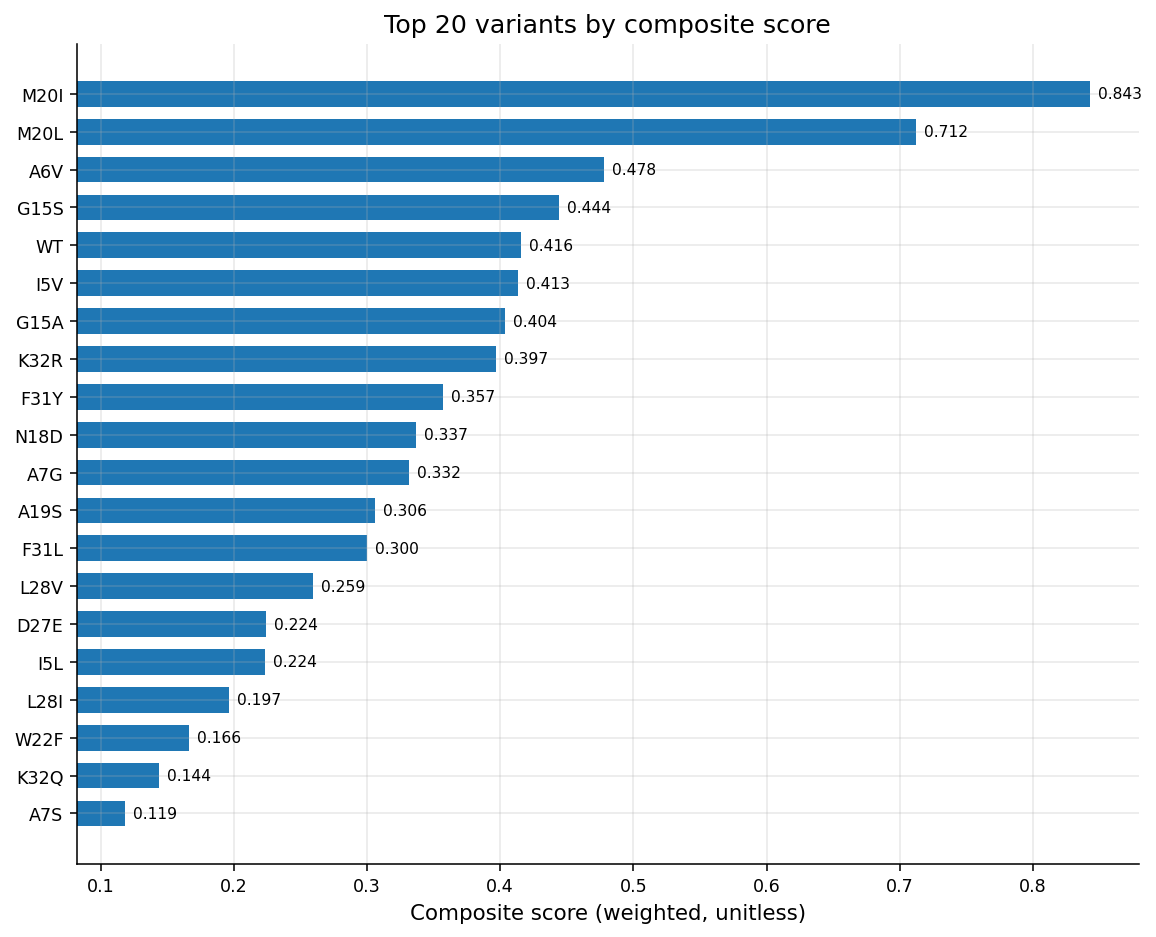

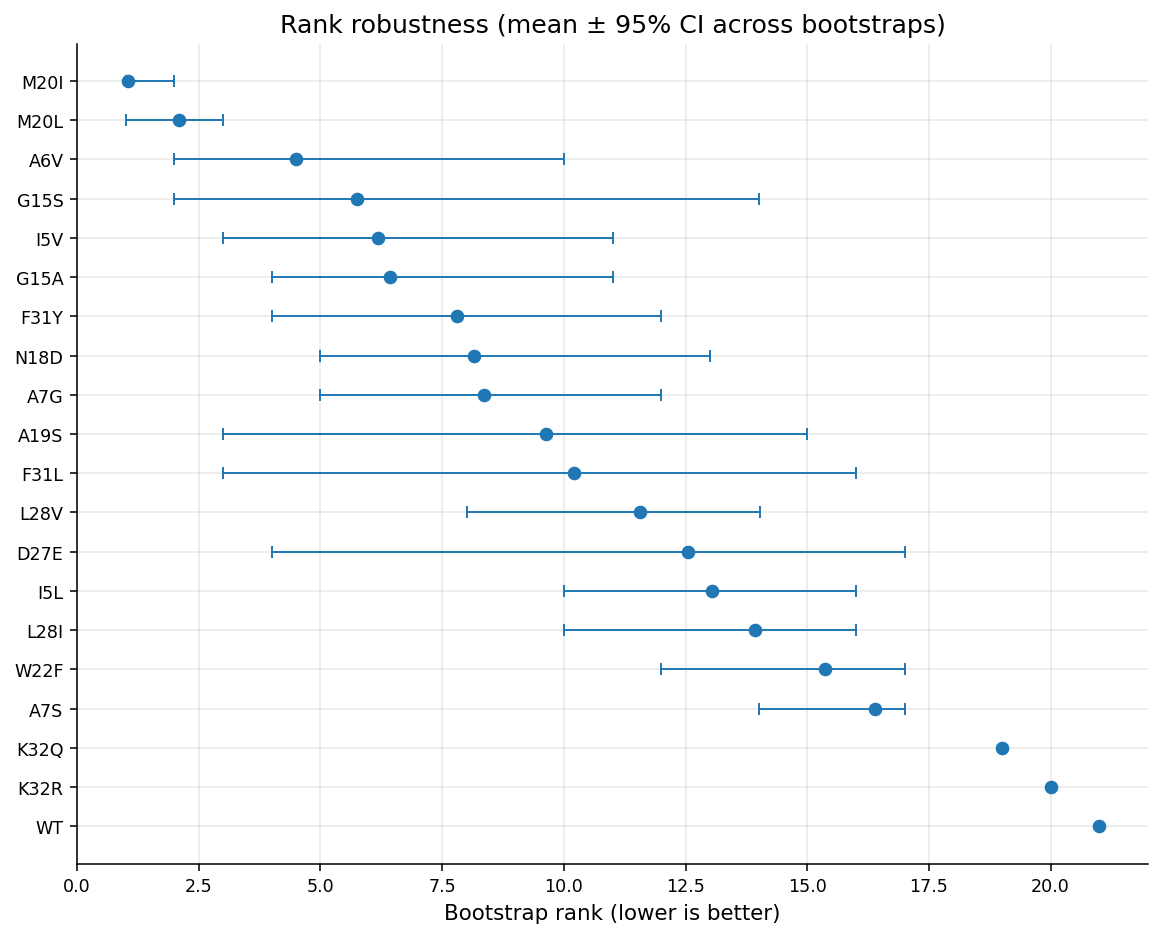

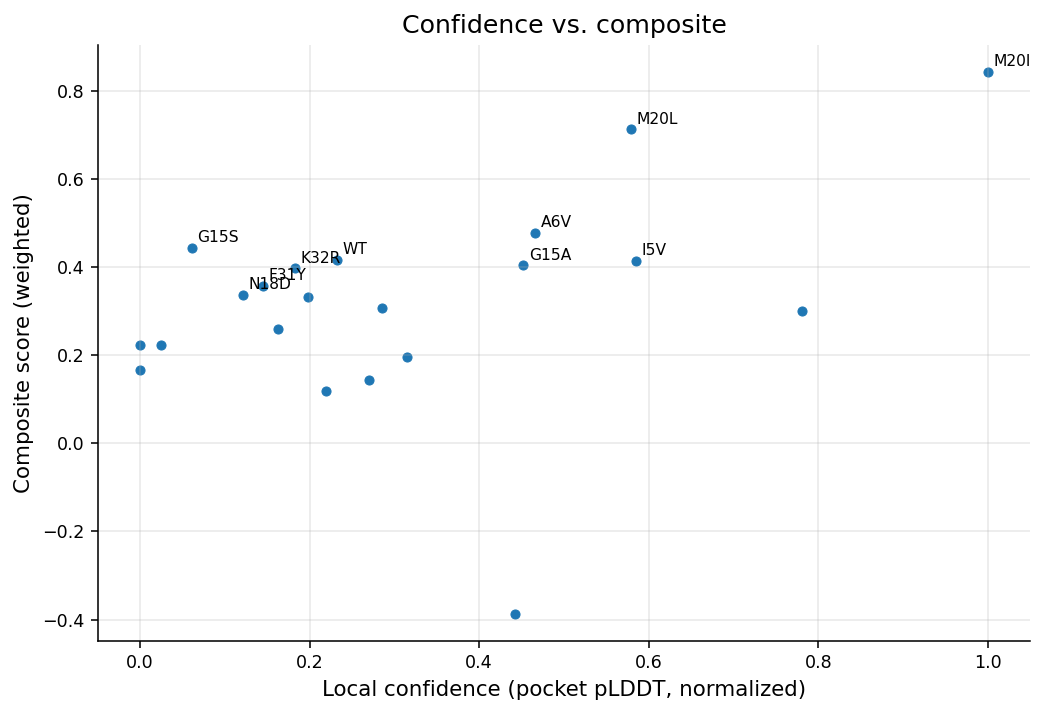

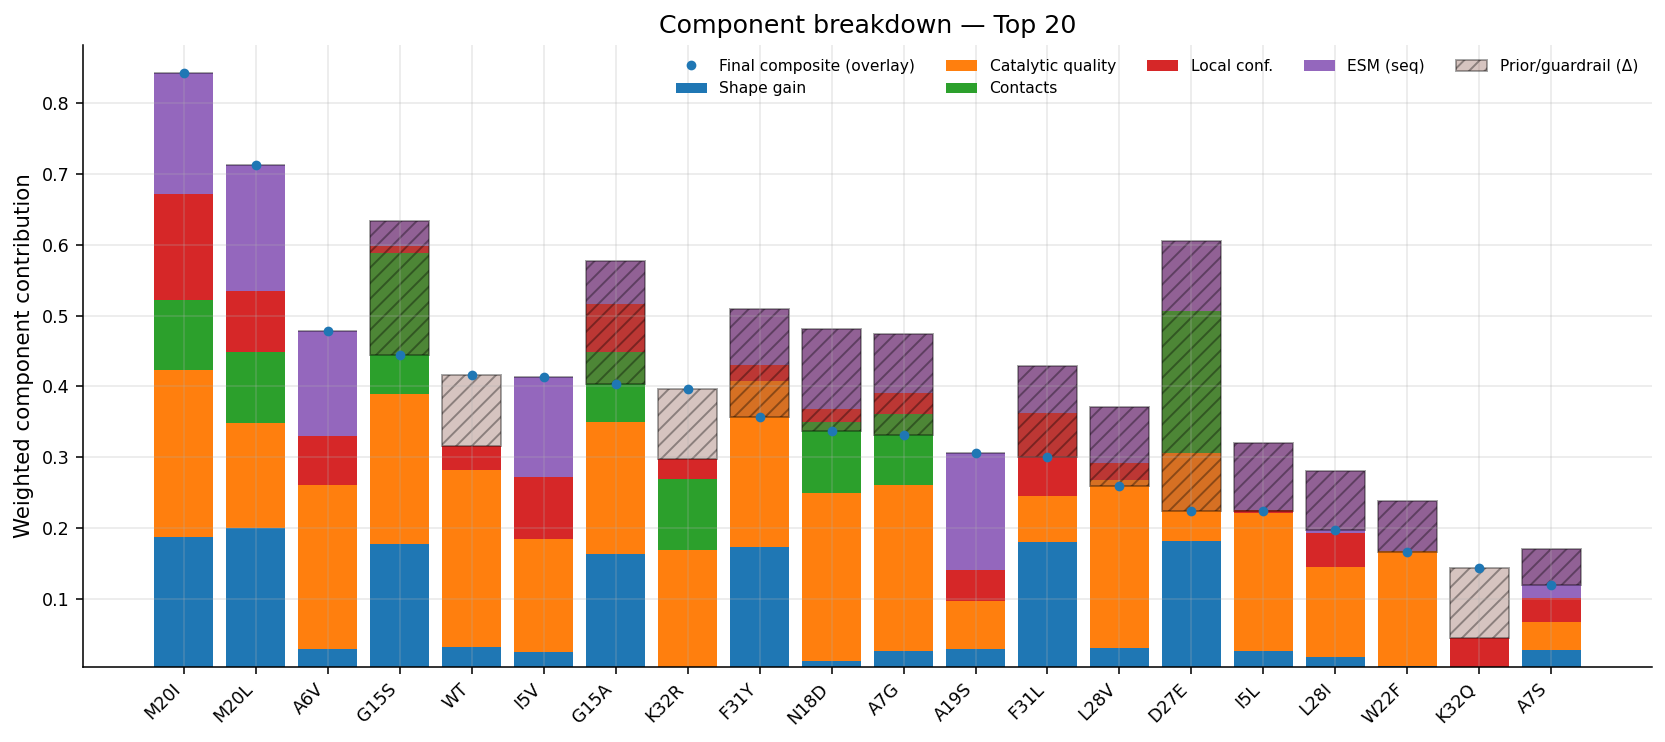

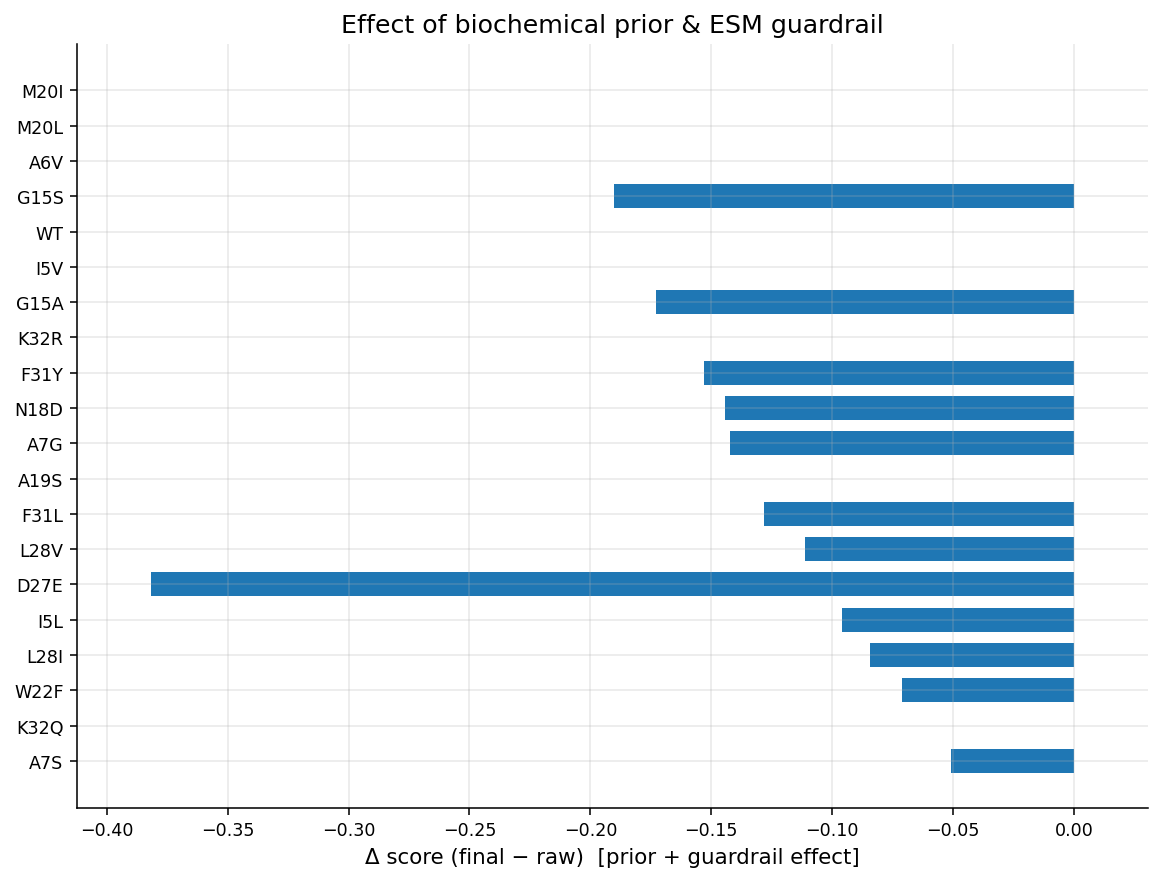

Dashboard ready: 21 variants visualized. Guardrail applied to 13 variants.


In [ ]:
#@title 26 - 📈 Results Dashboard
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ========= Config =========
OUT = Path(CFG["OUTDIR"])
TOP_N = 20
LABEL_TOP = 10
BAR_ANNOTATE = True
SAVE_FIGS = False
SORT_COMPONENTS_BY_FINAL = True

# ========= Styling =========
plt.rcParams.update({
    "figure.dpi": 140, "axes.labelsize": 11, "axes.titlesize": 13,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.alpha": 0.28, "grid.linewidth": 0.8,
})

def _apply_ax_style(ax):
    ax.grid(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)

def _shorten(labels, maxlen=14):
    return [s if len(str(s)) <= maxlen else str(s)[:maxlen-1] + "…" for s in labels]

def _safe_limits(arr, pad_frac=0.05, default=(0.0, 1.0)):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return default
    lo, hi = float(a.min()), float(a.max())
    pad = pad_frac * (hi - lo if hi > lo else 1.0)
    return lo - pad, hi + pad

# --- canonical IDs ---
_vid_pat = re.compile(r"([A-Z])(\d+)([A-Z])")
def _clean_variant_id(s: str) -> str:
    if not isinstance(s, str): return str(s)
    s = s.strip()
    if s.upper().startswith(("WT","WILDTYPE","WILD-TYPE")): return "WT"
    m = _vid_pat.search(s)
    if m: return f"{m.group(1)}{int(m.group(2))}{m.group(3)}"
    m = re.search(r"wt[=_:-]?([A-Z]).*?resi[=_:-]?(\d+).*?mut[=_:-]?([A-Z])", s, flags=re.I)
    if m: return f"{m.group(1)}{int(m.group(2))}{m.group(3)}"
    m = re.search(r"(\d+)[^\w]?([A-Z])[^\w>]*([A-Z])$", s)
    if m: return f"{m.group(2)}{int(m.group(1))}{m.group(3)}"
    return s.split("|",1)[0]

def _attach_key(df: pd.DataFrame) -> pd.DataFrame:
    f = df.copy()
    if "variant_key" in f.columns:
        f["key"] = f["variant_key"].astype(str)
    elif {"wt","resi","mut"} <= set(f.columns):
        f["key"] = f.apply(lambda r: f"{r['wt']}{int(r['resi'])}{r['mut']}", axis=1)
    elif "variant_id" in f.columns:
        f["key"] = f["variant_id"].map(_clean_variant_id)
    else:
        f["key"] = np.nan
    f = f.loc[:, ~f.columns.duplicated()]
    return f

# ========= Load =========
comp   = _attach_key(pd.read_csv(OUT / "composite_scores.csv"))
boot_p = OUT / "bootstrap_rank_stats.csv"
comp_p = OUT / "score_components.csv"
boot   = _attach_key(pd.read_csv(boot_p)) if boot_p.exists() else pd.DataFrame()
compc  = _attach_key(pd.read_csv(comp_p)) if comp_p.exists() else pd.DataFrame()
for df_ in (boot, compc):
    if not df_.empty and "variant_key" in df_.columns:
        df_.drop(columns=["variant_key"], inplace=True, errors="ignore")

need_comp = {"key","variant_id","composite_primary","local_conf_norm"}
missing = [c for c in need_comp if c not in comp.columns]
if missing:
    raise KeyError(f"Missing expected columns in composite_scores.csv: {missing}")

# ========= Merge essentials (via canonical 'key') =========
df = comp.merge(boot, on="key", how="left", suffixes=("", "_boot"))
df["variant_clean"] = np.where(df["key"].notna(), df["key"], df["variant_id"].map(_clean_variant_id))

# ========= Rank & select =========
df_ranked = df.sort_values(["composite_primary","local_conf_norm"], ascending=[False, False]).reset_index(drop=True)
top = df_ranked.head(TOP_N).copy()

# ========= Figure 1: Top-N by composite score =========
if len(top) > 0:
    fig, ax = plt.subplots(figsize=(8.4, max(3.8, 0.34*len(top))))
    y = np.arange(len(top))[::-1]
    vals = np.nan_to_num(top["composite_primary"].to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
    ax.barh(y, vals, height=0.68)
    ax.set_yticks(y, _shorten(top["variant_clean"].tolist()))
    ax.set_xlabel("Composite score (weighted, unitless)")
    ax.set_title(f"Top {len(top)} variants by composite score")
    _apply_ax_style(ax)
    lo, hi = _safe_limits(vals, pad_frac=0.05, default=(-0.5, 0.5))
    ax.set_xlim(lo, hi)
    if BAR_ANNOTATE:
        for yi, v in zip(y, vals):
            ha = "right" if v < 0 else "left"
            x  = v - 0.006 if v < 0 else v + 0.006
            ax.text(x, yi, f"{v:.3f}", va="center", ha=ha, fontsize=8)
    fig.tight_layout()
    if SAVE_FIGS: fig.savefig(OUT / "plot_topN_composite.png", bbox_inches="tight")
    plt.show()

# ========= Figure 2: Bootstrap rank stability =========
have_boot = {"mean_rank","ci_95_lower","ci_95_upper"} <= set(df.columns)
if have_boot and len(top) > 0:
    top_boot = top.dropna(subset=["mean_rank","ci_95_lower","ci_95_upper"]).copy()
    if len(top_boot) > 0:
        top_boot = top_boot.sort_values("mean_rank", ascending=True)
        fig, ax = plt.subplots(figsize=(8.4, max(3.8, 0.34*len(top_boot))))
        y = np.arange(len(top_boot))[::-1]
        mean = np.nan_to_num(top_boot["mean_rank"].to_numpy(), nan=np.inf)
        lower = np.nan_to_num(top_boot["ci_95_lower"].to_numpy(), nan=np.inf)
        upper = np.nan_to_num(top_boot["ci_95_upper"].to_numpy(), nan=np.inf)
        xerr = np.vstack([mean - lower, upper - mean])
        ax.errorbar(mean, y, xerr=xerr, fmt="o", capsize=3, elinewidth=1)
        ax.set_yticks(y, _shorten(top_boot["variant_clean"].tolist()))
        ax.set_xlabel("Bootstrap rank (lower is better)")
        ax.set_title("Rank robustness (mean ± 95% CI across bootstraps)")
        _apply_ax_style(ax)
        fig.tight_layout()
        if SAVE_FIGS: fig.savefig(OUT / "plot_bootstrap_ranks.png", bbox_inches="tight")
        plt.show()

# ========= Figure 3: Structural confidence vs composite =========
if len(df_ranked) > 0:
    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    xvals = np.nan_to_num(df_ranked["local_conf_norm"].to_numpy(), nan=0.0)
    yvals = np.nan_to_num(df_ranked["composite_primary"].to_numpy(), nan=0.0)
    ax.scatter(xvals, yvals, s=22, linewidths=0.5)
    ax.set_xlabel("Local confidence (pocket pLDDT, normalized)")
    ax.set_ylabel("Composite score (weighted)")
    ax.set_title("Confidence vs. composite")
    _apply_ax_style(ax)
    for _, r in df_ranked.head(LABEL_TOP).iterrows():
        ax.annotate(r["variant_clean"],
                    (float(np.nan_to_num(r["local_conf_norm"], nan=0.0)),
                     float(np.nan_to_num(r["composite_primary"], nan=0.0))),
                    xytext=(3, 3), textcoords="offset points", fontsize=8)
    fig.tight_layout()
    if SAVE_FIGS: fig.savefig(OUT / "plot_conf_vs_comp.png", bbox_inches="tight")
    plt.show()

# ========= Figure 4: Component breakdown (stacked + prior/guardrail segment) =========
W = {"shape_gain":0.20, "catalytic_quality":0.25, "contact_score":0.20, "local_conf":0.15, "esm_component":0.20}

if not compc.empty and len(top) > 0:
    tc = (compc.merge(top[["key","variant_clean"]], on="key").set_index("key"))
    labels = tc["variant_clean"].tolist()
    ids    = tc.index.tolist()

    # Weighted component parts (sanitize NaN/Inf → 0)
    parts = {
        "shape_gain":        np.nan_to_num(tc.get("shape_gain_norm", pd.Series(0, index=tc.index)).to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)*W["shape_gain"],
        "catalytic_quality": np.nan_to_num(tc.get("catalytic_quality_norm", pd.Series(0, index=tc.index)).to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)*W["catalytic_quality"],
        "contact_score":     np.nan_to_num(tc.get("contact_score_norm", pd.Series(0, index=tc.index)).to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)*W["contact_score"],
        "local_conf":        np.nan_to_num(tc.get("local_conf_norm", pd.Series(0, index=tc.index)).to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)*W["local_conf"],
        "esm_component":     np.nan_to_num(tc.get("esm_component", pd.Series(0, index=tc.index)).to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)*W["esm_component"],
    }

    composite_final = comp.set_index("key")["composite_primary"].reindex(ids).to_numpy()
    composite_final = np.nan_to_num(composite_final, nan=0.0, posinf=0.0, neginf=0.0)

    stack_sum = np.zeros_like(composite_final)
    for arr in parts.values():
        stack_sum = stack_sum + np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    delta_pg = composite_final - stack_sum  # can be ±

    if SORT_COMPONENTS_BY_FINAL:
        order = np.argsort(-composite_final)  # descending
        labels = [labels[i] for i in order]
        for k in parts: parts[k] = parts[k][order]
        stack_sum   = stack_sum[order]
        delta_pg    = delta_pg[order]
        composite_final = composite_final[order]

    x = np.arange(len(labels))
    if len(labels) > 0:
        fig, ax = plt.subplots(figsize=(max(8.6, 0.6*len(labels)), 5.4))
        bottom = np.zeros(len(labels))

        for key_, disp in [("shape_gain","Shape gain"),
                           ("catalytic_quality","Catalytic quality"),
                           ("contact_score","Contacts"),
                           ("local_conf","Local conf."),
                           ("esm_component","ESM (seq)")]:
            arr = parts[key_]
            ax.bar(x, arr, bottom=bottom, width=0.82, label=disp)
            bottom += arr

        ax.bar(x, delta_pg, bottom=stack_sum, width=0.82,
               label="Prior/guardrail (Δ)", alpha=0.35, hatch="///", edgecolor="k")

        ax.plot(x, composite_final, "o", ms=4, label="Final composite (overlay)")

        ax.set_xticks(x, _shorten(labels, 12), rotation=45, ha="right")
        ax.set_ylabel("Weighted component contribution")
        ax.set_title(f"Component breakdown — Top {len(labels)}")
        ax.legend(ncol=5, fontsize=8, frameon=False)
        _apply_ax_style(ax)

        # Robust y-limits even if all zeros/NaN
        y_lo, y_hi = _safe_limits(np.r_[stack_sum + np.minimum(delta_pg, 0),
                                        stack_sum + np.maximum(delta_pg, 0)],
                                  pad_frac=0.05, default=(-0.1, 0.9))
        ax.set_ylim(y_lo, y_hi)

        fig.tight_layout()
        if SAVE_FIGS: fig.savefig(OUT / "plot_component_breakdown.png", bbox_inches="tight")
        plt.show()
else:
    print("score_components.csv not found — skipping component breakdown.")

# ========= Figure 5: Prior/guardrail effect (delta barh) =========
have_raw = {"composite_primary_raw","cat_prior","guardrail_downgraded"} <= set(comp.columns)
if have_raw and len(top) > 0:
    delta = comp.loc[comp["key"].isin(top["key"])].copy()
    delta["variant_clean"] = delta["key"]
    delta["delta"] = delta["composite_primary"] - delta["composite_primary_raw"]
    delta = delta.sort_values("composite_primary", ascending=False)

    fig, ax = plt.subplots(figsize=(8.4, max(3.6, 0.32*len(delta))))
    y = np.arange(len(delta))[::-1]
    vals = delta["delta"].to_numpy()
    ax.barh(y, vals, height=0.68)
    ax.set_yticks(y, _shorten(delta["variant_clean"].tolist()))
    ax.set_xlabel("Δ score (final − raw)  [prior + guardrail effect]")
    ax.set_title("Effect of biochemical prior & ESM guardrail")
    _apply_ax_style(ax)
    lo, hi = vals.min(), vals.max()
    pad = 0.08 * (hi - lo if hi > lo else 1.0)
    ax.set_xlim(lo - pad, hi + pad)
    fig.tight_layout()
    if SAVE_FIGS: fig.savefig(OUT / "plot_prior_guardrail_effect.png", bbox_inches="tight")
    plt.show()

print(f"Dashboard ready: {df_ranked['key'].nunique()} variants visualized. "
      f"Guardrail applied to {int(comp.get('guardrail_downgraded', pd.Series(dtype=bool)).sum())} variants.")


📋 GENERATING COMPREHENSIVE PIPELINE REPORT

📁 Report directory: /content/run_LB/pipeline_report
📄 Report filename: pipeline_report_2026-01-28_22-48-05.html

📊 Collecting pipeline data...
  ℹ️  Using composite_scores.csv for results
  ℹ️  Renamed columns: variant_id, composite_primary, pocket_plddt_mean, esm1v_llr_ens
  ✓ Found 36 variants
  ✓ Found 180 predicted structures
  ✓ Found 21 ranked variants

🖼️  Collecting figures...
  ✓ Found 2 figure files

📈 Creating summary visualizations...
  ✓ Created composite score plot
  ✓ Created pLDDT distribution plot
  ✓ Created ESM vs composite score plot

📝 Generating HTML report...
💾 Saving report to: /content/run_LB/pipeline_report/pipeline_report_2026-01-28_22-48-05.html

✅ REPORT GENERATION COMPLETE

📄 Report saved to: /content/run_LB/pipeline_report/pipeline_report_2026-01-28_22-48-05.html
📁 Report directory: /content/run_LB/pipeline_report

To view the report:
  1. Download from Google Drive: /content/run_LB/pipeline_report/pipeline_repo


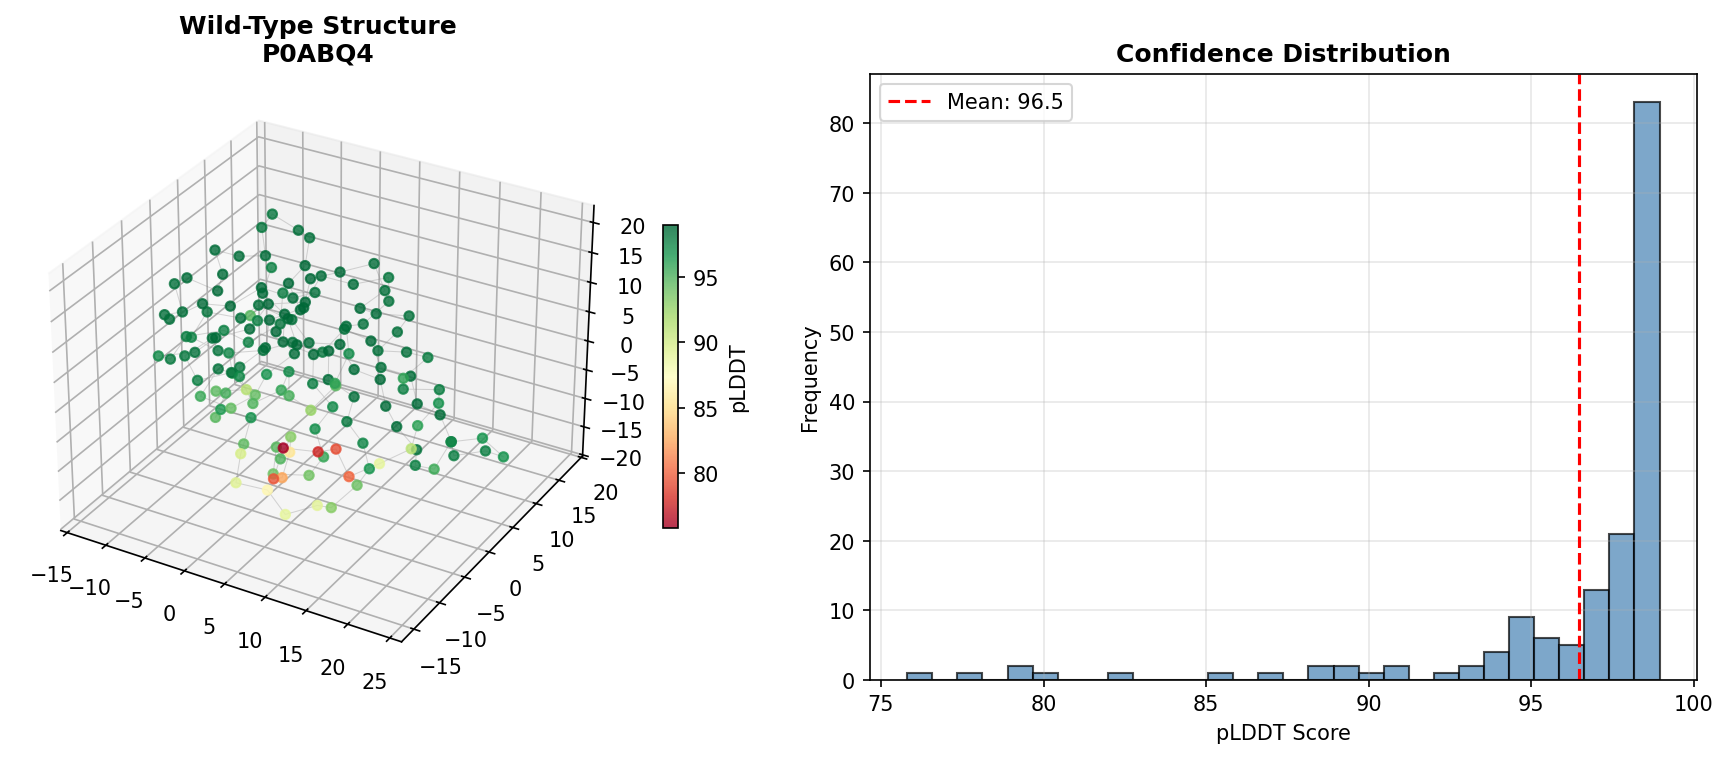
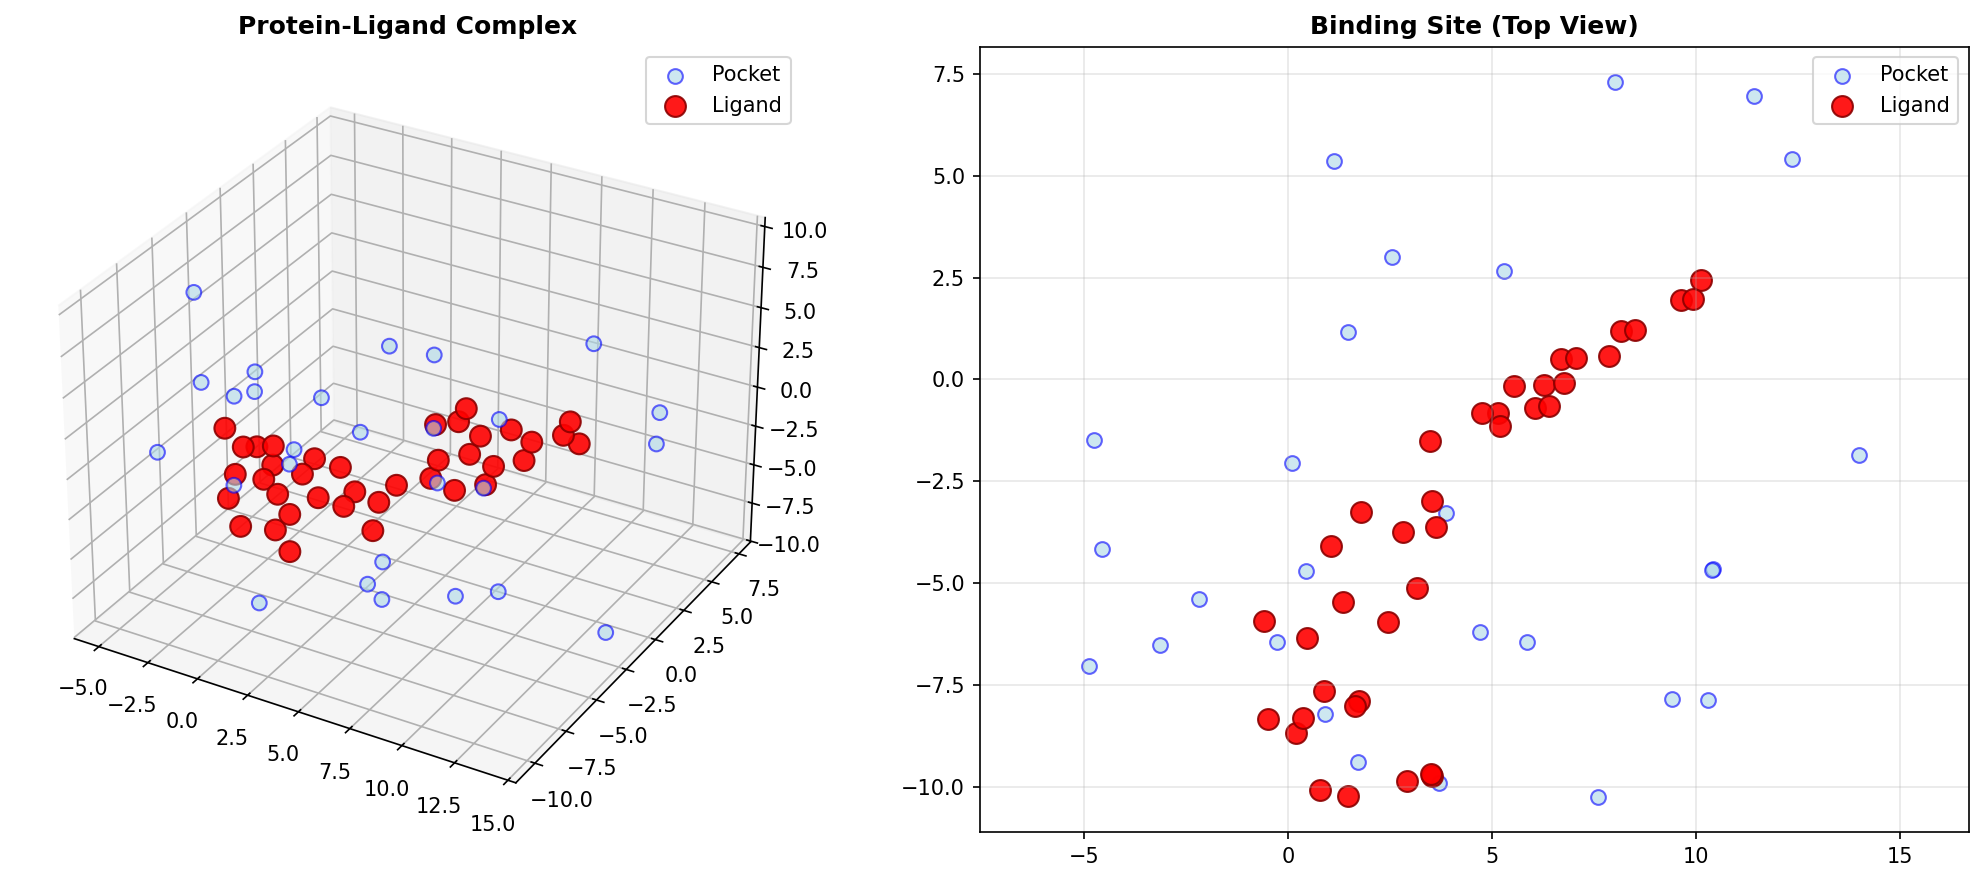
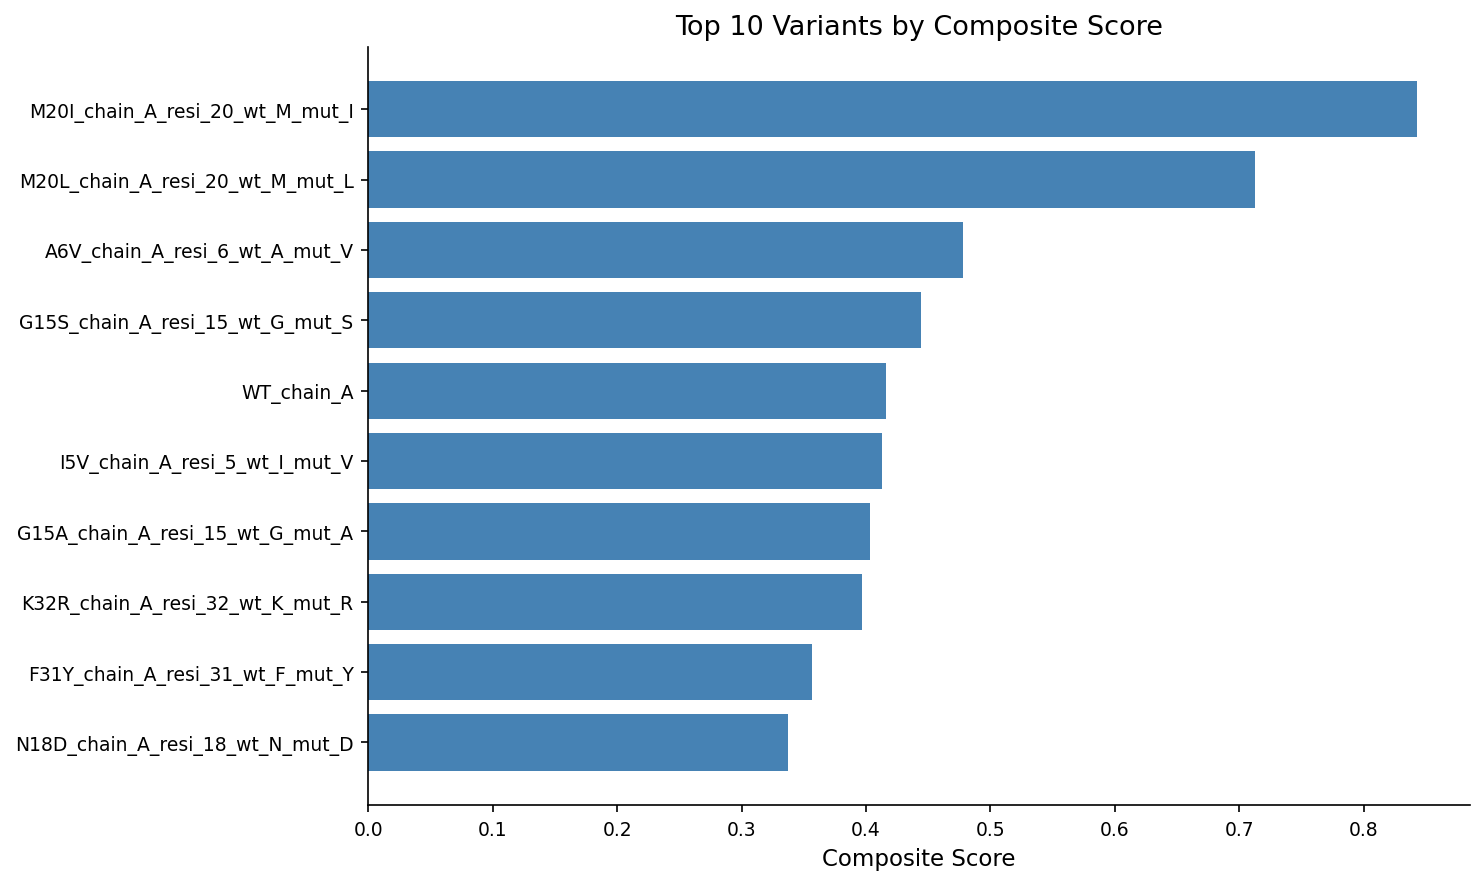
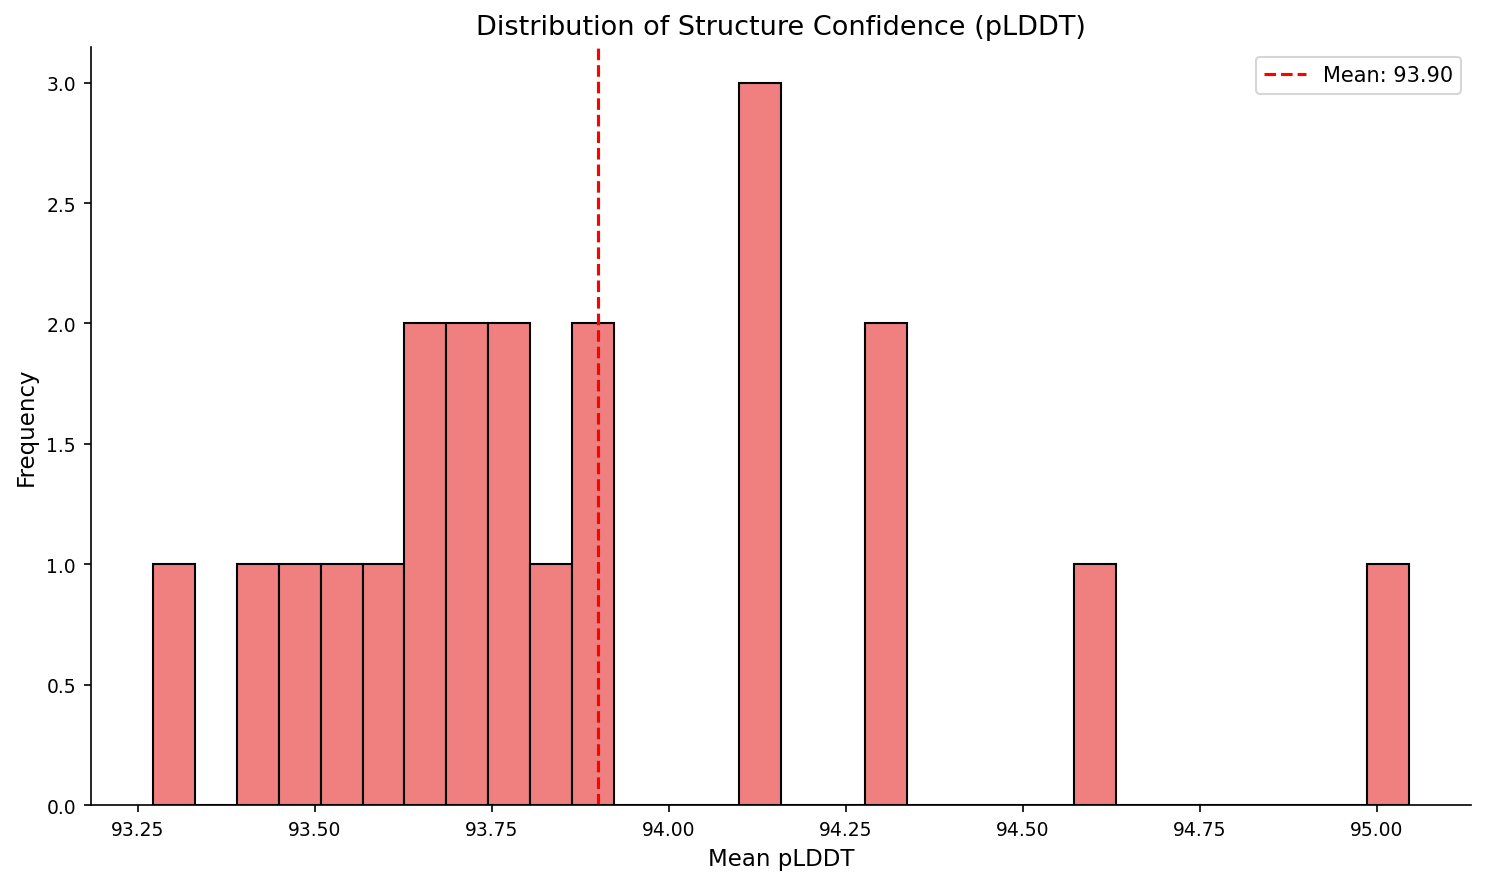
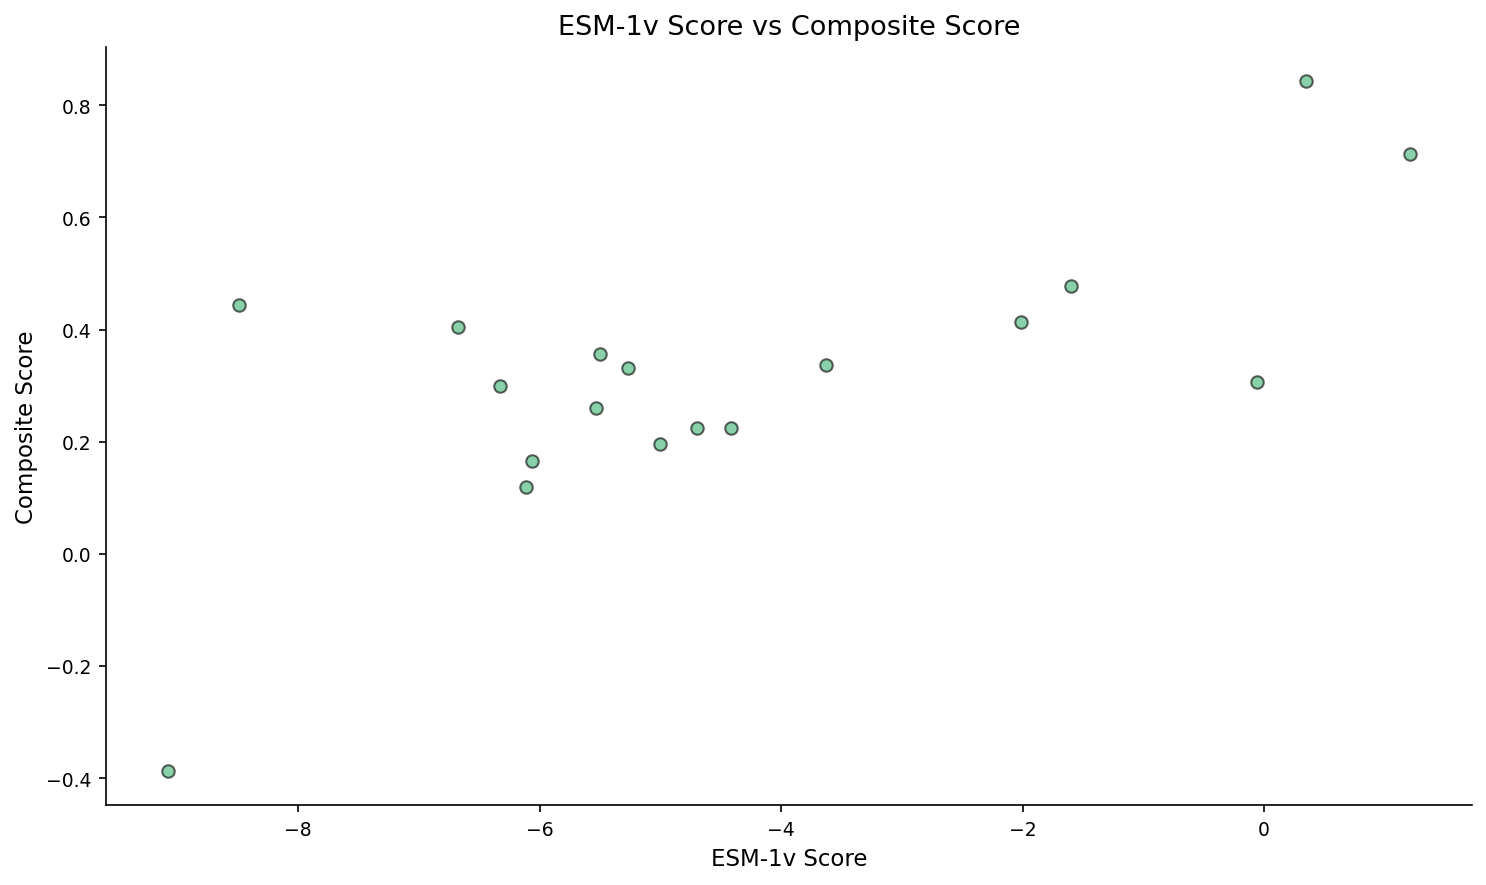
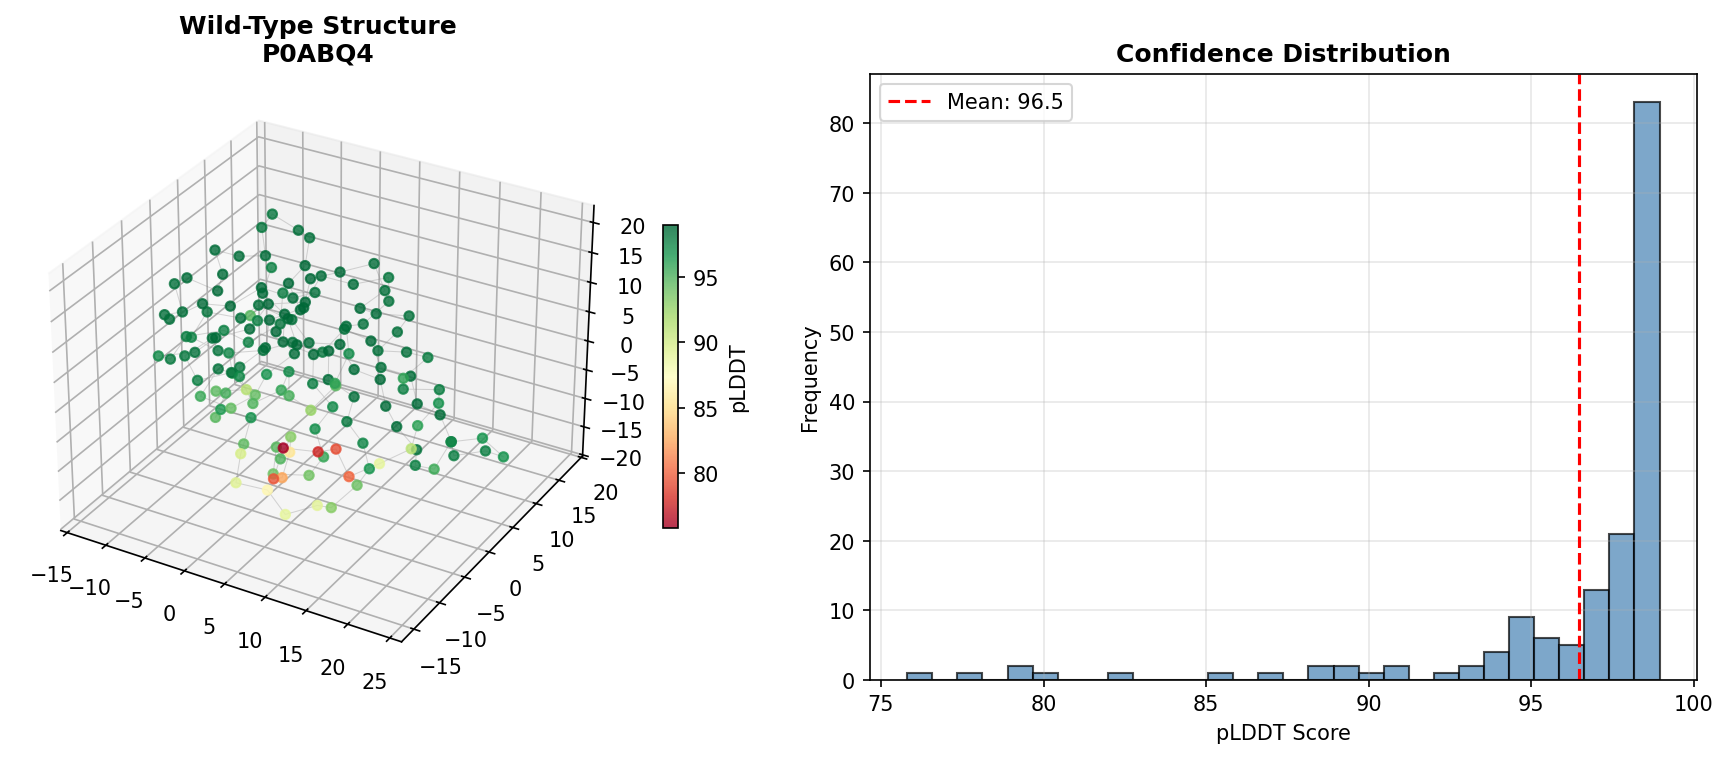
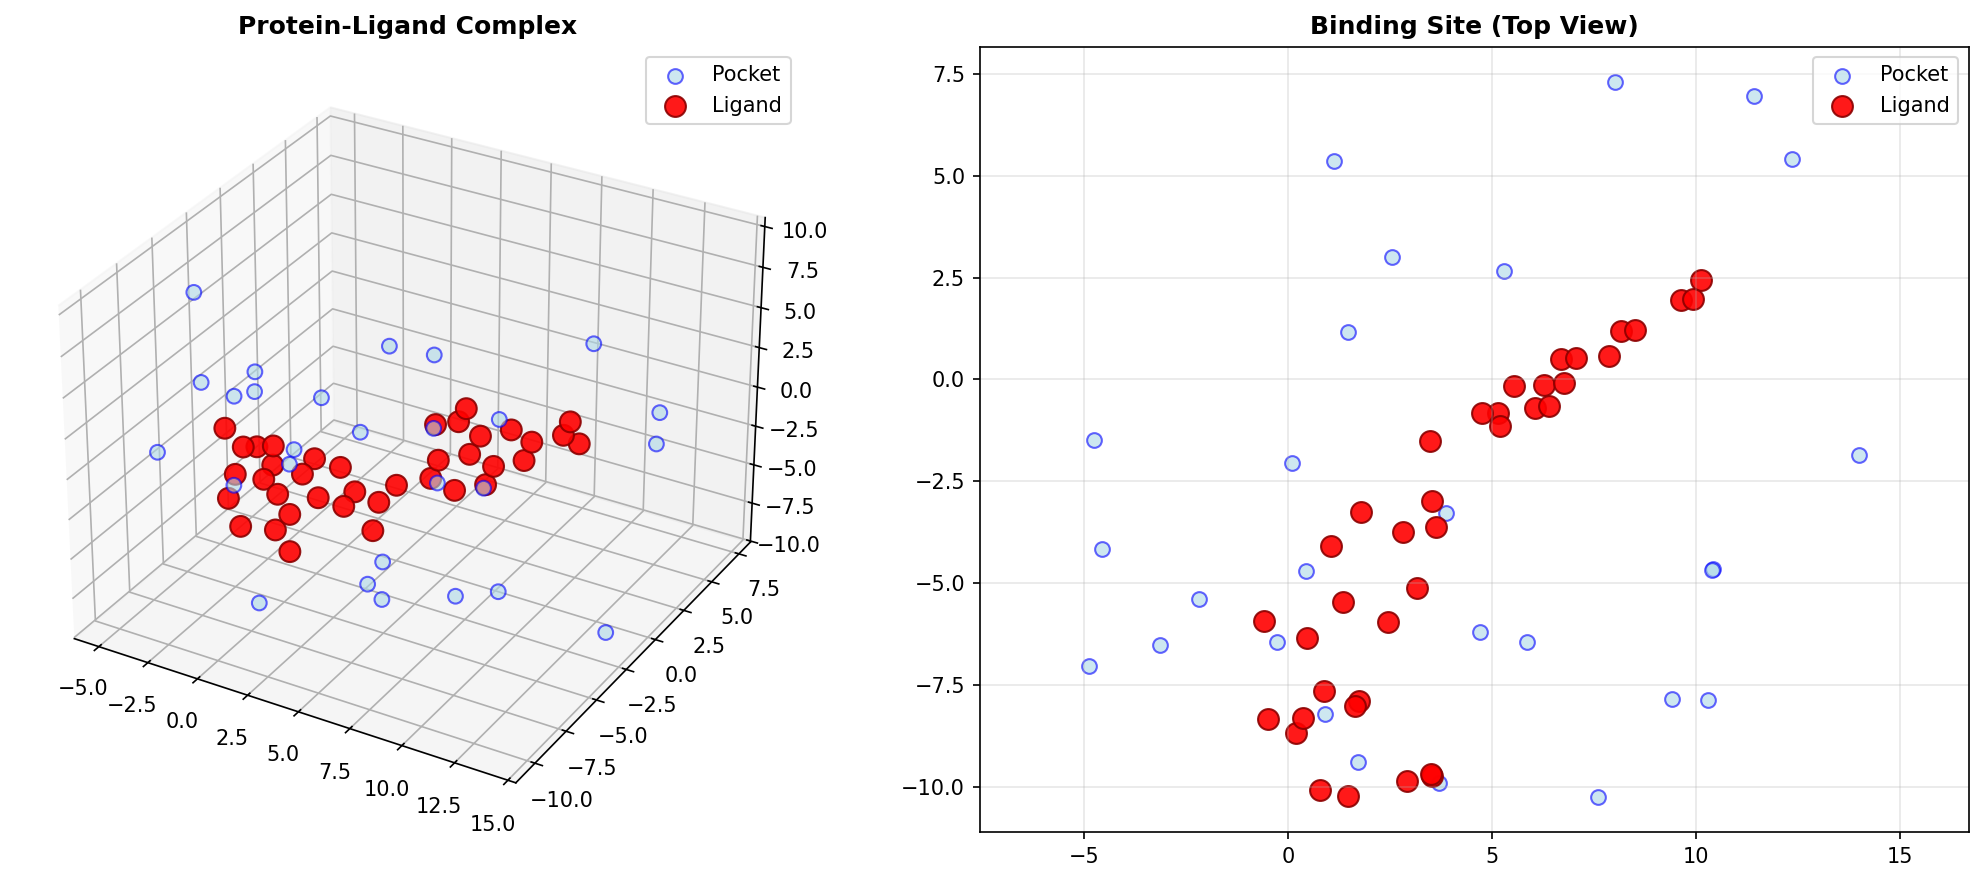

  ✓ Report displayed above!



In [ ]:
#@title 27 - 📋 Generate Comprehensive Pipeline Report
import os
import json
import base64
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend
import matplotlib.pyplot as plt
from io import BytesIO

print("=" * 70)
print("📋 GENERATING COMPREHENSIVE PIPELINE REPORT")
print("=" * 70)
print()

# ===== CONFIGURATION =====
OUTDIR = Path(CFG["OUTDIR"])
REPORT_DIR = OUTDIR / "pipeline_report"
REPORT_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
report_filename = f"pipeline_report_{timestamp}.html"
report_path = REPORT_DIR / report_filename

print(f"📁 Report directory: {REPORT_DIR}")
print(f"📄 Report filename: {report_filename}")
print()

# ===== HELPER FUNCTIONS =====

def fig_to_base64(fig):
    """Convert matplotlib figure to base64 string for HTML embedding."""
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode()
    plt.close(fig)
    return f"data:image/png;base64,{img_str}"

def file_to_base64(filepath):
    """Convert image file to base64 string for HTML embedding."""
    with open(filepath, 'rb') as f:
        img_str = base64.b64encode(f.read()).decode()
    ext = Path(filepath).suffix.lower()
    mime = {'png': 'image/png', 'jpg': 'image/jpeg', 'jpeg': 'image/jpeg', 'svg': 'image/svg+xml'}.get(ext[1:], 'image/png')
    return f"data:{mime};base64,{img_str}"

def safe_read(filepath, default="Not found"):
    """Safely read file content with fallback."""
    try:
        if Path(filepath).exists():
            with open(filepath, 'r') as f:
                return f.read()
        return default
    except Exception as e:
        return f"Error reading file: {e}"

def safe_json(filepath, default=None):
    """Safely load JSON file."""
    try:
        if Path(filepath).exists():
            with open(filepath, 'r') as f:
                return json.load(f)
        return default
    except Exception as e:
        print(f"  ⚠️  Error loading {filepath}: {e}")
        return default

def safe_csv(filepath, default=None):
    """Safely load CSV/TSV file."""
    try:
        if Path(filepath).exists():
            sep = '\t' if filepath.endswith('.tsv') else ','
            return pd.read_csv(filepath, sep=sep)
        return default
    except Exception as e:
        print(f"  ⚠️  Error loading {filepath}: {e}")
        return default

# ===== COLLECT DATA =====
print("📊 Collecting pipeline data...")

# Configuration
config_summary = {
    "Protein": CFG.get("UNIPROT_ID", "N/A"),
    "Job Name": CFG.get("JOB_NAME", "N/A"),
    "AlphaFold Version": CFG.get("AFDB_VERSION", "N/A"),
    "Model Type": CFG.get("MODEL_TYPE", "N/A"),
    "Seeds": CFG.get("NUM_SEEDS", "N/A"),
    "Recycles": CFG.get("NUM_RECYCLES", "N/A"),
    "Relaxations": CFG.get("NUM_RELAX", "N/A"),
}

# Package versions (from Cell 05 verification)
try:
    import numpy, jax, tensorflow, rdkit, vina
    package_versions = {
        "NumPy": getattr(numpy, '__version__', 'unknown'),
        "JAX": getattr(jax, '__version__', 'unknown'),
        "TensorFlow": getattr(tensorflow, '__version__', 'unknown'),
        "RDKit": getattr(rdkit, '__version__', 'unknown'),
        "Vina": getattr(vina, '__version__', 'unknown'),
    }
except Exception as e:
    package_versions = {"Error": str(e)}

# Variants data
variants_file = OUTDIR / "variants_step4.tsv"
variants_df = safe_csv(str(variants_file))
n_variants = len(variants_df) if variants_df is not None else 0

# Final results - try multiple possible filenames
final_results_file = OUTDIR / "final_ranked_variants.csv"
if not final_results_file.exists():
    # Try alternate names
    for alt_name in ["composite_scores.csv", "cluster_representatives.csv", "all_models.csv"]:
        alt_file = OUTDIR / alt_name
        if alt_file.exists():
            final_results_file = alt_file
            print(f"  ℹ️  Using {alt_name} for results")
            break

final_df = safe_csv(str(final_results_file))
n_final = len(final_df) if final_df is not None else 0

# Standardize column names (handle different CSV structures)
if final_df is not None and len(final_df) > 0:
    # Map alternative column names to standard names
    column_mapping = {
        'variant_id': 'variant',
        'composite_primary': 'composite_score',
        'pocket_plddt_mean': 'mean_plddt',
        'esm1v_llr_ens': 'esm1v_score',
    }

    # Rename columns if they exist
    rename_dict = {}
    for old_name, new_name in column_mapping.items():
        if old_name in final_df.columns:
            rename_dict[old_name] = new_name

    if rename_dict:
        final_df = final_df.rename(columns=rename_dict)
        print(f"  ℹ️  Renamed columns: {', '.join(rename_dict.keys())}")

    # Sort by composite score (descending) to get top variants
    if 'composite_score' in final_df.columns:
        final_df = final_df.sort_values('composite_score', ascending=False)

# ColabFold results - search recursively in subdirectories
models_dir = OUTDIR / "models_step5"
pdb_files = list(models_dir.glob("**/*.pdb")) if models_dir.exists() else []  # ** for recursive search
n_structures = len(pdb_files)

# Pocket residues
pocket_file = OUTDIR / "pocket_residues.txt"
pocket_residues = safe_read(str(pocket_file), "Not found").strip().split(',') if Path(pocket_file).exists() else []
n_pocket_residues = len(pocket_residues)

# Summary statistics
if final_df is not None and len(final_df) > 0:
    top_variants = final_df.head(10).to_dict('records')
    stats = {
        "Total Variants Generated": n_variants,
        "Structures Predicted": n_structures,
        "Final Ranked Variants": n_final,
        "Pocket Residues Identified": n_pocket_residues,
        "Mean pLDDT": f"{final_df['mean_plddt'].mean():.2f}" if 'mean_plddt' in final_df.columns else "N/A",
        "Mean Composite Score": f"{final_df['composite_score'].mean():.3f}" if 'composite_score' in final_df.columns else "N/A",
    }
else:
    top_variants = []
    stats = {
        "Total Variants Generated": n_variants,
        "Structures Predicted": n_structures,
        "Note": "Final results not yet generated"
    }

print(f"  ✓ Found {n_variants} variants")
print(f"  ✓ Found {n_structures} predicted structures")
print(f"  ✓ Found {n_final} ranked variants")
print()

# ===== COLLECT FIGURES =====
print("🖼️  Collecting figures...")

figures = []

# Look for common figure files (recursive search)
fig_patterns = [
    "*.png", "*.jpg", "*.jpeg", "*.svg"
]

# Search recursively in OUTDIR (excluding models_step5 to avoid subdirectory PDB images)
for pattern in fig_patterns:
    for fig_path in OUTDIR.glob(f"**/{pattern}"):  # Recursive search
        if fig_path.is_file() and not fig_path.name.startswith('.'):
            # Skip if inside models_step5 (to avoid clutter)
            if "models_step5" not in str(fig_path.relative_to(OUTDIR)):
                rel_path = fig_path.relative_to(OUTDIR)
                section = f"Figures from {rel_path.parent}/" if rel_path.parent != Path(".") else "Generated Figures"
                figures.append({
                    "path": fig_path,
                    "name": str(rel_path),
                    "section": section
                })

print(f"  ✓ Found {len(figures)} figure files")
print()

# ===== CREATE SUMMARY PLOTS =====
print("📈 Creating summary visualizations...")

embedded_plots = []

# Plot 1: Top 10 variants by composite score
if final_df is not None and len(final_df) > 0 and 'composite_score' in final_df.columns:
    try:
        fig, ax = plt.subplots(figsize=(10, 6))
        top10 = final_df.head(10).copy()
        top10['variant_label'] = top10['variant'].astype(str)
        ax.barh(range(len(top10)), top10['composite_score'], color='steelblue')
        ax.set_yticks(range(len(top10)))
        ax.set_yticklabels(top10['variant_label'])
        ax.set_xlabel('Composite Score')
        ax.set_title('Top 10 Variants by Composite Score')
        ax.invert_yaxis()
        plt.tight_layout()
        embedded_plots.append({
            "title": "Top 10 Variants by Composite Score",
            "img": fig_to_base64(fig)
        })
        print("  ✓ Created composite score plot")
    except Exception as e:
        print(f"  ⚠️  Could not create composite score plot: {e}")

# Plot 2: pLDDT distribution
if final_df is not None and 'mean_plddt' in final_df.columns:
    try:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(final_df['mean_plddt'], bins=30, color='lightcoral', edgecolor='black')
        ax.set_xlabel('Mean pLDDT')
        ax.set_ylabel('Frequency')
        ax.set_title('Distribution of Structure Confidence (pLDDT)')
        ax.axvline(final_df['mean_plddt'].mean(), color='red', linestyle='--',
                   label=f'Mean: {final_df["mean_plddt"].mean():.2f}')
        ax.legend()
        plt.tight_layout()
        embedded_plots.append({
            "title": "Structure Confidence Distribution",
            "img": fig_to_base64(fig)
        })
        print("  ✓ Created pLDDT distribution plot")
    except Exception as e:
        print(f"  ⚠️  Could not create pLDDT plot: {e}")

# Plot 3: ESM scores vs Composite scores
if final_df is not None and 'esm1v_score' in final_df.columns and 'composite_score' in final_df.columns:
    try:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(final_df['esm1v_score'], final_df['composite_score'],
                   alpha=0.6, c='mediumseagreen', edgecolor='black')
        ax.set_xlabel('ESM-1v Score')
        ax.set_ylabel('Composite Score')
        ax.set_title('ESM-1v Score vs Composite Score')
        plt.tight_layout()
        embedded_plots.append({
            "title": "ESM-1v vs Composite Score",
            "img": fig_to_base64(fig)
        })
        print("  ✓ Created ESM vs composite score plot")
    except Exception as e:
        print(f"  ⚠️  Could not create ESM comparison plot: {e}")

print()

# ===== GENERATE HTML REPORT =====
print("📝 Generating HTML report...")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Pipeline Report - {timestamp}</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        body {{
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Oxygen, Ubuntu, Cantarell, sans-serif;
            line-height: 1.6;
            color: #333;
            background: #f5f5f5;
            padding: 20px;
        }}

        .container {{
            max-width: 1400px;
            margin: 0 auto;
            background: white;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
            border-radius: 8px;
            overflow: hidden;
        }}

        header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}

        header h1 {{
            font-size: 2.5em;
            margin-bottom: 10px;
        }}

        header p {{
            font-size: 1.1em;
            opacity: 0.9;
        }}

        .content {{
            padding: 40px;
        }}

        .section {{
            margin-bottom: 50px;
        }}

        .section h2 {{
            font-size: 1.8em;
            color: #667eea;
            margin-bottom: 20px;
            padding-bottom: 10px;
            border-bottom: 3px solid #667eea;
            line-height: 1.3;
        }}

        .section h3 {{
            font-size: 1.4em;
            color: #764ba2;
            margin-top: 30px;
            margin-bottom: 15px;
            line-height: 1.4;
        }}

        .section p {{
            line-height: 1.8;
            margin-bottom: 10px;
        }}

        .grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(300px, 1fr));
            gap: 20px;
            margin: 20px 0;
        }}

        .card {{
            background: #f8f9fa;
            border: 1px solid #e0e0e0;
            border-radius: 8px;
            padding: 20px;
            transition: transform 0.2s, box-shadow 0.2s;
        }}

        .card:hover {{
            transform: translateY(-2px);
            box-shadow: 0 4px 12px rgba(0,0,0,0.1);
        }}

        .card h4 {{
            color: #667eea;
            margin-bottom: 10px;
            font-size: 1.1em;
        }}

        .card p {{
            font-size: 0.95em;
            color: #666;
        }}

        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
            margin: 20px 0;
        }}

        .stat-box {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px;
            border-radius: 8px;
            text-align: center;
        }}

        .stat-box .value {{
            font-size: 2em;
            font-weight: bold;
            margin-bottom: 5px;
            line-height: 1.2;
        }}

        .stat-box .label {{
            font-size: 0.9em;
            opacity: 0.9;
            line-height: 1.4;
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            background: white;
        }}

        th, td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #e0e0e0;
            line-height: 1.6;
        }}

        th {{
            background: #667eea;
            color: white;
            font-weight: 600;
        }}

        tr:hover {{
            background: #f8f9fa;
        }}

        .figure-container {{
            margin: 30px 0;
            text-align: center;
        }}

        .figure-container img {{
            max-width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            margin: 10px 0;
        }}

        .figure-container h4 {{
            color: #667eea;
            margin-bottom: 10px;
        }}

        pre {{
            background: #f4f4f4;
            padding: 15px;
            border-radius: 5px;
            overflow-x: auto;
            font-size: 0.9em;
            border-left: 4px solid #667eea;
            line-height: 1.8;
            white-space: pre-wrap;
            word-wrap: break-word;
        }}

        code {{
            font-family: 'Courier New', monospace;
            background: #f4f4f4;
            padding: 2px 6px;
            border-radius: 3px;
        }}

        .success {{
            color: #28a745;
            font-weight: bold;
        }}

        .warning {{
            color: #ffc107;
            font-weight: bold;
        }}

        .error {{
            color: #dc3545;
            font-weight: bold;
        }}

        footer {{
            background: #f8f9fa;
            padding: 20px 40px;
            text-align: center;
            color: #666;
            font-size: 0.9em;
            border-top: 1px solid #e0e0e0;
        }}

        @media print {{
            body {{
                background: white;
                padding: 0;
            }}

            .container {{
                box-shadow: none;
            }}

            .card:hover {{
                transform: none;
                box-shadow: none;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>🧬 Protein Variant Pipeline Report</h1>
            <p>Comprehensive Analysis Results</p>
            <p style="font-size: 0.9em; margin-top: 10px;">Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</p>
        </header>

        <div class="content">
            <!-- EXECUTIVE SUMMARY -->
            <div class="section">
                <h2>📊 Executive Summary</h2>
                <div class="stats-grid">
"""

# Add statistics
for key, value in stats.items():
    html += f"""
                    <div class="stat-box">
                        <div class="value">{value}</div>
                        <div class="label">{key}</div>
                    </div>
"""

html += """
                </div>
            </div>

            <!-- KEY VISUALIZATIONS -->
            <div class="section">
                <h2>🖼️ Key Visualizations</h2>
"""

# Check for key visualization files
key_viz_files = {
    "protein_structure.png": {
        "title": "Wild-Type Protein Structure",
        "description": "AlphaFold prediction colored by pLDDT confidence (Cell 07)"
    },
    "protein_ligand_complex.png": {
        "title": "Protein-Ligand Complex",
        "description": "Docked ligand in binding pocket with active site residues (Cell 14)"
    }
}

found_viz = []
for filename, info in key_viz_files.items():
    filepath = OUTDIR / filename
    if filepath.exists():
        try:
            img_data = file_to_base64(filepath)
            found_viz.append({
                "title": info["title"],
                "description": info["description"],
                "img": img_data
            })
        except Exception as e:
            print(f"  ⚠️  Could not load {filename}: {e}")

if found_viz:
    for viz in found_viz:
        html += f"""
                <div class="figure-container">
                    <h4>{viz['title']}</h4>
                    <p style="color: #666; font-style: italic; margin-bottom: 10px;">{viz['description']}</p>
                    <img src="{viz['img']}" alt="{viz['title']}">
                </div>
"""
else:
    html += """
                <p class="warning">⚠️ No key visualizations found. Make sure Cells 07 and 14 have been run with image saving enabled.</p>
                <p style="color: #666; font-size: 0.9em;">
                    To generate visualizations:
                    <ul>
                        <li>Add image saving code to Cell 07 (protein structure)</li>
                        <li>Add image saving code to Cell 14 (protein-ligand complex)</li>
                        <li>Re-run those cells, then re-run this report cell</li>
                    </ul>
                </p>
"""

html += """
            </div>

            <!-- CONFIGURATION -->
            <div class="section">
                <h2>⚙️ Pipeline Configuration</h2>
                <div class="grid">
"""

for key, value in config_summary.items():
    html += f"""
                    <div class="card">
                        <h4>{key}</h4>
                        <p><code>{value}</code></p>
                    </div>
"""

html += """
                </div>

                <h3>Package Versions</h3>
                <table>
                    <thead>
                        <tr>
                            <th>Package</th>
                            <th>Version</th>
                        </tr>
                    </thead>
                    <tbody>
"""

for pkg, ver in package_versions.items():
    html += f"""
                        <tr>
                            <td>{pkg}</td>
                            <td><code>{ver}</code></td>
                        </tr>
"""

html += """
                    </tbody>
                </table>
            </div>

            <!-- TOP VARIANTS -->
            <div class="section">
                <h2>🏆 Top Ranked Variants</h2>
"""

if top_variants:
    html += """
                <table>
                    <thead>
                        <tr>
                            <th>Rank</th>
                            <th>Variant</th>
                            <th>Composite Score</th>
                            <th>Mean pLDDT</th>
                            <th>ESM-1v Score</th>
                        </tr>
                    </thead>
                    <tbody>
"""
    for idx, var in enumerate(top_variants, 1):
        # Format numeric values safely
        comp_score = var.get('composite_score', 'N/A')
        comp_score_str = f"{comp_score:.4f}" if isinstance(comp_score, (int, float)) else 'N/A'

        plddt = var.get('mean_plddt', 'N/A')
        plddt_str = f"{plddt:.2f}" if isinstance(plddt, (int, float)) else 'N/A'

        esm_score = var.get('esm1v_score', 'N/A')
        esm_score_str = f"{esm_score:.4f}" if isinstance(esm_score, (int, float)) else 'N/A'

        html += f"""
                        <tr>
                            <td>{idx}</td>
                            <td><strong>{var.get('variant', 'N/A')}</strong></td>
                            <td>{comp_score_str}</td>
                            <td>{plddt_str}</td>
                            <td>{esm_score_str}</td>
                        </tr>
"""
    html += """
                    </tbody>
                </table>
"""
else:
    html += "<p class='warning'>⚠️ No variant results available yet.</p>"

html += """
            </div>

            <!-- SUMMARY VISUALIZATIONS -->
            <div class="section">
                <h2>📈 Summary Visualizations</h2>
"""

for plot in embedded_plots:
    html += f"""
                <div class="figure-container">
                    <h4>{plot['title']}</h4>
                    <img src="{plot['img']}" alt="{plot['title']}">
                </div>
"""

if not embedded_plots:
    html += "<p class='warning'>⚠️ No summary plots generated.</p>"

html += """
            </div>

            <!-- GENERATED FIGURES -->
            <div class="section">
                <h2>🖼️ Generated Figures</h2>
"""

if figures:
    # Group by section
    sections = {}
    for fig in figures:
        section = fig['section']
        if section not in sections:
            sections[section] = []
        sections[section].append(fig)

    for section, figs in sections.items():
        html += f"<h3>{section}</h3>"
        for fig in figs[:20]:  # Limit to 20 per section
            try:
                img_data = file_to_base64(fig['path'])
                html += f"""
                <div class="figure-container">
                    <h4>{fig['name']}</h4>
                    <img src="{img_data}" alt="{fig['name']}">
                </div>
"""
            except Exception as e:
                html += f"<p class='error'>❌ Could not load {fig['name']}: {e}</p>"

        if len(figs) > 20:
            html += f"<p><em>... and {len(figs) - 20} more figures</em></p>"
else:
    html += "<p class='warning'>⚠️ No figure files found in output directory.</p>"

html += """
            </div>

            <!-- POCKET RESIDUES -->
            <div class="section">
                <h2>🎯 Active Site Pocket Residues</h2>
"""

if pocket_residues and pocket_residues[0]:
    html += f"""
                <p>Identified <strong>{len(pocket_residues)}</strong> pocket residues:</p>
                <pre>{', '.join(pocket_residues)}</pre>
"""
else:
    html += "<p class='warning'>⚠️ Pocket residues not found.</p>"

html += """
            </div>

            <!-- OUTPUT FILES -->
            <div class="section">
                <h2>📂 Output Files</h2>
                <table>
                    <thead>
                        <tr>
                            <th>File</th>
                            <th>Location</th>
                            <th>Status</th>
                        </tr>
                    </thead>
                    <tbody>
"""

key_files = [
    ("Variants TSV", variants_file),
    ("Final Ranked Results", final_results_file),
    ("Pocket Residues", pocket_file),
    ("Models Directory", models_dir),
]

for name, path in key_files:
    exists = path.exists()
    status = '<span class="success">✓ Exists</span>' if exists else '<span class="error">✗ Not found</span>'
    html += f"""
                        <tr>
                            <td>{name}</td>
                            <td><code>{path}</code></td>
                            <td>{status}</td>
                        </tr>
"""

html += f"""
                    </tbody>
                </table>

                <h3>Structure Files</h3>
                <p>Total PDB files generated: <strong>{n_structures}</strong></p>
                {f'<p><em>Located in: <code>{models_dir}</code></em></p>' if n_structures > 0 else ''}
            </div>

        </div>

        <footer>
            <p>Report generated by Protein Variant Pipeline</p>
            <p>ColabFold-VIP | {timestamp}</p>
        </footer>
    </div>
</body>
</html>
"""

# ===== SAVE REPORT =====
print(f"💾 Saving report to: {report_path}")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html)

print()
print("=" * 70)
print("✅ REPORT GENERATION COMPLETE")
print("=" * 70)
print()
print(f"📄 Report saved to: {report_path}")
print(f"📁 Report directory: {REPORT_DIR}")
print()
print("To view the report:")
print(f"  1. Download from Google Drive: {report_path}")
print(f"  2. Open in your web browser")
print()
print("Or view directly in Colab:")
try:
    from IPython.display import HTML, display
    print("  Attempting to display report in notebook...")
    with open(report_path, 'r', encoding='utf-8') as f:
        display(HTML(f.read()))
    print("  ✓ Report displayed above!")
except Exception as e:
    print(f"  ⚠️  Could not display inline: {e}")
    print(f"  Please download and open {report_filename} in a browser")

print()
print("=" * 70)


In [ ]:
#@title 28 - ⏱️ Pipeline Duration
import os
from datetime import datetime
from pathlib import Path

print("="*50)
print("⏱️ PIPELINE EXECUTION TIME")
print("="*50)

try:
    # 1. Start Time: Read from pipeline_start.txt created in Cell 01
    start_marker = Path(CFG["OUTDIR"]) / "pipeline_start.txt"

    # Fallback to WT FASTA if start marker missing (for backward compatibility)
    fallback_path = Path(CFG.get("WT_FASTA", ""))

    start_dt = None
    source_start = "Unknown"

    if start_marker.exists():
        try:
            start_ts = float(start_marker.read_text().strip())
            start_dt = datetime.fromtimestamp(start_ts)
            source_start = "Cell 01 (Mount)"
        except ValueError:
            pass

    if start_dt is None and fallback_path.exists():
        start_ts = fallback_path.stat().st_mtime
        start_dt = datetime.fromtimestamp(start_ts)
        source_start = "Step 6 (Data Fetch)"

    if start_dt:
        # 2. End Time Proxy: Now (assuming this cell is run immediately after)
        # or the Pipeline Report file if it exists (for historical accuracy)
        end_dt = datetime.now()
        source_end = "Current Time"

        # Check for report file
        report_dir = Path(CFG["OUTDIR"]) / "pipeline_report"
        if report_dir.exists():
            reports = sorted(list(report_dir.glob("*.html")), key=lambda f: f.stat().st_mtime)
            if reports:
                last_report = reports[-1]
                # If report was created significantly earlier (>5 min ago), assume user is checking later
                # and use the report time as the true "end" of the run.
                if (end_dt.timestamp() - last_report.stat().st_mtime) > 300:
                    end_dt = datetime.fromtimestamp(last_report.stat().st_mtime)
                    source_end = "Last Report"

        duration = end_dt - start_dt

        # Format duration
        hours, remainder = divmod(duration.total_seconds(), 3600)
        minutes, seconds = divmod(remainder, 60)

        print(f"Start ({source_start}): {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"End   ({source_end}):      {end_dt.strftime('%Y-%m-%d %H:%M:%S')}")
        print("-" * 50)
        print(f"TOTAL DURATION:        {int(hours)}h {int(minutes)}m {int(seconds)}s")

    else:
        print("⚠️ Start marker not found. Run Cell 01 to initialize timer.")

except Exception as e:
    print(f"⚠️ Error calculating duration: {e}")
print("="*50)

⏱️ PIPELINE EXECUTION TIME
Start (Cell 01 (Mount)): 2026-01-28 22:06:59
End   (Current Time):      2026-01-28 22:48:06
--------------------------------------------------
TOTAL DURATION:        0h 41m 7s
